# DeepWeeds — Track 4 Day 2 — Vu Gia Khai (2A202602786)
GPU + Internet ON. Run all cells in order. Add-ons > Secrets: GITHUB_TOKEN (optional for ZIP, required for Git).
After real experiments: results.xlsx, report.md, plots, predictions, code and logs are packaged under
submissions/2A202602786_Vu_Gia_Khai/. A draft PR is created if GitHub credentials permit.
Read report.md and review the evidence before submitting the PR to your instructor.


## 📦 Cell 1 — Thiết lập thư mục làm việc & Clone Repo (nếu chạy độc lập)

In [1]:
import os, sys, subprocess, json
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = 'kaggle_web_client' in sys.modules or os.path.exists('/kaggle')

REPO_URL = 'https://github.com/vukhai248/K4-Track4-Day2-Deeplearning-Advance.git'
TARGET_DIR = Path('/content/K4-Track4-Day2-Deeplearning-Advance') if IN_COLAB else (Path('/kaggle/working/K4-Track4-Day2-Deeplearning-Advance') if IN_KAGGLE else Path.cwd())

if IN_COLAB or IN_KAGGLE:
    if not TARGET_DIR.exists() and not (Path.cwd() / 'eval.py').exists():
        print(f'📥 Đang clone repository từ {REPO_URL}...')
        subprocess.run(['git', 'clone', REPO_URL, str(TARGET_DIR)], check=True)
        os.chdir(TARGET_DIR)
    elif TARGET_DIR.exists():
        os.chdir(TARGET_DIR)

CWD = Path.cwd().resolve()
if CWD.name == 'code':
    os.chdir(CWD.parent)
    CWD = Path.cwd().resolve()

print(f'📁 Thư mục làm việc hiện tại: {CWD}')
for p in [str(CWD), str(CWD / 'code')]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Use the reviewed student implementation, rather than stale remote code.
RUNTIME_FILES = {'code/benchmark.py': '"""benchmark.py - đo độ trễ suy luận đúng cách (slide Day 2, trang 73 và 75; GUIDE.md mục 4.1).\n"""\nfrom __future__ import annotations\n\nimport time\nimport numpy as np\nimport torch\nimport torch.nn as nn\n\n\ndef bench(fn, warmup: int = 10, iters: int = 50, sync=None) -> dict:\n    """Đo thời gian hàm `fn()` (mili-giây) với warmup và đồng bộ GPU."""\n    # Warmup\n    for _ in range(warmup):\n        fn()\n    if sync is not None:\n        sync()\n\n    times = []\n    for _ in range(iters):\n        if sync is not None:\n            sync()\n        t0 = time.perf_counter()\n        fn()\n        if sync is not None:\n            sync()\n        t1 = time.perf_counter()\n        times.append((t1 - t0) * 1000.0)\n\n    return {\n        "p50": float(np.percentile(times, 50)),\n        "p95": float(np.percentile(times, 95)),\n        "p99": float(np.percentile(times, 99)),\n        "mean": float(np.mean(times)),\n        "std": float(np.std(times)),\n        "n": iters,\n    }\n\n\ndef latency_report(model: nn.Module, batch_size: int = 1, img_size: int = 224,\n                   dtype: str = "fp32", device: str = "cuda",\n                   warmup: int = 10, iters: int = 50) -> dict:\n    """Đo độ trễ forward của `model` với đầu vào chuẩn (batch_size, 3, img_size, img_size)."""\n    device_obj = torch.device(device if torch.cuda.is_available() else "cpu")\n    model = model.to(device_obj).eval()\n    dummy = torch.randn(batch_size, 3, img_size, img_size, device=device_obj)\n\n    sync = torch.cuda.synchronize if device_obj.type == "cuda" else None\n\n    if dtype == "fp16":\n        model = model.half()\n        dummy = dummy.half()\n        fn = lambda: model(dummy)\n    elif dtype == "amp":\n        fn = lambda: torch.cuda.amp.autocast(True)(lambda: model(dummy))()\n    else:  # fp32\n        fn = lambda: model(dummy)\n\n    with torch.inference_mode():\n        res = bench(fn, warmup=warmup, iters=iters, sync=sync)\n\n    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"\n    p50 = res["p50"]\n    images_per_s = (batch_size / (p50 / 1000.0)) if p50 > 0 else 0.0\n\n    return {\n        "gpu": gpu_name,\n        "dtype": dtype,\n        "batch": batch_size,\n        "img_size": img_size,\n        "p50": round(res["p50"], 2),\n        "p95": round(res["p95"], 2),\n        "p99": round(res["p99"], 2),\n        "mean": round(res["mean"], 2),\n        "images_per_s": round(images_per_s, 1),\n        "torch": torch.__version__,\n    }\n\n\ndef tta_latency(model: nn.Module, k_views: int = 2, batch_size: int = 1,\n                img_size: int = 224, device: str = "cuda", **kw) -> dict:\n    """Đo độ trễ cho K views TTA."""\n    device_obj = torch.device(device if torch.cuda.is_available() else "cpu")\n    model = model.to(device_obj).eval()\n    dummy = torch.randn(batch_size, 3, img_size, img_size, device=device_obj)\n    sync = torch.cuda.synchronize if device_obj.type == "cuda" else None\n\n    def fn():\n        for _ in range(k_views):\n            model(dummy)\n\n    with torch.inference_mode():\n        res = bench(fn, warmup=kw.get("warmup", 10), iters=kw.get("iters", 50), sync=sync)\n\n    return res\n', 'code/dataset.py': '"""dataset.py - đọc DeepWeeds, kiểm tra chia dữ liệu, transform, DataLoader.\n\nCung cấp đầy đủ hàm đọc dữ liệu, kiểm tra tính toàn vẹn (S1-S6), augmentation và DataLoader.\n"""\nfrom __future__ import annotations\n\nimport os\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom PIL import Image\nimport torch\nfrom torch.utils.data import Dataset, DataLoader, WeightedRandomSampler\nimport torchvision.transforms as T\n\nNUM_CLASSES = 9\n# Thứ tự lớp theo cột `Label` của labels.csv (0 = Chinee Apple ... 7 = Snake Weed, 8 = Negatives).\nCLASS_NAMES = [\n    "Chinee Apple", "Lantana", "Parkinsonia", "Parthenium", "Prickly Acacia",\n    "Rubber Vine", "Siam Weed", "Snake Weed", "Negatives",\n]\nIMAGENET_MEAN = (0.485, 0.456, 0.406)\nIMAGENET_STD = (0.229, 0.224, 0.225)\n\n\ndef _resolve_dir(path_str: str | Path, fallbacks: list[str]) -> Path:\n    p = Path(path_str)\n    if p.exists():\n        return p\n    for fb in fallbacks:\n        p_fb = Path(fb)\n        if p_fb.exists():\n            return p_fb\n    return p\n\n\ndef load_split(labels_dir: str | Path, fold: int = 0) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:\n    """Đọc train_subset{fold}.csv, val_subset{fold}.csv, test_subset{fold}.csv (S1).\n    Mỗi file có cột `Filename, Label, Species`. Trả về ba DataFrame.\n    """\n    labels_path = _resolve_dir(\n        labels_dir,\n        [\n            str(Path("..") / labels_dir),\n            str(Path(__file__).resolve().parent.parent / labels_dir),\n            str(Path(__file__).resolve().parent.parent / "data" / "labels"),\n        ]\n    )\n    train_file = labels_path / f"train_subset{fold}.csv"\n    val_file = labels_path / f"val_subset{fold}.csv"\n    test_file = labels_path / f"test_subset{fold}.csv"\n\n    if not train_file.exists() or not val_file.exists() or not test_file.exists():\n        raise FileNotFoundError(f"Không tìm thấy đủ file split fold {fold} tại {labels_path}")\n\n    train_df = pd.read_csv(train_file)\n    val_df = pd.read_csv(val_file)\n    test_df = pd.read_csv(test_file)\n\n    return train_df, val_df, test_df\n\n\ndef check_split(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame,\n                images_dir: str | Path) -> dict:\n    """Kiểm tra bắt buộc trước khi train (README.md, mục 2.1). In ra và trả về dict số liệu."""\n    img_path = _resolve_dir(\n        images_dir,\n        [\n            str(Path("..") / images_dir),\n            str(Path(__file__).resolve().parent.parent / images_dir),\n            str(Path(__file__).resolve().parent.parent / "images"),\n            str(Path(__file__).resolve().parent.parent / "data" / "images"),\n        ]\n    )\n    train_files = set(train_df["Filename"])\n    val_files = set(val_df["Filename"])\n    test_files = set(test_df["Filename"])\n\n    # 1. Kiểm tra giao rỗng\n    inter_tv = train_files & val_files\n    inter_tt = train_files & test_files\n    inter_vt = val_files & test_files\n    assert len(inter_tv) == 0, f"Lỗi rò rỉ: train và val có {len(inter_tv)} ảnh trùng nhau!"\n    assert len(inter_tt) == 0, f"Lỗi rò rỉ: train và test có {len(inter_tt)} ảnh trùng nhau!"\n    assert len(inter_vt) == 0, f"Lỗi rò rỉ: val và test có {len(inter_vt)} ảnh trùng nhau!"\n\n    # 2. Kiểm tra tổng số ảnh hợp đủ 17509\n    union_all = train_files | val_files | test_files\n    assert len(union_all) == 17509, f"Lỗi: Tổng số ảnh không phải 17.509 mà là {len(union_all)}"\n\n    # 3. Kiểm tra mọi file tồn tại\n    missing_files = []\n    for fn in union_all:\n        if not (img_path / fn).exists():\n            missing_files.append(fn)\n            if len(missing_files) >= 5:\n                break\n    assert len(missing_files) == 0, f"Lỗi: Không tìm thấy các file ảnh trong {img_path}, ví dụ: {missing_files}"\n\n    # 4. Thống kê\n    stats = {\n        "n": {\n            "train": len(train_df),\n            "val": len(val_df),\n            "test": len(test_df),\n            "total": len(union_all),\n        },\n        "ratio": {\n            "train": len(train_df) / len(union_all),\n            "val": len(val_df) / len(union_all),\n            "test": len(test_df) / len(union_all),\n        },\n        "per_class": {\n            "train": train_df["Label"].value_counts().to_dict(),\n            "val": val_df["Label"].value_counts().to_dict(),\n            "test": test_df["Label"].value_counts().to_dict(),\n        },\n        "overlap": {\n            "train_val": len(inter_tv),\n            "train_test": len(inter_tt),\n            "val_test": len(inter_vt),\n        }\n    }\n    return stats\n\n\ndef build_transforms(train: bool, img_size: int = 224, aug: str = "basic") -> T.Compose:\n    """Tạo transform theo `train` và `aug`."""\n    if train:\n        if aug == "basic":\n            return T.Compose([\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\n                T.RandomHorizontalFlip(),\n                T.ToTensor(),\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\n            ])\n        elif aug == "color":\n            return T.Compose([\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\n                T.RandomHorizontalFlip(),\n                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),\n                T.ToTensor(),\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\n            ])\n        elif aug == "trivial":\n            return T.Compose([\n                T.TrivialAugmentWide(),\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\n                T.RandomHorizontalFlip(),\n                T.ToTensor(),\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\n            ])\n        elif aug == "randaug":\n            return T.Compose([\n                T.RandAugment(num_ops=2, magnitude=9),\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\n                T.RandomHorizontalFlip(),\n                T.ToTensor(),\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\n            ])\n        else:\n            raise ValueError(f"Augmentation không hợp lệ: {aug}")\n    else:\n        return T.Compose([\n            T.Resize(256),\n            T.CenterCrop(img_size),\n            T.ToTensor(),\n            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\n        ])\n\n\nclass DeepWeedsDataset(Dataset):\n    """Dataset đọc ảnh từ `images_dir` theo DataFrame (Filename, Label)."""\n\n    def __init__(self, df: pd.DataFrame, images_dir: str | Path, transform=None):\n        self.df = df.reset_index(drop=True)\n        self.images_dir = _resolve_dir(\n            images_dir,\n            [\n                str(Path("..") / images_dir),\n                str(Path(__file__).resolve().parent.parent / images_dir),\n                str(Path(__file__).resolve().parent.parent / "images"),\n                str(Path(__file__).resolve().parent.parent / "data" / "images"),\n            ]\n        )\n        self.transform = transform\n        self.filenames = self.df["Filename"].values\n        self.labels = self.df["Label"].values.astype(np.int64)\n\n    def __len__(self) -> int:\n        return len(self.df)\n\n    def __getitem__(self, i: int) -> tuple[torch.Tensor, int, str]:\n        fn = self.filenames[i]\n        img_path = self.images_dir / fn\n        with Image.open(img_path) as img:\n            img = img.convert("RGB")\n        if self.transform is not None:\n            img = self.transform(img)\n        return img, int(self.labels[i]), str(fn)\n\n\ndef make_loader(df: pd.DataFrame, images_dir: str | Path, transform, batch_size: int,\n                train: bool, sampler: str | None = None, num_workers: int = 2) -> DataLoader:\n    """Tạo DataLoader."""\n    dataset = DeepWeedsDataset(df, images_dir, transform)\n    if train and sampler == "balanced":\n        class_counts = df["Label"].value_counts().to_dict()\n        weights = [1.0 / class_counts[y] for y in df["Label"]]\n        sampler_obj = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)\n        return DataLoader(\n            dataset,\n            batch_size=batch_size,\n            sampler=sampler_obj,\n            shuffle=False,\n            num_workers=num_workers,\n            pin_memory=torch.cuda.is_available(),\n            drop_last=True\n        )\n    return DataLoader(\n        dataset,\n        batch_size=batch_size,\n        shuffle=train,\n        num_workers=num_workers,\n        pin_memory=torch.cuda.is_available(),\n        drop_last=False\n    )\n', 'code/git_preflight.py': '"""Check GitHub credentials without training or creating a branch/PR."""\nfrom pathlib import Path\nimport os\nimport subprocess\nimport tempfile\nfrom submission import get_token, github_api, REPO\n\n\ndef check():\n    token = get_token()\n    if not token:\n        print(\'GITHUB_TOKEN: MISSING. Kaggle Add-ons > Secrets > GITHUB_TOKEN.\')\n        print(\'Training and ZIP export can run; Git push/PR cannot authenticate yet.\')\n        return False\n    try:\n        info = github_api(\'repos/\' + REPO, token)\n        print(\'Repository:\', info[\'full_name\'], \'| base:\', info[\'default_branch\'])\n        if not info.get(\'permissions\', {}).get(\'push\'):\n            print(\'FAIL: this GitHub account/token has no write permission to the repo.\')\n            return False\n        with tempfile.TemporaryDirectory() as tmp:\n            askpass = Path(tmp) / \'askpass.py\'\n            askpass.write_text(\'#!/usr/bin/env python3\\nimport os,sys\\nprint("x-access-token" if "username" in sys.argv[1].lower() else os.environ["DAY2_GIT_TOKEN"])\\n\')\n            askpass.chmod(0o700)\n            env = dict(os.environ, DAY2_GIT_TOKEN=token, GIT_ASKPASS=str(askpass), GIT_TERMINAL_PROMPT=\'0\')\n            result = subprocess.run([\'git\', \'push\', \'--dry-run\', \'https://github.com/\' + REPO + \'.git\',\n                                     \'HEAD:refs/heads/results/kaggle-preflight\'], env=env,\n                                    capture_output=True, text=True)\n            print(\'Git push dry-run:\', \'PASS\' if result.returncode == 0 else \'FAIL\')\n            if result.returncode:\n                print((result.stderr or result.stdout).replace(token, \'[REDACTED]\'))\n                return False\n        print(\'No branch or PR was created. PR creation also needs Pull requests: Read and write.\')\n        return True\n    except Exception as error:\n        print(\'FAIL:\', type(error).__name__, str(error).replace(token, \'[REDACTED]\'))\n        return False\n', 'code/inference.py': '"""inference.py - các phương pháp suy luận (Bước 3 của GUIDE.md).\n"""\nfrom __future__ import annotations\n\nimport copy\nimport numpy as np\nfrom scipy.optimize import minimize\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n\ndef predict_logits(model: nn.Module, loader, device: torch.device | str, view=None):\n    """Chạy model trên loader và gom logit theo đúng thứ tự file."""\n    model.eval()\n    device = torch.device(device)\n    filenames = []\n    y_true = []\n    logits_list = []\n\n    with torch.inference_mode():\n        for x, y, fns in loader:\n            x = x.to(device)\n            if view is not None:\n                x = view(x)\n            logits = model(x)\n            logits_list.append(logits.cpu().numpy())\n            y_true.extend(y.numpy())\n            filenames.extend(fns)\n\n    return filenames, np.array(y_true), np.vstack(logits_list)\n\n\ndef view_identity(x: torch.Tensor) -> torch.Tensor:\n    return x\n\n\ndef view_hflip(x: torch.Tensor) -> torch.Tensor:\n    """Lật ngang batch (N, C, H, W)."""\n    return torch.flip(x, dims=[-1])\n\n\ndef views_multicrop(x: torch.Tensor, crop: int = 224) -> list[torch.Tensor]:\n    """5 crops: 4 góc và trung tâm."""\n    _, _, h, w = x.shape\n    crops = []\n    # 4 góc\n    crops.append(x[:, :, :crop, :crop])\n    crops.append(x[:, :, :crop, w - crop:])\n    crops.append(x[:, :, h - crop:, :crop])\n    crops.append(x[:, :, h - crop:, w - crop:])\n    # Giữa\n    cy, cx = (h - crop) // 2, (w - crop) // 2\n    crops.append(x[:, :, cy:cy + crop, cx:cx + crop])\n    return crops\n\n\ndef views_multiscale(x: torch.Tensor, sizes: list[int]) -> list[torch.Tensor]:\n    """Resize batch về từng kích thước trong `sizes`."""\n    views = []\n    for s in sizes:\n        views.append(F.interpolate(x, size=(s, s), mode="bilinear", align_corners=False))\n    return views\n\n\ndef aggregate_views(logits_per_view: list[np.ndarray], space: str = "prob") -> np.ndarray:\n    """Gộp K lượt chạy của TTA thành một phân bố xác suất."""\n    if space == "prob":\n        probs = [np.exp(z - np.max(z, axis=1, keepdims=True)) for z in logits_per_view]\n        probs = [p / np.sum(p, axis=1, keepdims=True) for p in probs]\n        return np.mean(probs, axis=0)\n    elif space == "logit":\n        avg_logits = np.mean(logits_per_view, axis=0)\n        e = np.exp(avg_logits - np.max(avg_logits, axis=1, keepdims=True))\n        return e / np.sum(e, axis=1, keepdims=True)\n    else:\n        raise ValueError(f"Không hỗ trợ space: {space}")\n\n\ndef ensemble_probs(list_of_probs: list[np.ndarray]) -> np.ndarray:\n    """Trung bình xác suất của nhiều mô hình (khác backbone hoặc khác seed)."""\n    return np.mean(list_of_probs, axis=0)\n\n\ndef fit_temperature(val_logits: np.ndarray, val_labels: np.ndarray) -> float:\n    """Tìm nhiệt độ T > 0 cực tiểu NLL trên VAL bằng L-BFGS-B."""\n    def nll_fn(t_arr):\n        T = t_arr[0]\n        scaled = val_logits / T\n        log_sum_exp = np.log(np.sum(np.exp(scaled - np.max(scaled, axis=1, keepdims=True)), axis=1, keepdims=True)) + np.max(scaled, axis=1, keepdims=True)\n        log_probs = scaled - log_sum_exp\n        nll = -np.mean(log_probs[np.arange(len(val_labels)), val_labels])\n        return nll\n\n    res = minimize(nll_fn, x0=[1.0], bounds=[(0.05, 10.0)], method="L-BFGS-B")\n    return float(res.x[0])\n\n\ndef apply_temperature(logits: np.ndarray, T: float) -> np.ndarray:\n    """Trả về softmax(logits / T)."""\n    scaled = logits / max(1e-4, T)\n    e = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))\n    return e / np.sum(e, axis=1, keepdims=True)\n\n\ndef fuse_conv_bn(model: nn.Module) -> nn.Module:\n    """Gộp BatchNorm vào tích chập liền trước (áp dụng cho CNN như ResNet)."""\n    model_copy = copy.deepcopy(model).eval()\n    for name, module in model_copy.named_children():\n        if len(list(module.children())) > 0:\n            fuse_conv_bn(module)\n        # Kiểm tra nếu có thể gộp bằng tiện ích PyTorch\n        if hasattr(torch.nn.utils, "fuse_conv_bn_eval"):\n            try:\n                torch.nn.utils.fuse_conv_bn_eval(module)\n            except Exception:\n                pass\n    return model_copy\n', 'code/lab_outputs.py': '"""Build submission tables and an evidence-based report from completed runs."""\nfrom pathlib import Path\nimport json\nimport platform\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import confusion_matrix, precision_recall_fscore_support\nfrom PIL import Image\n\n\ndef export(ns):\n    import torch\n    import timm\n    import eval as ev\n    ds = ns[\'ds\']\n    curves = Path(\'curves\')\n    curves.mkdir(exist_ok=True)\n    final_rows, per_class = [], []\n    for exp in [\'F01\', \'T00\']:\n        for seed in [0, 1, 2]:\n            pred = pd.read_csv(f\'predictions/{exp}_seed{seed}_test.csv\')\n            val = pd.read_csv(f\'predictions/{exp}_seed{seed}_val.csv\')\n            probs = [f\'p{i}\' for i in range(ds.NUM_CLASSES)]\n            metrics = ev.compute_metrics(pred.y_true.values, pred.y_pred.values, pred[probs].values)\n            val_metrics = ev.compute_metrics(val.y_true.values, val.y_pred.values, val[probs].values)\n            cfg = json.loads(Path(f\'runs/{exp}/seed{seed}/config.json\').read_text())\n            final_rows.append(dict(exp_id=exp, seed=seed, config=json.dumps(cfg, sort_keys=True),\n                                   inference=(\'I04: temperature scaling fitted on VAL\' if exp == \'F01\' else \'I00: single view\'),\n                                   val_macro_f1=val_metrics[\'macro_f1\'],\n                                   test_macro_f1=metrics[\'macro_f1\'], test_top1=metrics[\'top1\'], test_ece=metrics[\'ece\']))\n            precision, recall, f1, support = precision_recall_fscore_support(\n                pred.y_true, pred.y_pred, labels=range(ds.NUM_CLASSES), zero_division=0)\n            per_class.extend(dict(exp_id=exp, seed=seed, class_id=i, class_name=name,\n                                  n_test=int(support[i]), precision=precision[i], recall=recall[i], f1=f1[i])\n                             for i, name in enumerate(ds.CLASS_NAMES))\n    final = pd.DataFrame(final_rows)\n    summaries = final.groupby(\'exp_id\')[[\'test_macro_f1\', \'test_top1\', \'test_ece\']].agg([\'mean\', \'std\'])\n    final_display = final.copy()\n    for exp in [\'F01\', \'T00\']:\n        row = {\'exp_id\': exp + \'_mean_std\', \'seed\': \'0,1,2\', \'config\': exp,\n               \'inference\': \'I04 (F01) / I00 (T00)\'}\n        for col in [\'test_macro_f1\', \'test_top1\', \'test_ece\']:\n            row[col] = f"{summaries.loc[exp, (col, \'mean\')]:.6f} ± {summaries.loc[exp, (col, \'std\')]:.6f}"\n        final_display = pd.concat([final_display, pd.DataFrame([row])], ignore_index=True)\n    backbones = ns[\'df_backbones\'].copy()\n    backbones[\'train_time_per_epoch_min\'] = backbones.train_time_min / backbones.epochs\n    training = ns[\'df_ablation\'].copy()\n    inference = ns[\'df_inference\'].copy()\n    latency = pd.DataFrame([dict(config=ns[\'TARGET_BB\'], **ns[\'lat_i00\']),\n                            dict(config=ns[\'TARGET_BB\'], **ns[\'lat_b32\'])])\n    combined = pd.concat([backbones.assign(stage=\'backbone\'), training.assign(stage=\'training\'),\n                          inference.assign(stage=\'inference\')], ignore_index=True)\n    summary = combined.sort_values(\'val_macro_f1\', ascending=False).head(10)\n    tables = {\'Backbones\': backbones, \'Training\': training, \'Inference\': inference,\n              \'Final\': final_display, \'PerClass\': pd.DataFrame(per_class),\n              \'Latency\': latency, \'Summary\': summary}\n    with pd.ExcelWriter(\'results.xlsx\', engine=\'openpyxl\') as writer:\n        for name, table in tables.items():\n            table.to_excel(writer, sheet_name=name, index=False)\n            sheet = writer.sheets[name]\n            sheet.freeze_panes = \'A2\'\n            sheet.auto_filter.ref = sheet.dimensions\n            for column in sheet.columns:\n                sheet.column_dimensions[column[0].column_letter].width = min(55, max(14, len(str(column[0].value)) + 3))\n\n    # Rebuild distinct seed curves from real logs, avoiding overwritten images.\n    for history_path in Path(\'runs\').glob(\'*/*/history.csv\'):\n        history = pd.read_csv(history_path)\n        exp, seed = history_path.parts[-3:-1]\n        fig, ax = plt.subplots(1, 2, figsize=(10, 4))\n        ax[0].plot(history.epoch, history.train_loss, label=\'train loss\')\n        ax[0].plot(history.epoch, history.val_loss, label=\'val loss\')\n        ax[1].plot(history.epoch, history.val_macro_f1, label=\'val macro-F1\')\n        ax[1].plot(history.epoch, history.val_acc, label=\'val accuracy\')\n        for axis in ax:\n            axis.set_xlabel(\'Epoch\')\n            axis.legend()\n        fig.suptitle(exp + \' / \' + seed)\n        fig.tight_layout()\n        fig.savefig(curves / f\'{exp}_{seed}.png\', dpi=150)\n        plt.close(fig)\n    pred = pd.read_csv(\'predictions/F01_seed0_test.csv\')\n    cm = confusion_matrix(pred.y_true, pred.y_pred, labels=range(ds.NUM_CLASSES))\n    fig, ax = plt.subplots(figsize=(9, 7))\n    ax.imshow(cm, cmap=\'Blues\')\n    ax.set_xticks(range(9), ds.CLASS_NAMES, rotation=60, ha=\'right\')\n    ax.set_yticks(range(9), ds.CLASS_NAMES)\n    ax.set_xlabel(\'Predicted\'); ax.set_ylabel(\'True\')\n    for i in range(9):\n        for j in range(9):\n            ax.text(j, i, str(cm[i, j]), ha=\'center\', va=\'center\', fontsize=7)\n    fig.tight_layout(); fig.savefig(curves / \'confusion_matrix_test.png\', dpi=150); plt.close(fig)\n    mistakes = pred[pred.y_true != pred.y_pred].head(12)\n    if not mistakes.empty:\n        fig, axs = plt.subplots(3, 4, figsize=(13, 10))\n        for axis in axs.flat: axis.axis(\'off\')\n        for axis, (_, row) in zip(axs.flat, mistakes.iterrows()):\n            with Image.open(Path(ns[\'IMAGES_DIR\']) / row.Filename) as image:\n                axis.imshow(image.convert(\'RGB\'))\n            axis.set_title(f"{row.Filename}\\n{ds.CLASS_NAMES[int(row.y_true)]} → {ds.CLASS_NAMES[int(row.y_pred)]}", fontsize=7)\n        fig.tight_layout(); fig.savefig(curves / \'misclassified_test_examples.png\', dpi=150); plt.close(fig)\n    counts = pd.DataFrame({name: frame.Label.value_counts().reindex(range(9), fill_value=0)\n                           for name, frame in [(\'train\', ns[\'train_df\']), (\'val\', ns[\'val_df\']), (\'test\', ns[\'test_df\'])]})\n    counts.index = ds.CLASS_NAMES\n    counts.plot.bar(figsize=(11, 5)); plt.ylabel(\'Images\'); plt.tight_layout()\n    plt.savefig(curves / \'class_distribution.png\', dpi=150); plt.close()\n    fig, ax = plt.subplots(figsize=(7, 5))\n    for _, row in inference.iterrows():\n        ax.scatter(row.latency_p50_ms, row.val_macro_f1)\n        ax.annotate(row.exp_id, (row.latency_p50_ms, row.val_macro_f1))\n    ax.set_xlabel(\'p50 latency (ms)\'); ax.set_ylabel(\'VAL Macro-F1\')\n    fig.tight_layout(); fig.savefig(curves / \'accuracy_latency.png\', dpi=150); plt.close(fig)\n\n    # Markdown tables without requiring the optional tabulate package.\n    def table(frame):\n        def clean(value): return str(value).replace(\'|\', \'/\').replace(\'\\n\', \' \')\n        return \'\\n\'.join([\'| \' + \' | \'.join(map(clean, frame.columns)) + \' |\',\n                           \'| \' + \' | \'.join([\'---\'] * len(frame.columns)) + \' |\'] +\n                          [\'| \' + \' | \'.join(map(clean, values)) + \' |\' for values in frame.itertuples(index=False, name=None)])\n    f_mean = summaries.loc[\'F01\', (\'test_macro_f1\', \'mean\')]\n    b_mean = summaries.loc[\'T00\', (\'test_macro_f1\', \'mean\')]\n    noise = max(summaries.loc[exp, (\'test_macro_f1\', \'std\')] for exp in [\'F01\', \'T00\'])\n    delta = f_mean - b_mean\n    off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)\n    a, b = np.unravel_index(off_diag.argmax(), off_diag.shape)\n    notes = (\'Mức tăng vượt std lớn hơn của hai nhóm seed.\' if delta > noise else\n             \'Chênh lệch không vượt std lớn hơn của hai nhóm seed; chưa đủ bằng chứng kết luận cải thiện ổn định.\')\n    best_axis = training[training.axis != \'Kết hợp\'].sort_values(\'delta_vs_t00\', ascending=False).iloc[0]\n    config = Path(\'runs/F01/seed0/config.json\').read_text()\n    calibration = json.loads(Path(\'eval_out/temperature_scaling.json\').read_text(encoding=\'utf-8\'))\n    ece_before_mean = float(np.mean([row[\'test_ece_before\'] for row in calibration]))\n    ece_after_mean = float(np.mean([row[\'test_ece_after\'] for row in calibration]))\n    report = f\'\'\'# DeepWeeds — Track 4 Day 2\nVu Gia Khai — MSSV 2A202602786\n\n## 1. Tóm tắt\nSo sánh 5 backbone, các công thức huấn luyện trên VAL và 4 phương pháp suy luận.\nF01 dùng {ns[\'TARGET_BB\']}, công thức {ns[\'best_recipe_exp\']}, suy luận I04 (temperature scaling; T khớp riêng trên VAL từng seed). T00 dùng I00.\nTEST Macro-F1 trung bình {f_mean:.6f}; baseline {b_mean:.6f}; Δ={delta:.6f}.\n{notes} Các con số được tính từ CSV dự đoán thật; xem bảng Final để có mean ± std đầy đủ.\n\n## 2. Dữ liệu và thiết lập\nDeepWeeds 17.509 ảnh, 9 lớp, official fold 0, seeds 0/1/2 cho chung kết và baseline.\nKhông dùng TEST để chọn backbone, recipe hoặc inference. Chỉ VAL dùng để lựa chọn.\nGPU: {ns[\'lat_i00\'][\'gpu\']}. Python {platform.python_version()}, PyTorch {torch.__version__}, timm {timm.__version__}.\nCác phiên bản đầy đủ và hyperparameters được lưu trong requirements-lock.txt và logs/.\n![Phân bố lớp](curves/class_distribution.png)\n![Ảnh gốc và augmentation](curves/augmentation_preview.png)\nCác kiểm tra loss ban đầu và overfit một batch được lưu ở `evaluation/sanity_checks.json`.\n\n## 3. So sánh backbone\n{table(backbones)}\nChọn backbone có VAL Macro-F1 cao nhất theo số đo trên cùng split, seed, epochs và công thức nền.\nGMAC từ bộ đếm hooks là ước lượng, đặc biệt có thể thiếu chi phí attention của transformer.\n\n## 4. Công thức huấn luyện\n{table(training)}\nThay đổi đơn yếu tố tốt nhất trong các dòng đã chạy: {best_axis.exp_id}, Δ VAL={best_axis.delta_vs_t00:.6f}.\nCác ablation chỉ có một seed nên chưa chứng minh độ ổn định; dòng kết hợp không dùng để quy công cho một yếu tố riêng lẻ.\n\n## 5. Suy luận và hiệu chuẩn\n{table(inference)}\n![Đánh đổi](curves/accuracy_latency.png)\nChung kết dùng I04: nhiệt độ được khớp riêng trên VAL cho từng seed rồi áp dụng vào xác suất TEST đã lưu,\nkhông chạy thêm forward và không dùng nhãn TEST để chọn T. predictions/*_uncal_test.csv giữ xác suất gốc để đối chiếu ECE.\nECE TEST trung bình trước/sau temperature scaling lần lượt là {ece_before_mean:.6f} / {ece_after_mean:.6f}; đối chiếu tự chấm ở evaluation/grade_I.json.\nCác phương pháp nhiều view phù hợp hơn khi không bị giới hạn thời gian.\n\n## 6. Chung kết, baseline và phân tích lỗi\n{table(final_display.drop(columns=[\'config\']))}\n![Ma trận nhầm lẫn](curves/confusion_matrix_test.png)\n![Ảnh đoán sai](curves/misclassified_test_examples.png)\nCặp nhầm có hướng nhiều nhất ở seed 0: {ds.CLASS_NAMES[a]} → {ds.CLASS_NAMES[b]} ({off_diag[a, b]} ảnh).\nChinee Apple → Snake Weed: {cm[0, 7]}; chiều ngược lại: {cm[7, 0]}.\nCác ảnh trên là ví dụ theo thứ tự CSV, không phải mẫu đại diện ngẫu nhiên. Hình dạng lá, nền thực vật và ánh sáng\nlà các giả thuyết về nguyên nhân nhầm lẫn, chưa có kiểm chứng nhân quả. F1 từng lớp và baseline nằm trong sheet PerClass.\n\n## 7. Kết luận và khuyến nghị\nΔ TEST F01 so với T00 là {delta:.6f}; std lớn hơn giữa hai nhóm là {noise:.6f}. {notes}\nKhông thể tách hoàn toàn đóng góp backbone và recipe từ phép so sánh TEST; đối chiếu các ablation VAL riêng ở trên.\nI00 p95={ns[\'lat_i00\'][\'p95\']} ms chỉ đo model forward trên GPU được ghi, chưa gồm tải ảnh và tiền xử lý.\nVới ngân sách robot 30–100 ms/khung, cần benchmark toàn pipeline trên phần cứng triển khai trước khi kết luận đạt yêu cầu.\n\n## 8. Hạn chế\nMột fold; ablation một seed; chung kết ba seed; chia ngẫu nhiên có thể lạc quan so với chia theo địa điểm.\nKhông suy rộng sang miền, mùa hoặc thiết bị khác. Chưa thực hiện thử nghiệm triển khai hoặc kiểm định thống kê chính thức.\nSố epoch 12 là giới hạn ngân sách; chỉ sử dụng một GPU của phiên T4 x2.\nĐọc lại nhận xét về ảnh lỗi và đường cong trước khi đánh dấu PR sẵn sàng nộp.\n\n## 9. Phụ lục cấu hình chung kết\n```json\n{config}\n```\nCác config/history của từng exp_id nằm trong logs/. Notebook và cách chạy nằm trong README.md.\nDataset: https://zenodo.org/records/7939060 ; không commit dataset hoặc checkpoint.\n\'\'\'\n    Path(\'report.md\').write_text(report, encoding=\'utf-8\')\n    print(\'Đã xuất results.xlsx và report.md từ dữ liệu thật. Đọc lại báo cáo trước khi nộp chính thức.\')\n    return tables\n', 'code/losses.py': '"""losses.py - các hàm loss và trộn mẫu (Mixup, CutMix).\n"""\nfrom __future__ import annotations\n\nimport numpy as np\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n\ndef build_criterion(kind: str = "ce", **kw):\n    """Trả về hàm loss theo `kind`: \'ce\', \'ls\' (label smoothing), \'focal\', \'ce_weighted\'."""\n    if kind == "ce":\n        return nn.CrossEntropyLoss(weight=kw.get("weight"))\n    elif kind == "ls":\n        return LabelSmoothingCE(smoothing=kw.get("smoothing", 0.1), weight=kw.get("weight"))\n    elif kind == "focal":\n        return FocalLoss(gamma=kw.get("gamma", 2.0), alpha=kw.get("alpha"))\n    elif kind == "ce_weighted":\n        return nn.CrossEntropyLoss(weight=kw.get("weight"))\n    else:\n        raise ValueError(f"Loại loss không hỗ trợ: {kind}")\n\n\nclass LabelSmoothingCE(nn.Module):\n    """Cross-entropy với label smoothing (slide trang 56)."""\n\n    def __init__(self, smoothing: float = 0.1, weight: torch.Tensor | None = None):\n        super().__init__()\n        self.smoothing = smoothing\n        self.weight = weight\n\n    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:\n        return F.cross_entropy(logits, target, weight=self.weight, label_smoothing=self.smoothing)\n\n\nclass FocalLoss(nn.Module):\n    """Focal loss nhiều lớp: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t) (slide trang 57).\n    Khi gamma = 0, hàm tương đương CrossEntropy hoàn toàn.\n    """\n\n    def __init__(self, gamma: float = 2.0, alpha: torch.Tensor | None = None):\n        super().__init__()\n        self.gamma = gamma\n        self.alpha = alpha\n\n    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:\n        ce_loss = F.cross_entropy(logits, target, reduction="none")\n        p_t = torch.exp(-ce_loss)\n        focal_weight = (1.0 - p_t) ** self.gamma\n        loss = focal_weight * ce_loss\n        if self.alpha is not None:\n            if self.alpha.device != logits.device:\n                self.alpha = self.alpha.to(logits.device)\n            alpha_t = self.alpha[target]\n            loss = alpha_t * loss\n        return loss.mean()\n\n\ndef class_weights(counts: dict | list | np.ndarray, beta: float = 0.0) -> torch.Tensor:\n    """Trọng số theo lớp từ số ảnh mỗi lớp trong tập TRAIN.\n    - beta = 0: trọng số nghịch đảo (1 / n_c), chuẩn hoá về trung bình 1\n    - beta > 0: class-balanced theo số mẫu hiệu dụng (Cui et al.)\n    """\n    if isinstance(counts, dict):\n        ordered_counts = [counts[k] for k in sorted(counts.keys())]\n        counts_arr = np.array(ordered_counts, dtype=np.float32)\n    else:\n        counts_arr = np.array(counts, dtype=np.float32)\n\n    if beta <= 0.0:\n        w = 1.0 / np.maximum(counts_arr, 1.0)\n        w = w / np.mean(w)\n    else:\n        effective_num = 1.0 - np.power(beta, counts_arr)\n        w = (1.0 - beta) / np.maximum(effective_num, 1e-8)\n        w = w / np.sum(w) * len(counts_arr)\n\n    return torch.tensor(w, dtype=torch.float32)\n\n\ndef mix_batch(x: torch.Tensor, y: torch.Tensor, alpha: float = 1.0, mode: str = "cutmix") -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor, float]]:\n    """Trộn một batch ảnh và nhãn theo Mixup hoặc CutMix."""\n    if alpha > 0.0:\n        lam = float(np.random.beta(alpha, alpha))\n    else:\n        lam = 1.0\n\n    batch_size = x.size(0)\n    index = torch.randperm(batch_size, device=x.device)\n    y_a, y_b = y, y[index]\n\n    if mode == "mixup":\n        x_mixed = lam * x + (1.0 - lam) * x[index]\n    elif mode == "cutmix":\n        _, _, h, w = x.shape\n        cut_rat = np.sqrt(1.0 - lam)\n        cut_w = int(w * cut_rat)\n        cut_h = int(h * cut_rat)\n\n        cx = np.random.randint(w)\n        cy = np.random.randint(h)\n\n        bbx1 = np.clip(cx - cut_w // 2, 0, w)\n        bby1 = np.clip(cy - cut_h // 2, 0, h)\n        bbx2 = np.clip(cx + cut_w // 2, 0, w)\n        bby2 = np.clip(cy + cut_h // 2, 0, h)\n\n        x_mixed = x.clone()\n        x_mixed[:, :, bby1:bby2, bbx1:bbx2] = x[index, :, bby1:bby2, bbx1:bbx2]\n        lam = 1.0 - ((bbx2 - bbx1) * (bby2 - bby1) / (w * h))\n    else:\n        raise ValueError(f"Chế độ mix không hỗ trợ: {mode}")\n\n    return x_mixed, (y_a, y_b, lam)\n\n\ndef mixed_loss(criterion, logits: torch.Tensor, targets: tuple[torch.Tensor, torch.Tensor, float]) -> torch.Tensor:\n    """Loss cho batch đã trộn: lam * loss(y_a) + (1 - lam) * loss(y_b)."""\n    y_a, y_b, lam = targets\n    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)\n', 'code/model.py': '"""model.py - tạo backbone, đóng băng, nhóm tham số, đếm params/GMAC.\n"""\nfrom __future__ import annotations\n\nimport torch\nimport torch.nn as nn\nimport timm\n\nSUGGESTED_BACKBONES = {\n    "resnet34": "resnet34",\n    "resnet50": "resnet50",\n    "resnext50": "resnext50_32x4d",\n    "convnext_tiny": "convnext_tiny",\n    "deit_small": "deit_small_patch16_224",\n    "swin_tiny": "swin_tiny_patch4_window7_224",\n    "mobilenetv3": "mobilenetv3_large_100",\n    "efficientnet_b0": "efficientnet_b0",\n}\n\n\ndef build_model(name: str, pretrained: bool = True, num_classes: int = 9,\n                drop_rate: float = 0.0, init: str = "finetune") -> nn.Module:\n    """Tạo model phân loại 9 lớp qua timm.\n    `init`:\n      - \'scratch\': pretrained=False, train toàn bộ\n      - \'frozen\': pretrained=True, đóng băng backbone, chỉ train head\n      - \'finetune\': pretrained=True, train toàn bộ\n    """\n    is_pretrained = pretrained if init != "scratch" else False\n    model = timm.create_model(\n        name,\n        pretrained=is_pretrained,\n        num_classes=num_classes,\n        drop_rate=drop_rate\n    )\n    if init == "frozen":\n        freeze_backbone(model)\n    return model\n\n\ndef freeze_backbone(model: nn.Module) -> None:\n    """Đóng băng mọi tham số trừ head phân loại."""\n    classifier = model.get_classifier()\n    head_params = set(classifier.parameters()) if hasattr(classifier, "parameters") else set()\n    \n    for param in model.parameters():\n        if param in head_params:\n            param.requires_grad = True\n        else:\n            param.requires_grad = False\n\n\ndef param_groups(model: nn.Module, lr_backbone: float, lr_head: float, weight_decay: float) -> list[dict]:\n    """Chia tham số thành 3 nhóm như slide Day 2, trang 52:\n    - Backbone có ndim > 1: lr = lr_backbone, weight_decay = weight_decay\n    - Norm và bias của backbone (ndim <= 1): lr = lr_backbone, weight_decay = 0\n    - Head mới: lr = lr_head, weight_decay = weight_decay\n    """\n    classifier = model.get_classifier()\n    head_params = set(classifier.parameters()) if hasattr(classifier, "parameters") else set()\n\n    backbone_decay = []\n    backbone_no_decay = []\n    head_decay = []\n\n    for name, param in model.named_parameters():\n        if not param.requires_grad:\n            continue\n        if param in head_params:\n            head_decay.append(param)\n        elif param.ndim <= 1 or name.endswith(".bias"):\n            backbone_no_decay.append(param)\n        else:\n            backbone_decay.append(param)\n\n    groups = []\n    if backbone_decay:\n        groups.append({"params": backbone_decay, "lr": lr_backbone, "weight_decay": weight_decay})\n    if backbone_no_decay:\n        groups.append({"params": backbone_no_decay, "lr": lr_backbone, "weight_decay": 0.0})\n    if head_decay:\n        groups.append({"params": head_decay, "lr": lr_head, "weight_decay": weight_decay})\n\n    return groups\n\n\ndef count_params(model: nn.Module) -> float:\n    """Số tham số (triệu), đếm cả tham số bị đóng băng."""\n    return sum(p.numel() for p in model.parameters()) / 1e6\n\n\ndef count_gmacs(model: nn.Module, img_size: int = 224) -> float:\n    """Ước lượng GMAC cho một ảnh 3 x img_size x img_size bằng hooks trên Conv2d và Linear."""\n    macs = 0\n\n    def conv_hook(self, input, output):\n        nonlocal macs\n        batch_size, _, out_h, out_w = output.shape\n        in_c = self.in_channels\n        out_c = self.out_channels\n        k_h, k_w = self.kernel_size\n        groups = self.groups\n        macs += int(batch_size * out_h * out_w * (in_c // groups) * k_h * k_w * out_c)\n\n    def linear_hook(self, input, output):\n        nonlocal macs\n        batch_size = input[0].shape[0] if len(input[0].shape) > 1 else 1\n        macs += int(batch_size * self.in_features * self.out_features)\n\n    hooks = []\n    for m in model.modules():\n        if isinstance(m, nn.Conv2d):\n            hooks.append(m.register_forward_hook(conv_hook))\n        elif isinstance(m, nn.Linear):\n            hooks.append(m.register_forward_hook(linear_hook))\n\n    device = next(model.parameters()).device\n    dummy_x = torch.zeros(1, 3, img_size, img_size, device=device)\n    was_training = model.training\n    model.eval()\n    try:\n        with torch.no_grad():\n            model(dummy_x)\n    finally:\n        for h in hooks:\n            h.remove()\n        if was_training:\n            model.train()\n\n    return macs / 1e9\n', 'code/submission.py': '"""Package real Day 2 outputs and push only the student\'s submission directory."""\nfrom pathlib import Path\nimport json\nimport os\nimport shutil\nimport subprocess\nimport sys\nimport tempfile\nimport urllib.request\nimport urllib.error\nfrom datetime import datetime, timezone\n\nSTUDENT = \'2A202602786_Vu_Gia_Khai\'\nNOTEBOOK_URL = \'https://www.kaggle.com/code/b22dckh065vgiakhi/notebooke997c35844\'\nREPO = \'vukhai248/K4-Track4-Day2-Deeplearning-Advance\'\n\n\ndef get_token():\n    try:\n        from kaggle_secrets import UserSecretsClient\n        return UserSecretsClient().get_secret(\'GITHUB_TOKEN\')\n    except Exception:\n        try:\n            from google.colab import userdata\n            return userdata.get(\'GITHUB_TOKEN\')\n        except Exception:\n            return None\n\n\ndef github_api(path, token, payload=None):\n    headers = {\'Authorization\': \'Bearer \' + token,\n               \'Accept\': \'application/vnd.github+json\', \'User-Agent\': \'Day2-Submission\'}\n    data = json.dumps(payload).encode() if payload is not None else None\n    req = urllib.request.Request(\'https://api.github.com/\' + path, data=data, headers=headers)\n    with urllib.request.urlopen(req, timeout=60) as response:\n        return json.load(response)\n\n\ndef package(root=\'.\'):\n    import pandas as pd\n    root = Path(root).resolve()\n    dest = root / \'submissions\' / STUDENT\n    dest.mkdir(parents=True, exist_ok=True)\n    required = [\'results.xlsx\', \'report.md\', \'eval.py\'] + [\n        f\'predictions/{exp}_seed{seed}_{split}.csv\'\n        for exp in [\'F01\', \'T00\'] for seed in range(3) for split in [\'test\', \'val\']]\n    required += [f\'predictions/F01_seed{seed}_uncal_test.csv\' for seed in range(3)]\n    missing = [name for name in required if not (root / name).is_file()]\n    if missing:\n        raise RuntimeError(\'Chua du ket qua that: \' + \', \'.join(missing))\n    sheets = pd.read_excel(root / \'results.xlsx\', sheet_name=None)\n    expected = {\'Backbones\', \'Training\', \'Inference\', \'Final\', \'PerClass\', \'Latency\', \'Summary\'}\n    if not expected.issubset(sheets) or any(sheets[name].empty for name in expected):\n        raise RuntimeError(\'results.xlsx phai co du 7 sheets voi du lieu that.\')\n    report = (root / \'report.md\').read_text(encoding=\'utf-8\')\n    if \'TODO\' in report or len(report) < 1000:\n        raise RuntimeError(\'report.md chua hoan thien; doc va bo sung phan TODO truoc khi nop.\')\n    for name in [\'results.xlsx\', \'report.md\']:\n        shutil.copy2(root / name, dest / name)\n    # The official evaluator is submitted unchanged so the work is reproducible.\n    (dest / \'code\').mkdir(parents=True, exist_ok=True)\n    shutil.copy2(root / \'eval.py\', dest / \'code\' / \'eval.py\')\n    for folder, suffixes in [(\'code\', {\'.py\', \'.ipynb\'}), (\'curves\', {\'.png\'}),\n                             (\'predictions\', {\'.csv\'})]:\n        for src in (root / folder).rglob(\'*\'):\n            if src.is_file() and src.suffix in suffixes and \'__pycache__\' not in src.parts:\n                target = dest / folder / src.relative_to(root / folder)\n                target.parent.mkdir(parents=True, exist_ok=True)\n                shutil.copy2(src, target)\n    # Small reproducibility evidence; no datasets or model checkpoints.\n    for src in (root / \'runs\').glob(\'*/*/*\'):\n        if src.name in {\'config.json\', \'history.csv\'}:\n            target = dest / \'logs\' / src.relative_to(root / \'runs\')\n            target.parent.mkdir(parents=True, exist_ok=True)\n            shutil.copy2(src, target)\n    for src in (root / \'eval_out\').glob(\'*\'):\n        if src.is_file() and src.suffix in {\'.json\', \'.csv\', \'.txt\'}:\n            (dest / \'evaluation\').mkdir(exist_ok=True)\n            shutil.copy2(src, dest / \'evaluation\' / src.name)\n    for src in root.glob(\'Colab_DeepWeeds*.ipynb\'):\n        notebook = json.loads(src.read_text(encoding=\'utf-8\'))\n        for cell in notebook[\'cells\']:\n            if cell[\'cell_type\'] == \'code\':\n                cell[\'outputs\'] = []\n                cell[\'execution_count\'] = None\n        (dest / \'code\' / src.name).write_text(json.dumps(notebook, ensure_ascii=False, indent=2), encoding=\'utf-8\')\n    versions = subprocess.run([sys.executable, \'-m\', \'pip\', \'freeze\'], capture_output=True,\n                              text=True, check=True).stdout\n    (dest / \'requirements-lock.txt\').write_text(versions, encoding=\'utf-8\')\n    readme = f\'\'\'# Lab Day 2 — Vu Gia Khai — 2A202602786\n\nNotebook: {NOTEBOOK_URL}\n\nRun Colab_DeepWeeds.ipynb from top to bottom on GPU with Internet enabled.\nIt downloads DeepWeeds, compares five backbones, ablates training recipes,\ncompares I01-I04 against I00, then evaluates F01 and T00 with seeds 0, 1, 2.\nSelect all configurations on VAL before opening TEST. Do not rerun TEST to tune.\nFull versions are in requirements-lock.txt. Logs/configurations are in logs/.\nThe original eval.py at repository root is unchanged.\n\nSubmission: results.xlsx, report.md, curves/, predictions/, code/ (including unchanged eval.py).\nCheckpoint files remain in Kaggle Output under runs/; they are not committed.\nTo rerun just packaging and Git after reviewing report.md: run the last two cells.\nUse Kaggle Add-ons > Secrets > GITHUB_TOKEN for GitHub authentication.\nNever put a token into notebook source. See report.md for setup and limitations.\n\'\'\'\n    (dest / \'README.md\').write_text(readme, encoding=\'utf-8\')\n    output_dir = Path(\'/kaggle/working\') if Path(\'/kaggle/working\').exists() else root\n    archive = shutil.make_archive(str(output_dir / (STUDENT + \'_submission\')), \'zip\',\n                                  root_dir=root, base_dir=str(dest.relative_to(root)))\n    print(\'Submission folder:\', dest)\n    print(\'ZIP:\', archive)\n    return dest\n\n\ndef push_submission(dest, token=None):\n    token = token or get_token()\n    if not token:\n        print(\'Chua push: them GITHUB_TOKEN trong Add-ons > Secrets, roi chay lai cell nay.\')\n        return None\n    info = github_api(\'repos/\' + REPO, token)\n    if not info.get(\'permissions\', {}).get(\'push\'):\n        raise RuntimeError(\'Token/account khong co quyen ghi repo. Can quyen ghi hoac luong fork + PR.\')\n    user = github_api(\'user\', token)\n    branch = \'results/kaggle-\' + STUDENT + \'-\' + datetime.now(timezone.utc).strftime(\'%Y%m%d-%H%M%S\')\n    url = \'https://github.com/\' + REPO + \'.git\'\n    with tempfile.TemporaryDirectory() as tmp:\n        askpass = Path(tmp) / \'askpass.py\'\n        askpass.write_text(\'#!/usr/bin/env python3\\nimport os,sys\\nprint("x-access-token" if "username" in sys.argv[1].lower() else os.environ["DAY2_GIT_TOKEN"])\\n\')\n        askpass.chmod(0o700)\n        env = dict(os.environ, DAY2_GIT_TOKEN=token, GIT_ASKPASS=str(askpass), GIT_TERMINAL_PROMPT=\'0\')\n        checkout = Path(tmp) / \'repo\'\n        def git(*args):\n            result = subprocess.run([\'git\', *args], env=env, capture_output=True, text=True)\n            if result.returncode:\n                raise RuntimeError((result.stderr or result.stdout).replace(token, \'[REDACTED]\'))\n            return result.stdout\n        git(\'clone\', \'--depth\', \'1\', \'--branch\', info[\'default_branch\'], url, str(checkout))\n        target = checkout / \'submissions\' / STUDENT\n        shutil.copytree(dest, target, dirs_exist_ok=True)\n        git(\'-C\', str(checkout), \'checkout\', \'-b\', branch)\n        git(\'-C\', str(checkout), \'config\', \'user.name\', user[\'login\'])\n        git(\'-C\', str(checkout), \'config\', \'user.email\', f"{user[\'id\']}+{user[\'login\']}@users.noreply.github.com")\n        git(\'-C\', str(checkout), \'add\', \'--\', \'submissions/\' + STUDENT)\n        # The course repo ignores every README.md; force-stage the required student README.\n        git(\'-C\', str(checkout), \'add\', \'-f\', \'--\', \'submissions/\' + STUDENT + \'/README.md\')\n        if not git(\'-C\', str(checkout), \'diff\', \'--cached\', \'--name-only\').strip():\n            print(\'Khong co thay doi so voi nhanh goc; khong tao PR rong.\')\n            return None\n        git(\'-C\', str(checkout), \'commit\', \'-m\', \'Submit DeepWeeds Day 2: \' + STUDENT)\n        git(\'-C\', str(checkout), \'push\', url, \'HEAD:refs/heads/\' + branch)\n    print(\'Push thanh cong:\', branch)\n    try:\n        pr = github_api(\'repos/\' + REPO + \'/pulls\', token, {\n            \'title\': \'Lab Day 2 — Vu Gia Khai — 2A202602786\', \'head\': branch,\n            \'base\': info[\'default_branch\'], \'draft\': True,\n            \'body\': \'Day 2 submission in submissions/\' + STUDENT +\n                    \'. Includes workbook, generated report awaiting review, code, curves, predictions and reproducibility logs. \'\n                    \'Please review experimental evidence before merging.\'})\n        print(\'Draft PR:\', pr[\'html_url\'])\n        return pr[\'html_url\']\n    except urllib.error.HTTPError as error:\n        print(\'Push da xong, tao PR that bai (HTTP\', error.code, \'). Kiem tra Pull requests: Read and write.\')\n        print(\'Tao PR thu cong:\', \'https://github.com/\' + REPO + \'/compare/\' + info[\'default_branch\'] + \'...\' + branch + \'?expand=1\')\n        return None\n', 'code/train.py': '"""train.py - vòng huấn luyện cho mọi thí nghiệm (B, T, F).\n"""\nfrom __future__ import annotations\n\nimport copy\nimport json\nimport math\nimport os\nimport random\nimport sys\nimport time\nfrom dataclasses import asdict, dataclass\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport warnings\nwarnings.filterwarnings("ignore", category=FutureWarning, module="torch.cuda.amp")\nfrom torch.cuda.amp import GradScaler, autocast\n\n# Đảm bảo import được code/ và eval.py\nREPO_ROOT = Path(__file__).resolve().parent.parent\nif str(REPO_ROOT) not in sys.path:\n    sys.path.insert(0, str(REPO_ROOT))\nCODE_DIR = Path(__file__).resolve().parent\nif str(CODE_DIR) not in sys.path:\n    sys.path.insert(0, str(CODE_DIR))\n\nfrom eval import compute_metrics, save_predictions\nimport dataset as ds\nimport model as md\nimport losses as ls\n\n\n@dataclass\nclass Config:\n    # --- định danh ---\n    exp_id: str = "T00"\n    seed: int = 0\n    fold: int = 0\n    # --- mô hình ---\n    backbone: str = "resnet34"\n    init: str = "finetune"            # scratch | frozen | finetune\n    drop_rate: float = 0.0\n    # --- dữ liệu / augmentation ---\n    img_size: int = 224\n    aug: str = "basic"                # basic | color | trivial | randaug\n    sampler: str | None = None        # None | balanced\n    mix: str | None = None            # None | mixup | cutmix\n    mix_alpha: float = 1.0\n    # --- loss ---\n    loss: str = "ce"                  # ce | ls | focal | ce_weighted\n    label_smoothing: float = 0.0\n    focal_gamma: float = 2.0\n    class_weight_beta: float | None = None\n    # --- tối ưu (tối ưu cho 4GB VRAM) ---\n    epochs: int = 12\n    batch_size: int = 32\n    lr_backbone: float = 1e-4\n    lr_head: float = 1e-3\n    weight_decay: float = 0.05\n    warmup_epochs: float = 1.0\n    ema_decay: float | None = None\n    amp: bool = True\n    num_workers: int = 2\n    # --- đường dẫn ---\n    images_dir: str = "data/images"\n    labels_dir: str = "data/labels"\n    out_dir: str = "runs"\n    pred_dir: str = "predictions"\n    curves_dir: str = "curves"\n    # --- chỉ bật ở Bước 4 (chung kết): ghi predictions trên TEST ---\n    save_test_predictions: bool = False\n\n\ndef run_dir(cfg: Config) -> Path:\n    """Thư mục kết quả của một lần chạy: <out_dir>/<exp_id>/seed<k>/ ."""\n    return Path(cfg.out_dir) / cfg.exp_id / f"seed{cfg.seed}"\n\n\ndef pred_path(cfg: Config, split: str) -> Path:\n    """Đường dẫn chuẩn của file dự đoán: <pred_dir>/<exp_id>_seed<k>_<split>.csv."""\n    return Path(cfg.pred_dir) / f"{cfg.exp_id}_seed{cfg.seed}_{split}.csv"\n\n\ndef set_seed(seed: int) -> None:\n    """Cố định mọi nguồn ngẫu nhiên."""\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed(seed)\n        torch.cuda.manual_seed_all(seed)\n        torch.backends.cudnn.deterministic = True\n        torch.backends.cudnn.benchmark = False\n\n\ndef build_optimizer(model: nn.Module, cfg: Config) -> torch.optim.Optimizer:\n    """AdamW với 3 nhóm tham số (xem model.param_groups)."""\n    groups = md.param_groups(model, cfg.lr_backbone, cfg.lr_head, cfg.weight_decay)\n    return torch.optim.AdamW(groups)\n\n\ndef build_scheduler(optimizer: torch.optim.Optimizer, cfg: Config, steps_per_epoch: int):\n    """Warmup tuyến tính rồi Cosine Annealing."""\n    total_steps = cfg.epochs * steps_per_epoch\n    warmup_steps = int(cfg.warmup_epochs * steps_per_epoch)\n\n    def lr_lambda(current_step: int):\n        if current_step < warmup_steps:\n            return float(current_step) / float(max(1, warmup_steps))\n        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))\n        return 0.5 * (1.0 + math.cos(math.pi * progress))\n\n    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)\n\n\nclass EMA:\n    """Exponential Moving Average của trọng số mô hình."""\n\n    def __init__(self, model: nn.Module, decay: float = 0.999):\n        self.decay = decay\n        self.shadow = {}\n        self.backup = {}\n        for name, param in model.named_parameters():\n            if param.requires_grad:\n                self.shadow[name] = param.data.clone()\n\n    def update(self, model: nn.Module):\n        for name, param in model.named_parameters():\n            if param.requires_grad:\n                new_average = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]\n                self.shadow[name] = new_average.clone()\n\n    def apply_shadow(self, model: nn.Module):\n        for name, param in model.named_parameters():\n            if param.requires_grad:\n                self.backup[name] = param.data.clone()\n                param.data = self.shadow[name]\n\n    def restore(self, model: nn.Module):\n        for name, param in model.named_parameters():\n            if param.requires_grad and name in self.backup:\n                param.data = self.backup[name]\n        self.backup = {}\n\n\ndef plot_curves(history: list[dict], save_path: Path, title: str):\n    """Vẽ đường cong loss và macro-F1 theo epoch."""\n    save_path.parent.mkdir(parents=True, exist_ok=True)\n    df = pd.DataFrame(history)\n\n    fig, ax1 = plt.subplots(figsize=(8, 5))\n    ax2 = ax1.twinx()\n\n    epochs = df["epoch"]\n    l1 = ax1.plot(epochs, df["train_loss"], "r-", label="Train Loss")\n    l2 = ax1.plot(epochs, df["val_loss"], "r--", label="Val Loss")\n    l3 = ax2.plot(epochs, df["val_macro_f1"], "b-", label="Val Macro-F1")\n    if "val_acc" in df.columns:\n        l4 = ax2.plot(epochs, df["val_acc"], "g--", label="Val Top-1 Acc")\n    else:\n        l4 = []\n\n    ax1.set_xlabel("Epoch")\n    ax1.set_ylabel("Loss", color="r")\n    ax2.set_ylabel("Metric", color="b")\n    ax1.tick_params(axis="y", labelcolor="r")\n    ax2.tick_params(axis="y", labelcolor="b")\n\n    lines = l1 + l2 + l3 + l4\n    labels = [line.get_label() for line in lines]\n    ax1.legend(lines, labels, loc="center right")\n    plt.title(title)\n    plt.tight_layout()\n    plt.savefig(save_path, dpi=150)\n    plt.close()\n\n\ndef run(cfg: Config) -> dict:\n    """Hàm chạy toàn bộ pipeline huấn luyện cho một Config."""\n    set_seed(cfg.seed)\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n    r_dir = run_dir(cfg)\n    r_dir.mkdir(parents=True, exist_ok=True)\n    Path(cfg.pred_dir).mkdir(parents=True, exist_ok=True)\n    Path(cfg.curves_dir).mkdir(parents=True, exist_ok=True)\n\n    with open(r_dir / "config.json", "w", encoding="utf-8") as f:\n        json.dump(asdict(cfg), f, indent=2)\n\n    # 1. Dữ liệu\n    train_df, val_df, test_df = ds.load_split(cfg.labels_dir, cfg.fold)\n    train_tf = ds.build_transforms(train=True, img_size=cfg.img_size, aug=cfg.aug)\n    val_tf = ds.build_transforms(train=False, img_size=cfg.img_size)\n\n    train_loader = ds.make_loader(\n        train_df, cfg.images_dir, train_tf, cfg.batch_size, train=True,\n        sampler=cfg.sampler, num_workers=cfg.num_workers\n    )\n    val_loader = ds.make_loader(\n        val_df, cfg.images_dir, val_tf, cfg.batch_size, train=False,\n        num_workers=cfg.num_workers\n    )\n\n    # 2. Mô hình\n    model = md.build_model(cfg.backbone, pretrained=True, num_classes=ds.NUM_CLASSES,\n                           drop_rate=cfg.drop_rate, init=cfg.init)\n    model.to(device)\n\n    # 3. Loss\n    weights = None\n    if cfg.loss == "ce_weighted" or cfg.class_weight_beta is not None:\n        counts = train_df["Label"].value_counts().to_dict()\n        beta = cfg.class_weight_beta if cfg.class_weight_beta is not None else 0.0\n        weights = ls.class_weights(counts, beta=beta).to(device)\n\n    smoothing = cfg.label_smoothing if cfg.loss == "ls" else 0.0\n    criterion = ls.build_criterion(cfg.loss, smoothing=smoothing, gamma=cfg.focal_gamma, weight=weights)\n\n    # 4. Tối ưu hoá\n    optimizer = build_optimizer(model, cfg)\n    scheduler = build_scheduler(optimizer, cfg, len(train_loader))\n    scaler = GradScaler(enabled=cfg.amp)\n    ema = EMA(model, decay=cfg.ema_decay) if cfg.ema_decay is not None else None\n\n    history = []\n    best_val_f1 = -1.0\n    best_epoch = -1\n    best_state = None\n    start_time = time.time()\n\n    print(f"\\n[{cfg.exp_id}] Bắt đầu train {cfg.backbone} | seed={cfg.seed} | batch={cfg.batch_size} | AMP={cfg.amp} | epochs={cfg.epochs}")\n\n    for epoch in range(1, cfg.epochs + 1):\n        epoch_start = time.time()\n        model.train()\n        if cfg.init == "frozen":\n            md.freeze_backbone(model)\n            for m in model.modules():\n                if isinstance(m, nn.BatchNorm2d):\n                    m.eval()\n\n        train_loss = 0.0\n        train_samples = 0\n\n        for x, y, _ in train_loader:\n            x, y = x.to(device), y.to(device)\n            optimizer.zero_grad()\n\n            if cfg.mix in ("mixup", "cutmix"):\n                x_mixed, targets = ls.mix_batch(x, y, alpha=cfg.mix_alpha, mode=cfg.mix)\n                with autocast(enabled=cfg.amp):\n                    logits = model(x_mixed)\n                    loss = ls.mixed_loss(criterion, logits, targets)\n            else:\n                with autocast(enabled=cfg.amp):\n                    logits = model(x)\n                    loss = criterion(logits, y)\n\n            scaler.scale(loss).backward()\n            scale_before = scaler.get_scale()\n            scaler.step(optimizer)\n            scaler.update()\n            # GradScaler skips optimizer.step() when gradients overflow. Keep the\n            # LR schedule and EMA aligned with actual parameter updates.\n            optimizer_stepped = (not scaler.is_enabled()) or (scaler.get_scale() >= scale_before)\n            if optimizer_stepped:\n                scheduler.step()\n\n            if ema is not None and optimizer_stepped:\n                ema.update(model)\n\n            train_loss += loss.item() * x.size(0)\n            train_samples += x.size(0)\n\n        train_loss /= max(1, train_samples)\n\n        # Đánh giá trên VAL\n        if ema is not None:\n            ema.apply_shadow(model)\n\n        model.eval()\n        val_loss = 0.0\n        val_samples = 0\n        val_preds = []\n        val_targets = []\n        val_probs = []\n        val_filenames = []\n\n        with torch.no_grad():\n            for x, y, fns in val_loader:\n                x, y = x.to(device), y.to(device)\n                with autocast(enabled=cfg.amp):\n                    logits = model(x)\n                    loss = criterion(logits, y)\n\n                val_loss += loss.item() * x.size(0)\n                val_samples += x.size(0)\n\n                probs = torch.softmax(logits, dim=1).cpu().numpy()\n                preds = probs.argmax(axis=1)\n\n                val_probs.append(probs)\n                val_preds.extend(preds)\n                val_targets.extend(y.cpu().numpy())\n                val_filenames.extend(fns)\n\n        if ema is not None:\n            ema.restore(model)\n\n        val_loss /= max(1, val_samples)\n        metrics = compute_metrics(np.array(val_targets), np.array(val_preds), np.vstack(val_probs))\n        val_macro_f1 = metrics["macro_f1"]\n        val_acc = metrics["top1"]\n        epoch_sec = time.time() - epoch_start\n\n        history.append({\n            "epoch": epoch,\n            "train_loss": train_loss,\n            "val_loss": val_loss,\n            "val_macro_f1": val_macro_f1,\n            "val_acc": val_acc,\n            "epoch_sec": epoch_sec,\n        })\n\n        if val_macro_f1 > best_val_f1:\n            best_val_f1 = val_macro_f1\n            best_epoch = epoch\n            if ema is not None:\n                ema.apply_shadow(model)\n                best_state = copy.deepcopy(model.state_dict())\n                ema.restore(model)\n            else:\n                best_state = copy.deepcopy(model.state_dict())\n\n            # Lưu dự đoán val của checkpoint tốt nhất\n            save_predictions(\n                pred_path(cfg, "val"),\n                val_filenames,\n                np.array(val_targets),\n                np.vstack(val_probs)\n            )\n\n        print(f"Epoch {epoch:02d}/{cfg.epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_macro_f1:.4f} | Val Acc: {val_acc:.4f} | {epoch_sec:.1f}s")\n\n    # Lưu checkpoint tốt nhất\n    torch.save(best_state, r_dir / "best_model.pth")\n    pd.DataFrame(history).to_csv(r_dir / "history.csv", index=False)\n    plot_curves(history, Path(cfg.curves_dir) / f"{cfg.exp_id}_{cfg.backbone}.png", f"{cfg.exp_id} ({cfg.backbone}) - Best Val F1: {best_val_f1:.4f}")\n\n    total_time = time.time() - start_time\n    print(f"[{cfg.exp_id}] Hoàn tất! Best Epoch: {best_epoch} | Best Val Macro-F1: {best_val_f1:.4f} | Tổng thời gian: {total_time/60:.2f}m")\n\n    # Đánh giá trên TEST (chỉ ở Bước 4 khi save_test_predictions = True)\n    test_metrics = None\n    if cfg.save_test_predictions:\n        print(f"[{cfg.exp_id}] Chạy đánh giá trên tập TEST...")\n        model.load_state_dict(best_state)\n        model.eval()\n\n        test_loader = ds.make_loader(\n            test_df, cfg.images_dir, val_tf, cfg.batch_size, train=False,\n            num_workers=cfg.num_workers\n        )\n        test_probs = []\n        test_preds = []\n        test_targets = []\n        test_filenames = []\n\n        with torch.no_grad():\n            for x, y, fns in test_loader:\n                x = x.to(device)\n                with autocast(enabled=cfg.amp):\n                    logits = model(x)\n                probs = torch.softmax(logits, dim=1).cpu().numpy()\n                test_probs.append(probs)\n                test_preds.extend(probs.argmax(axis=1))\n                test_targets.extend(y.numpy())\n                test_filenames.extend(fns)\n\n        test_probs = np.vstack(test_probs)\n        test_targets = np.array(test_targets)\n        test_preds = np.array(test_preds)\n\n        save_predictions(pred_path(cfg, "test"), test_filenames, test_targets, test_probs)\n        test_metrics = compute_metrics(test_targets, test_preds, test_probs)\n        print(f"[{cfg.exp_id}] TEST Macro-F1: {test_metrics[\'macro_f1\']:.4f} | TEST Acc: {test_metrics[\'top1\']:.4f}")\n\n    return {\n        "exp_id": cfg.exp_id,\n        "backbone": cfg.backbone,\n        "seed": cfg.seed,\n        "best_epoch": best_epoch,\n        "best_val_f1": best_val_f1,\n        "test_metrics": test_metrics,\n        "history": history,\n        "total_sec": total_time,\n    }\n', 'code/__init__.py': '# code module package\n'}
for relative, text in RUNTIME_FILES.items():
    dest = Path(relative)
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(text, encoding='utf-8')

Path('Colab_DeepWeeds.ipynb').write_text('{"cells": [{"cell_type": "markdown", "metadata": {"id": "B1no-4JN1wxU"}, "source": ["# DeepWeeds — Track 4 Day 2 — Vu Gia Khai (2A202602786)\\n", "GPU + Internet ON. Run all cells in order. Add-ons > Secrets: GITHUB_TOKEN (optional for ZIP, required for Git).\\n", "After real experiments: results.xlsx, report.md, plots, predictions, code and logs are packaged under\\n", "submissions/2A202602786_Vu_Gia_Khai/. A draft PR is created if GitHub credentials permit.\\n", "Read report.md and review the evidence before submitting the PR to your instructor.\\n"]}, {"cell_type": "markdown", "metadata": {"id": "Uwxf_4xX1wxW"}, "source": ["## 📦 Cell 1 — Thiết lập thư mục làm việc & Clone Repo (nếu chạy độc lập)"]}, {"cell_type": "code", "execution_count": null, "metadata": {"colab": {"base_uri": "https://localhost:8080/"}, "id": "joRUcJIt1wxX", "outputId": "f0e9023c-cc91-4c8b-ca7a-05124e030486"}, "outputs": [], "source": ["import os, sys, subprocess, json\\n", "from pathlib import Path\\n", "\\n", "IN_COLAB = \'google.colab\' in sys.modules\\n", "IN_KAGGLE = \'kaggle_web_client\' in sys.modules or os.path.exists(\'/kaggle\')\\n", "\\n", "REPO_URL = \'https://github.com/vukhai248/K4-Track4-Day2-Deeplearning-Advance.git\'\\n", "TARGET_DIR = Path(\'/content/K4-Track4-Day2-Deeplearning-Advance\') if IN_COLAB else (Path(\'/kaggle/working/K4-Track4-Day2-Deeplearning-Advance\') if IN_KAGGLE else Path.cwd())\\n", "\\n", "if IN_COLAB or IN_KAGGLE:\\n", "    if not TARGET_DIR.exists() and not (Path.cwd() / \'eval.py\').exists():\\n", "        print(f\'📥 Đang clone repository từ {REPO_URL}...\')\\n", "        subprocess.run([\'git\', \'clone\', REPO_URL, str(TARGET_DIR)], check=True)\\n", "        os.chdir(TARGET_DIR)\\n", "    elif TARGET_DIR.exists():\\n", "        os.chdir(TARGET_DIR)\\n", "\\n", "CWD = Path.cwd().resolve()\\n", "if CWD.name == \'code\':\\n", "    os.chdir(CWD.parent)\\n", "    CWD = Path.cwd().resolve()\\n", "\\n", "print(f\'📁 Thư mục làm việc hiện tại: {CWD}\')\\n", "for p in [str(CWD), str(CWD / \'code\')]:\\n", "    if p not in sys.path:\\n", "        sys.path.insert(0, p)\\n", "\\n", "# Use the reviewed student implementation, rather than stale remote code.\\n", "RUNTIME_FILES = {\'code/benchmark.py\': \'\\"\\"\\"benchmark.py - đo độ trễ suy luận đúng cách (slide Day 2, trang 73 và 75; GUIDE.md mục 4.1).\\\\n\\"\\"\\"\\\\nfrom __future__ import annotations\\\\n\\\\nimport time\\\\nimport numpy as np\\\\nimport torch\\\\nimport torch.nn as nn\\\\n\\\\n\\\\ndef bench(fn, warmup: int = 10, iters: int = 50, sync=None) -> dict:\\\\n    \\"\\"\\"Đo thời gian hàm `fn()` (mili-giây) với warmup và đồng bộ GPU.\\"\\"\\"\\\\n    # Warmup\\\\n    for _ in range(warmup):\\\\n        fn()\\\\n    if sync is not None:\\\\n        sync()\\\\n\\\\n    times = []\\\\n    for _ in range(iters):\\\\n        if sync is not None:\\\\n            sync()\\\\n        t0 = time.perf_counter()\\\\n        fn()\\\\n        if sync is not None:\\\\n            sync()\\\\n        t1 = time.perf_counter()\\\\n        times.append((t1 - t0) * 1000.0)\\\\n\\\\n    return {\\\\n        \\"p50\\": float(np.percentile(times, 50)),\\\\n        \\"p95\\": float(np.percentile(times, 95)),\\\\n        \\"p99\\": float(np.percentile(times, 99)),\\\\n        \\"mean\\": float(np.mean(times)),\\\\n        \\"std\\": float(np.std(times)),\\\\n        \\"n\\": iters,\\\\n    }\\\\n\\\\n\\\\ndef latency_report(model: nn.Module, batch_size: int = 1, img_size: int = 224,\\\\n                   dtype: str = \\"fp32\\", device: str = \\"cuda\\",\\\\n                   warmup: int = 10, iters: int = 50) -> dict:\\\\n    \\"\\"\\"Đo độ trễ forward của `model` với đầu vào chuẩn (batch_size, 3, img_size, img_size).\\"\\"\\"\\\\n    device_obj = torch.device(device if torch.cuda.is_available() else \\"cpu\\")\\\\n    model = model.to(device_obj).eval()\\\\n    dummy = torch.randn(batch_size, 3, img_size, img_size, device=device_obj)\\\\n\\\\n    sync = torch.cuda.synchronize if device_obj.type == \\"cuda\\" else None\\\\n\\\\n    if dtype == \\"fp16\\":\\\\n        model = model.half()\\\\n        dummy = dummy.half()\\\\n        fn = lambda: model(dummy)\\\\n    elif dtype == \\"amp\\":\\\\n        fn = lambda: torch.cuda.amp.autocast(True)(lambda: model(dummy))()\\\\n    else:  # fp32\\\\n        fn = lambda: model(dummy)\\\\n\\\\n    with torch.inference_mode():\\\\n        res = bench(fn, warmup=warmup, iters=iters, sync=sync)\\\\n\\\\n    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else \\"CPU\\"\\\\n    p50 = res[\\"p50\\"]\\\\n    images_per_s = (batch_size / (p50 / 1000.0)) if p50 > 0 else 0.0\\\\n\\\\n    return {\\\\n        \\"gpu\\": gpu_name,\\\\n        \\"dtype\\": dtype,\\\\n        \\"batch\\": batch_size,\\\\n        \\"img_size\\": img_size,\\\\n        \\"p50\\": round(res[\\"p50\\"], 2),\\\\n        \\"p95\\": round(res[\\"p95\\"], 2),\\\\n        \\"p99\\": round(res[\\"p99\\"], 2),\\\\n        \\"mean\\": round(res[\\"mean\\"], 2),\\\\n        \\"images_per_s\\": round(images_per_s, 1),\\\\n        \\"torch\\": torch.__version__,\\\\n    }\\\\n\\\\n\\\\ndef tta_latency(model: nn.Module, k_views: int = 2, batch_size: int = 1,\\\\n                img_size: int = 224, device: str = \\"cuda\\", **kw) -> dict:\\\\n    \\"\\"\\"Đo độ trễ cho K views TTA.\\"\\"\\"\\\\n    device_obj = torch.device(device if torch.cuda.is_available() else \\"cpu\\")\\\\n    model = model.to(device_obj).eval()\\\\n    dummy = torch.randn(batch_size, 3, img_size, img_size, device=device_obj)\\\\n    sync = torch.cuda.synchronize if device_obj.type == \\"cuda\\" else None\\\\n\\\\n    def fn():\\\\n        for _ in range(k_views):\\\\n            model(dummy)\\\\n\\\\n    with torch.inference_mode():\\\\n        res = bench(fn, warmup=kw.get(\\"warmup\\", 10), iters=kw.get(\\"iters\\", 50), sync=sync)\\\\n\\\\n    return res\\\\n\', \'code/dataset.py\': \'\\"\\"\\"dataset.py - đọc DeepWeeds, kiểm tra chia dữ liệu, transform, DataLoader.\\\\n\\\\nCung cấp đầy đủ hàm đọc dữ liệu, kiểm tra tính toàn vẹn (S1-S6), augmentation và DataLoader.\\\\n\\"\\"\\"\\\\nfrom __future__ import annotations\\\\n\\\\nimport os\\\\nfrom pathlib import Path\\\\nimport numpy as np\\\\nimport pandas as pd\\\\nfrom PIL import Image\\\\nimport torch\\\\nfrom torch.utils.data import Dataset, DataLoader, WeightedRandomSampler\\\\nimport torchvision.transforms as T\\\\n\\\\nNUM_CLASSES = 9\\\\n# Thứ tự lớp theo cột `Label` của labels.csv (0 = Chinee Apple ... 7 = Snake Weed, 8 = Negatives).\\\\nCLASS_NAMES = [\\\\n    \\"Chinee Apple\\", \\"Lantana\\", \\"Parkinsonia\\", \\"Parthenium\\", \\"Prickly Acacia\\",\\\\n    \\"Rubber Vine\\", \\"Siam Weed\\", \\"Snake Weed\\", \\"Negatives\\",\\\\n]\\\\nIMAGENET_MEAN = (0.485, 0.456, 0.406)\\\\nIMAGENET_STD = (0.229, 0.224, 0.225)\\\\n\\\\n\\\\ndef _resolve_dir(path_str: str | Path, fallbacks: list[str]) -> Path:\\\\n    p = Path(path_str)\\\\n    if p.exists():\\\\n        return p\\\\n    for fb in fallbacks:\\\\n        p_fb = Path(fb)\\\\n        if p_fb.exists():\\\\n            return p_fb\\\\n    return p\\\\n\\\\n\\\\ndef load_split(labels_dir: str | Path, fold: int = 0) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:\\\\n    \\"\\"\\"Đọc train_subset{fold}.csv, val_subset{fold}.csv, test_subset{fold}.csv (S1).\\\\n    Mỗi file có cột `Filename, Label, Species`. Trả về ba DataFrame.\\\\n    \\"\\"\\"\\\\n    labels_path = _resolve_dir(\\\\n        labels_dir,\\\\n        [\\\\n            str(Path(\\"..\\") / labels_dir),\\\\n            str(Path(__file__).resolve().parent.parent / labels_dir),\\\\n            str(Path(__file__).resolve().parent.parent / \\"data\\" / \\"labels\\"),\\\\n        ]\\\\n    )\\\\n    train_file = labels_path / f\\"train_subset{fold}.csv\\"\\\\n    val_file = labels_path / f\\"val_subset{fold}.csv\\"\\\\n    test_file = labels_path / f\\"test_subset{fold}.csv\\"\\\\n\\\\n    if not train_file.exists() or not val_file.exists() or not test_file.exists():\\\\n        raise FileNotFoundError(f\\"Không tìm thấy đủ file split fold {fold} tại {labels_path}\\")\\\\n\\\\n    train_df = pd.read_csv(train_file)\\\\n    val_df = pd.read_csv(val_file)\\\\n    test_df = pd.read_csv(test_file)\\\\n\\\\n    return train_df, val_df, test_df\\\\n\\\\n\\\\ndef check_split(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame,\\\\n                images_dir: str | Path) -> dict:\\\\n    \\"\\"\\"Kiểm tra bắt buộc trước khi train (README.md, mục 2.1). In ra và trả về dict số liệu.\\"\\"\\"\\\\n    img_path = _resolve_dir(\\\\n        images_dir,\\\\n        [\\\\n            str(Path(\\"..\\") / images_dir),\\\\n            str(Path(__file__).resolve().parent.parent / images_dir),\\\\n            str(Path(__file__).resolve().parent.parent / \\"images\\"),\\\\n            str(Path(__file__).resolve().parent.parent / \\"data\\" / \\"images\\"),\\\\n        ]\\\\n    )\\\\n    train_files = set(train_df[\\"Filename\\"])\\\\n    val_files = set(val_df[\\"Filename\\"])\\\\n    test_files = set(test_df[\\"Filename\\"])\\\\n\\\\n    # 1. Kiểm tra giao rỗng\\\\n    inter_tv = train_files & val_files\\\\n    inter_tt = train_files & test_files\\\\n    inter_vt = val_files & test_files\\\\n    assert len(inter_tv) == 0, f\\"Lỗi rò rỉ: train và val có {len(inter_tv)} ảnh trùng nhau!\\"\\\\n    assert len(inter_tt) == 0, f\\"Lỗi rò rỉ: train và test có {len(inter_tt)} ảnh trùng nhau!\\"\\\\n    assert len(inter_vt) == 0, f\\"Lỗi rò rỉ: val và test có {len(inter_vt)} ảnh trùng nhau!\\"\\\\n\\\\n    # 2. Kiểm tra tổng số ảnh hợp đủ 17509\\\\n    union_all = train_files | val_files | test_files\\\\n    assert len(union_all) == 17509, f\\"Lỗi: Tổng số ảnh không phải 17.509 mà là {len(union_all)}\\"\\\\n\\\\n    # 3. Kiểm tra mọi file tồn tại\\\\n    missing_files = []\\\\n    for fn in union_all:\\\\n        if not (img_path / fn).exists():\\\\n            missing_files.append(fn)\\\\n            if len(missing_files) >= 5:\\\\n                break\\\\n    assert len(missing_files) == 0, f\\"Lỗi: Không tìm thấy các file ảnh trong {img_path}, ví dụ: {missing_files}\\"\\\\n\\\\n    # 4. Thống kê\\\\n    stats = {\\\\n        \\"n\\": {\\\\n            \\"train\\": len(train_df),\\\\n            \\"val\\": len(val_df),\\\\n            \\"test\\": len(test_df),\\\\n            \\"total\\": len(union_all),\\\\n        },\\\\n        \\"ratio\\": {\\\\n            \\"train\\": len(train_df) / len(union_all),\\\\n            \\"val\\": len(val_df) / len(union_all),\\\\n            \\"test\\": len(test_df) / len(union_all),\\\\n        },\\\\n        \\"per_class\\": {\\\\n            \\"train\\": train_df[\\"Label\\"].value_counts().to_dict(),\\\\n            \\"val\\": val_df[\\"Label\\"].value_counts().to_dict(),\\\\n            \\"test\\": test_df[\\"Label\\"].value_counts().to_dict(),\\\\n        },\\\\n        \\"overlap\\": {\\\\n            \\"train_val\\": len(inter_tv),\\\\n            \\"train_test\\": len(inter_tt),\\\\n            \\"val_test\\": len(inter_vt),\\\\n        }\\\\n    }\\\\n    return stats\\\\n\\\\n\\\\ndef build_transforms(train: bool, img_size: int = 224, aug: str = \\"basic\\") -> T.Compose:\\\\n    \\"\\"\\"Tạo transform theo `train` và `aug`.\\"\\"\\"\\\\n    if train:\\\\n        if aug == \\"basic\\":\\\\n            return T.Compose([\\\\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\\\\n                T.RandomHorizontalFlip(),\\\\n                T.ToTensor(),\\\\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\\\\n            ])\\\\n        elif aug == \\"color\\":\\\\n            return T.Compose([\\\\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\\\\n                T.RandomHorizontalFlip(),\\\\n                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),\\\\n                T.ToTensor(),\\\\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\\\\n            ])\\\\n        elif aug == \\"trivial\\":\\\\n            return T.Compose([\\\\n                T.TrivialAugmentWide(),\\\\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\\\\n                T.RandomHorizontalFlip(),\\\\n                T.ToTensor(),\\\\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\\\\n            ])\\\\n        elif aug == \\"randaug\\":\\\\n            return T.Compose([\\\\n                T.RandAugment(num_ops=2, magnitude=9),\\\\n                T.RandomResizedCrop(img_size, scale=(0.8, 1.0)),\\\\n                T.RandomHorizontalFlip(),\\\\n                T.ToTensor(),\\\\n                T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\\\\n            ])\\\\n        else:\\\\n            raise ValueError(f\\"Augmentation không hợp lệ: {aug}\\")\\\\n    else:\\\\n        return T.Compose([\\\\n            T.Resize(256),\\\\n            T.CenterCrop(img_size),\\\\n            T.ToTensor(),\\\\n            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),\\\\n        ])\\\\n\\\\n\\\\nclass DeepWeedsDataset(Dataset):\\\\n    \\"\\"\\"Dataset đọc ảnh từ `images_dir` theo DataFrame (Filename, Label).\\"\\"\\"\\\\n\\\\n    def __init__(self, df: pd.DataFrame, images_dir: str | Path, transform=None):\\\\n        self.df = df.reset_index(drop=True)\\\\n        self.images_dir = _resolve_dir(\\\\n            images_dir,\\\\n            [\\\\n                str(Path(\\"..\\") / images_dir),\\\\n                str(Path(__file__).resolve().parent.parent / images_dir),\\\\n                str(Path(__file__).resolve().parent.parent / \\"images\\"),\\\\n                str(Path(__file__).resolve().parent.parent / \\"data\\" / \\"images\\"),\\\\n            ]\\\\n        )\\\\n        self.transform = transform\\\\n        self.filenames = self.df[\\"Filename\\"].values\\\\n        self.labels = self.df[\\"Label\\"].values.astype(np.int64)\\\\n\\\\n    def __len__(self) -> int:\\\\n        return len(self.df)\\\\n\\\\n    def __getitem__(self, i: int) -> tuple[torch.Tensor, int, str]:\\\\n        fn = self.filenames[i]\\\\n        img_path = self.images_dir / fn\\\\n        with Image.open(img_path) as img:\\\\n            img = img.convert(\\"RGB\\")\\\\n        if self.transform is not None:\\\\n            img = self.transform(img)\\\\n        return img, int(self.labels[i]), str(fn)\\\\n\\\\n\\\\ndef make_loader(df: pd.DataFrame, images_dir: str | Path, transform, batch_size: int,\\\\n                train: bool, sampler: str | None = None, num_workers: int = 2) -> DataLoader:\\\\n    \\"\\"\\"Tạo DataLoader.\\"\\"\\"\\\\n    dataset = DeepWeedsDataset(df, images_dir, transform)\\\\n    if train and sampler == \\"balanced\\":\\\\n        class_counts = df[\\"Label\\"].value_counts().to_dict()\\\\n        weights = [1.0 / class_counts[y] for y in df[\\"Label\\"]]\\\\n        sampler_obj = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)\\\\n        return DataLoader(\\\\n            dataset,\\\\n            batch_size=batch_size,\\\\n            sampler=sampler_obj,\\\\n            shuffle=False,\\\\n            num_workers=num_workers,\\\\n            pin_memory=torch.cuda.is_available(),\\\\n            drop_last=True\\\\n        )\\\\n    return DataLoader(\\\\n        dataset,\\\\n        batch_size=batch_size,\\\\n        shuffle=train,\\\\n        num_workers=num_workers,\\\\n        pin_memory=torch.cuda.is_available(),\\\\n        drop_last=False\\\\n    )\\\\n\', \'code/git_preflight.py\': \'\\"\\"\\"Check GitHub credentials without training or creating a branch/PR.\\"\\"\\"\\\\nfrom pathlib import Path\\\\nimport os\\\\nimport subprocess\\\\nimport tempfile\\\\nfrom submission import get_token, github_api, REPO\\\\n\\\\n\\\\ndef check():\\\\n    token = get_token()\\\\n    if not token:\\\\n        print(\\\\\'GITHUB_TOKEN: MISSING. Kaggle Add-ons > Secrets > GITHUB_TOKEN.\\\\\')\\\\n        print(\\\\\'Training and ZIP export can run; Git push/PR cannot authenticate yet.\\\\\')\\\\n        return False\\\\n    try:\\\\n        info = github_api(\\\\\'repos/\\\\\' + REPO, token)\\\\n        print(\\\\\'Repository:\\\\\', info[\\\\\'full_name\\\\\'], \\\\\'| base:\\\\\', info[\\\\\'default_branch\\\\\'])\\\\n        if not info.get(\\\\\'permissions\\\\\', {}).get(\\\\\'push\\\\\'):\\\\n            print(\\\\\'FAIL: this GitHub account/token has no write permission to the repo.\\\\\')\\\\n            return False\\\\n        with tempfile.TemporaryDirectory() as tmp:\\\\n            askpass = Path(tmp) / \\\\\'askpass.py\\\\\'\\\\n            askpass.write_text(\\\\\'#!/usr/bin/env python3\\\\\\\\nimport os,sys\\\\\\\\nprint(\\"x-access-token\\" if \\"username\\" in sys.argv[1].lower() else os.environ[\\"DAY2_GIT_TOKEN\\"])\\\\\\\\n\\\\\')\\\\n            askpass.chmod(0o700)\\\\n            env = dict(os.environ, DAY2_GIT_TOKEN=token, GIT_ASKPASS=str(askpass), GIT_TERMINAL_PROMPT=\\\\\'0\\\\\')\\\\n            result = subprocess.run([\\\\\'git\\\\\', \\\\\'push\\\\\', \\\\\'--dry-run\\\\\', \\\\\'https://github.com/\\\\\' + REPO + \\\\\'.git\\\\\',\\\\n                                     \\\\\'HEAD:refs/heads/results/kaggle-preflight\\\\\'], env=env,\\\\n                                    capture_output=True, text=True)\\\\n            print(\\\\\'Git push dry-run:\\\\\', \\\\\'PASS\\\\\' if result.returncode == 0 else \\\\\'FAIL\\\\\')\\\\n            if result.returncode:\\\\n                print((result.stderr or result.stdout).replace(token, \\\\\'[REDACTED]\\\\\'))\\\\n                return False\\\\n        print(\\\\\'No branch or PR was created. PR creation also needs Pull requests: Read and write.\\\\\')\\\\n        return True\\\\n    except Exception as error:\\\\n        print(\\\\\'FAIL:\\\\\', type(error).__name__, str(error).replace(token, \\\\\'[REDACTED]\\\\\'))\\\\n        return False\\\\n\', \'code/inference.py\': \'\\"\\"\\"inference.py - các phương pháp suy luận (Bước 3 của GUIDE.md).\\\\n\\"\\"\\"\\\\nfrom __future__ import annotations\\\\n\\\\nimport copy\\\\nimport numpy as np\\\\nfrom scipy.optimize import minimize\\\\nimport torch\\\\nimport torch.nn as nn\\\\nimport torch.nn.functional as F\\\\n\\\\n\\\\ndef predict_logits(model: nn.Module, loader, device: torch.device | str, view=None):\\\\n    \\"\\"\\"Chạy model trên loader và gom logit theo đúng thứ tự file.\\"\\"\\"\\\\n    model.eval()\\\\n    device = torch.device(device)\\\\n    filenames = []\\\\n    y_true = []\\\\n    logits_list = []\\\\n\\\\n    with torch.inference_mode():\\\\n        for x, y, fns in loader:\\\\n            x = x.to(device)\\\\n            if view is not None:\\\\n                x = view(x)\\\\n            logits = model(x)\\\\n            logits_list.append(logits.cpu().numpy())\\\\n            y_true.extend(y.numpy())\\\\n            filenames.extend(fns)\\\\n\\\\n    return filenames, np.array(y_true), np.vstack(logits_list)\\\\n\\\\n\\\\ndef view_identity(x: torch.Tensor) -> torch.Tensor:\\\\n    return x\\\\n\\\\n\\\\ndef view_hflip(x: torch.Tensor) -> torch.Tensor:\\\\n    \\"\\"\\"Lật ngang batch (N, C, H, W).\\"\\"\\"\\\\n    return torch.flip(x, dims=[-1])\\\\n\\\\n\\\\ndef views_multicrop(x: torch.Tensor, crop: int = 224) -> list[torch.Tensor]:\\\\n    \\"\\"\\"5 crops: 4 góc và trung tâm.\\"\\"\\"\\\\n    _, _, h, w = x.shape\\\\n    crops = []\\\\n    # 4 góc\\\\n    crops.append(x[:, :, :crop, :crop])\\\\n    crops.append(x[:, :, :crop, w - crop:])\\\\n    crops.append(x[:, :, h - crop:, :crop])\\\\n    crops.append(x[:, :, h - crop:, w - crop:])\\\\n    # Giữa\\\\n    cy, cx = (h - crop) // 2, (w - crop) // 2\\\\n    crops.append(x[:, :, cy:cy + crop, cx:cx + crop])\\\\n    return crops\\\\n\\\\n\\\\ndef views_multiscale(x: torch.Tensor, sizes: list[int]) -> list[torch.Tensor]:\\\\n    \\"\\"\\"Resize batch về từng kích thước trong `sizes`.\\"\\"\\"\\\\n    views = []\\\\n    for s in sizes:\\\\n        views.append(F.interpolate(x, size=(s, s), mode=\\"bilinear\\", align_corners=False))\\\\n    return views\\\\n\\\\n\\\\ndef aggregate_views(logits_per_view: list[np.ndarray], space: str = \\"prob\\") -> np.ndarray:\\\\n    \\"\\"\\"Gộp K lượt chạy của TTA thành một phân bố xác suất.\\"\\"\\"\\\\n    if space == \\"prob\\":\\\\n        probs = [np.exp(z - np.max(z, axis=1, keepdims=True)) for z in logits_per_view]\\\\n        probs = [p / np.sum(p, axis=1, keepdims=True) for p in probs]\\\\n        return np.mean(probs, axis=0)\\\\n    elif space == \\"logit\\":\\\\n        avg_logits = np.mean(logits_per_view, axis=0)\\\\n        e = np.exp(avg_logits - np.max(avg_logits, axis=1, keepdims=True))\\\\n        return e / np.sum(e, axis=1, keepdims=True)\\\\n    else:\\\\n        raise ValueError(f\\"Không hỗ trợ space: {space}\\")\\\\n\\\\n\\\\ndef ensemble_probs(list_of_probs: list[np.ndarray]) -> np.ndarray:\\\\n    \\"\\"\\"Trung bình xác suất của nhiều mô hình (khác backbone hoặc khác seed).\\"\\"\\"\\\\n    return np.mean(list_of_probs, axis=0)\\\\n\\\\n\\\\ndef fit_temperature(val_logits: np.ndarray, val_labels: np.ndarray) -> float:\\\\n    \\"\\"\\"Tìm nhiệt độ T > 0 cực tiểu NLL trên VAL bằng L-BFGS-B.\\"\\"\\"\\\\n    def nll_fn(t_arr):\\\\n        T = t_arr[0]\\\\n        scaled = val_logits / T\\\\n        log_sum_exp = np.log(np.sum(np.exp(scaled - np.max(scaled, axis=1, keepdims=True)), axis=1, keepdims=True)) + np.max(scaled, axis=1, keepdims=True)\\\\n        log_probs = scaled - log_sum_exp\\\\n        nll = -np.mean(log_probs[np.arange(len(val_labels)), val_labels])\\\\n        return nll\\\\n\\\\n    res = minimize(nll_fn, x0=[1.0], bounds=[(0.05, 10.0)], method=\\"L-BFGS-B\\")\\\\n    return float(res.x[0])\\\\n\\\\n\\\\ndef apply_temperature(logits: np.ndarray, T: float) -> np.ndarray:\\\\n    \\"\\"\\"Trả về softmax(logits / T).\\"\\"\\"\\\\n    scaled = logits / max(1e-4, T)\\\\n    e = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))\\\\n    return e / np.sum(e, axis=1, keepdims=True)\\\\n\\\\n\\\\ndef fuse_conv_bn(model: nn.Module) -> nn.Module:\\\\n    \\"\\"\\"Gộp BatchNorm vào tích chập liền trước (áp dụng cho CNN như ResNet).\\"\\"\\"\\\\n    model_copy = copy.deepcopy(model).eval()\\\\n    for name, module in model_copy.named_children():\\\\n        if len(list(module.children())) > 0:\\\\n            fuse_conv_bn(module)\\\\n        # Kiểm tra nếu có thể gộp bằng tiện ích PyTorch\\\\n        if hasattr(torch.nn.utils, \\"fuse_conv_bn_eval\\"):\\\\n            try:\\\\n                torch.nn.utils.fuse_conv_bn_eval(module)\\\\n            except Exception:\\\\n                pass\\\\n    return model_copy\\\\n\', \'code/lab_outputs.py\': \'\\"\\"\\"Build submission tables and an evidence-based report from completed runs.\\"\\"\\"\\\\nfrom pathlib import Path\\\\nimport json\\\\nimport platform\\\\nimport numpy as np\\\\nimport pandas as pd\\\\nimport matplotlib.pyplot as plt\\\\nfrom sklearn.metrics import confusion_matrix, precision_recall_fscore_support\\\\nfrom PIL import Image\\\\n\\\\n\\\\ndef export(ns):\\\\n    import torch\\\\n    import timm\\\\n    import eval as ev\\\\n    ds = ns[\\\\\'ds\\\\\']\\\\n    curves = Path(\\\\\'curves\\\\\')\\\\n    curves.mkdir(exist_ok=True)\\\\n    final_rows, per_class = [], []\\\\n    for exp in [\\\\\'F01\\\\\', \\\\\'T00\\\\\']:\\\\n        for seed in [0, 1, 2]:\\\\n            pred = pd.read_csv(f\\\\\'predictions/{exp}_seed{seed}_test.csv\\\\\')\\\\n            val = pd.read_csv(f\\\\\'predictions/{exp}_seed{seed}_val.csv\\\\\')\\\\n            probs = [f\\\\\'p{i}\\\\\' for i in range(ds.NUM_CLASSES)]\\\\n            metrics = ev.compute_metrics(pred.y_true.values, pred.y_pred.values, pred[probs].values)\\\\n            val_metrics = ev.compute_metrics(val.y_true.values, val.y_pred.values, val[probs].values)\\\\n            cfg = json.loads(Path(f\\\\\'runs/{exp}/seed{seed}/config.json\\\\\').read_text())\\\\n            final_rows.append(dict(exp_id=exp, seed=seed, config=json.dumps(cfg, sort_keys=True),\\\\n                                   inference=(\\\\\'I04: temperature scaling fitted on VAL\\\\\' if exp == \\\\\'F01\\\\\' else \\\\\'I00: single view\\\\\'),\\\\n                                   val_macro_f1=val_metrics[\\\\\'macro_f1\\\\\'],\\\\n                                   test_macro_f1=metrics[\\\\\'macro_f1\\\\\'], test_top1=metrics[\\\\\'top1\\\\\'], test_ece=metrics[\\\\\'ece\\\\\']))\\\\n            precision, recall, f1, support = precision_recall_fscore_support(\\\\n                pred.y_true, pred.y_pred, labels=range(ds.NUM_CLASSES), zero_division=0)\\\\n            per_class.extend(dict(exp_id=exp, seed=seed, class_id=i, class_name=name,\\\\n                                  n_test=int(support[i]), precision=precision[i], recall=recall[i], f1=f1[i])\\\\n                             for i, name in enumerate(ds.CLASS_NAMES))\\\\n    final = pd.DataFrame(final_rows)\\\\n    summaries = final.groupby(\\\\\'exp_id\\\\\')[[\\\\\'test_macro_f1\\\\\', \\\\\'test_top1\\\\\', \\\\\'test_ece\\\\\']].agg([\\\\\'mean\\\\\', \\\\\'std\\\\\'])\\\\n    final_display = final.copy()\\\\n    for exp in [\\\\\'F01\\\\\', \\\\\'T00\\\\\']:\\\\n        row = {\\\\\'exp_id\\\\\': exp + \\\\\'_mean_std\\\\\', \\\\\'seed\\\\\': \\\\\'0,1,2\\\\\', \\\\\'config\\\\\': exp,\\\\n               \\\\\'inference\\\\\': \\\\\'I04 (F01) / I00 (T00)\\\\\'}\\\\n        for col in [\\\\\'test_macro_f1\\\\\', \\\\\'test_top1\\\\\', \\\\\'test_ece\\\\\']:\\\\n            row[col] = f\\"{summaries.loc[exp, (col, \\\\\'mean\\\\\')]:.6f} ± {summaries.loc[exp, (col, \\\\\'std\\\\\')]:.6f}\\"\\\\n        final_display = pd.concat([final_display, pd.DataFrame([row])], ignore_index=True)\\\\n    backbones = ns[\\\\\'df_backbones\\\\\'].copy()\\\\n    backbones[\\\\\'train_time_per_epoch_min\\\\\'] = backbones.train_time_min / backbones.epochs\\\\n    training = ns[\\\\\'df_ablation\\\\\'].copy()\\\\n    inference = ns[\\\\\'df_inference\\\\\'].copy()\\\\n    latency = pd.DataFrame([dict(config=ns[\\\\\'TARGET_BB\\\\\'], **ns[\\\\\'lat_i00\\\\\']),\\\\n                            dict(config=ns[\\\\\'TARGET_BB\\\\\'], **ns[\\\\\'lat_b32\\\\\'])])\\\\n    combined = pd.concat([backbones.assign(stage=\\\\\'backbone\\\\\'), training.assign(stage=\\\\\'training\\\\\'),\\\\n                          inference.assign(stage=\\\\\'inference\\\\\')], ignore_index=True)\\\\n    summary = combined.sort_values(\\\\\'val_macro_f1\\\\\', ascending=False).head(10)\\\\n    tables = {\\\\\'Backbones\\\\\': backbones, \\\\\'Training\\\\\': training, \\\\\'Inference\\\\\': inference,\\\\n              \\\\\'Final\\\\\': final_display, \\\\\'PerClass\\\\\': pd.DataFrame(per_class),\\\\n              \\\\\'Latency\\\\\': latency, \\\\\'Summary\\\\\': summary}\\\\n    with pd.ExcelWriter(\\\\\'results.xlsx\\\\\', engine=\\\\\'openpyxl\\\\\') as writer:\\\\n        for name, table in tables.items():\\\\n            table.to_excel(writer, sheet_name=name, index=False)\\\\n            sheet = writer.sheets[name]\\\\n            sheet.freeze_panes = \\\\\'A2\\\\\'\\\\n            sheet.auto_filter.ref = sheet.dimensions\\\\n            for column in sheet.columns:\\\\n                sheet.column_dimensions[column[0].column_letter].width = min(55, max(14, len(str(column[0].value)) + 3))\\\\n\\\\n    # Rebuild distinct seed curves from real logs, avoiding overwritten images.\\\\n    for history_path in Path(\\\\\'runs\\\\\').glob(\\\\\'*/*/history.csv\\\\\'):\\\\n        history = pd.read_csv(history_path)\\\\n        exp, seed = history_path.parts[-3:-1]\\\\n        fig, ax = plt.subplots(1, 2, figsize=(10, 4))\\\\n        ax[0].plot(history.epoch, history.train_loss, label=\\\\\'train loss\\\\\')\\\\n        ax[0].plot(history.epoch, history.val_loss, label=\\\\\'val loss\\\\\')\\\\n        ax[1].plot(history.epoch, history.val_macro_f1, label=\\\\\'val macro-F1\\\\\')\\\\n        ax[1].plot(history.epoch, history.val_acc, label=\\\\\'val accuracy\\\\\')\\\\n        for axis in ax:\\\\n            axis.set_xlabel(\\\\\'Epoch\\\\\')\\\\n            axis.legend()\\\\n        fig.suptitle(exp + \\\\\' / \\\\\' + seed)\\\\n        fig.tight_layout()\\\\n        fig.savefig(curves / f\\\\\'{exp}_{seed}.png\\\\\', dpi=150)\\\\n        plt.close(fig)\\\\n    pred = pd.read_csv(\\\\\'predictions/F01_seed0_test.csv\\\\\')\\\\n    cm = confusion_matrix(pred.y_true, pred.y_pred, labels=range(ds.NUM_CLASSES))\\\\n    fig, ax = plt.subplots(figsize=(9, 7))\\\\n    ax.imshow(cm, cmap=\\\\\'Blues\\\\\')\\\\n    ax.set_xticks(range(9), ds.CLASS_NAMES, rotation=60, ha=\\\\\'right\\\\\')\\\\n    ax.set_yticks(range(9), ds.CLASS_NAMES)\\\\n    ax.set_xlabel(\\\\\'Predicted\\\\\'); ax.set_ylabel(\\\\\'True\\\\\')\\\\n    for i in range(9):\\\\n        for j in range(9):\\\\n            ax.text(j, i, str(cm[i, j]), ha=\\\\\'center\\\\\', va=\\\\\'center\\\\\', fontsize=7)\\\\n    fig.tight_layout(); fig.savefig(curves / \\\\\'confusion_matrix_test.png\\\\\', dpi=150); plt.close(fig)\\\\n    mistakes = pred[pred.y_true != pred.y_pred].head(12)\\\\n    if not mistakes.empty:\\\\n        fig, axs = plt.subplots(3, 4, figsize=(13, 10))\\\\n        for axis in axs.flat: axis.axis(\\\\\'off\\\\\')\\\\n        for axis, (_, row) in zip(axs.flat, mistakes.iterrows()):\\\\n            with Image.open(Path(ns[\\\\\'IMAGES_DIR\\\\\']) / row.Filename) as image:\\\\n                axis.imshow(image.convert(\\\\\'RGB\\\\\'))\\\\n            axis.set_title(f\\"{row.Filename}\\\\\\\\n{ds.CLASS_NAMES[int(row.y_true)]} → {ds.CLASS_NAMES[int(row.y_pred)]}\\", fontsize=7)\\\\n        fig.tight_layout(); fig.savefig(curves / \\\\\'misclassified_test_examples.png\\\\\', dpi=150); plt.close(fig)\\\\n    counts = pd.DataFrame({name: frame.Label.value_counts().reindex(range(9), fill_value=0)\\\\n                           for name, frame in [(\\\\\'train\\\\\', ns[\\\\\'train_df\\\\\']), (\\\\\'val\\\\\', ns[\\\\\'val_df\\\\\']), (\\\\\'test\\\\\', ns[\\\\\'test_df\\\\\'])]})\\\\n    counts.index = ds.CLASS_NAMES\\\\n    counts.plot.bar(figsize=(11, 5)); plt.ylabel(\\\\\'Images\\\\\'); plt.tight_layout()\\\\n    plt.savefig(curves / \\\\\'class_distribution.png\\\\\', dpi=150); plt.close()\\\\n    fig, ax = plt.subplots(figsize=(7, 5))\\\\n    for _, row in inference.iterrows():\\\\n        ax.scatter(row.latency_p50_ms, row.val_macro_f1)\\\\n        ax.annotate(row.exp_id, (row.latency_p50_ms, row.val_macro_f1))\\\\n    ax.set_xlabel(\\\\\'p50 latency (ms)\\\\\'); ax.set_ylabel(\\\\\'VAL Macro-F1\\\\\')\\\\n    fig.tight_layout(); fig.savefig(curves / \\\\\'accuracy_latency.png\\\\\', dpi=150); plt.close(fig)\\\\n\\\\n    # Markdown tables without requiring the optional tabulate package.\\\\n    def table(frame):\\\\n        def clean(value): return str(value).replace(\\\\\'|\\\\\', \\\\\'/\\\\\').replace(\\\\\'\\\\\\\\n\\\\\', \\\\\' \\\\\')\\\\n        return \\\\\'\\\\\\\\n\\\\\'.join([\\\\\'| \\\\\' + \\\\\' | \\\\\'.join(map(clean, frame.columns)) + \\\\\' |\\\\\',\\\\n                           \\\\\'| \\\\\' + \\\\\' | \\\\\'.join([\\\\\'---\\\\\'] * len(frame.columns)) + \\\\\' |\\\\\'] +\\\\n                          [\\\\\'| \\\\\' + \\\\\' | \\\\\'.join(map(clean, values)) + \\\\\' |\\\\\' for values in frame.itertuples(index=False, name=None)])\\\\n    f_mean = summaries.loc[\\\\\'F01\\\\\', (\\\\\'test_macro_f1\\\\\', \\\\\'mean\\\\\')]\\\\n    b_mean = summaries.loc[\\\\\'T00\\\\\', (\\\\\'test_macro_f1\\\\\', \\\\\'mean\\\\\')]\\\\n    noise = max(summaries.loc[exp, (\\\\\'test_macro_f1\\\\\', \\\\\'std\\\\\')] for exp in [\\\\\'F01\\\\\', \\\\\'T00\\\\\'])\\\\n    delta = f_mean - b_mean\\\\n    off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)\\\\n    a, b = np.unravel_index(off_diag.argmax(), off_diag.shape)\\\\n    notes = (\\\\\'Mức tăng vượt std lớn hơn của hai nhóm seed.\\\\\' if delta > noise else\\\\n             \\\\\'Chênh lệch không vượt std lớn hơn của hai nhóm seed; chưa đủ bằng chứng kết luận cải thiện ổn định.\\\\\')\\\\n    best_axis = training[training.axis != \\\\\'Kết hợp\\\\\'].sort_values(\\\\\'delta_vs_t00\\\\\', ascending=False).iloc[0]\\\\n    config = Path(\\\\\'runs/F01/seed0/config.json\\\\\').read_text()\\\\n    calibration = json.loads(Path(\\\\\'eval_out/temperature_scaling.json\\\\\').read_text(encoding=\\\\\'utf-8\\\\\'))\\\\n    ece_before_mean = float(np.mean([row[\\\\\'test_ece_before\\\\\'] for row in calibration]))\\\\n    ece_after_mean = float(np.mean([row[\\\\\'test_ece_after\\\\\'] for row in calibration]))\\\\n    report = f\\\\\'\\\\\'\\\\\'# DeepWeeds — Track 4 Day 2\\\\nVu Gia Khai — MSSV 2A202602786\\\\n\\\\n## 1. Tóm tắt\\\\nSo sánh 5 backbone, các công thức huấn luyện trên VAL và 4 phương pháp suy luận.\\\\nF01 dùng {ns[\\\\\'TARGET_BB\\\\\']}, công thức {ns[\\\\\'best_recipe_exp\\\\\']}, suy luận I04 (temperature scaling; T khớp riêng trên VAL từng seed). T00 dùng I00.\\\\nTEST Macro-F1 trung bình {f_mean:.6f}; baseline {b_mean:.6f}; Δ={delta:.6f}.\\\\n{notes} Các con số được tính từ CSV dự đoán thật; xem bảng Final để có mean ± std đầy đủ.\\\\n\\\\n## 2. Dữ liệu và thiết lập\\\\nDeepWeeds 17.509 ảnh, 9 lớp, official fold 0, seeds 0/1/2 cho chung kết và baseline.\\\\nKhông dùng TEST để chọn backbone, recipe hoặc inference. Chỉ VAL dùng để lựa chọn.\\\\nGPU: {ns[\\\\\'lat_i00\\\\\'][\\\\\'gpu\\\\\']}. Python {platform.python_version()}, PyTorch {torch.__version__}, timm {timm.__version__}.\\\\nCác phiên bản đầy đủ và hyperparameters được lưu trong requirements-lock.txt và logs/.\\\\n![Phân bố lớp](curves/class_distribution.png)\\\\n![Ảnh gốc và augmentation](curves/augmentation_preview.png)\\\\nCác kiểm tra loss ban đầu và overfit một batch được lưu ở `evaluation/sanity_checks.json`.\\\\n\\\\n## 3. So sánh backbone\\\\n{table(backbones)}\\\\nChọn backbone có VAL Macro-F1 cao nhất theo số đo trên cùng split, seed, epochs và công thức nền.\\\\nGMAC từ bộ đếm hooks là ước lượng, đặc biệt có thể thiếu chi phí attention của transformer.\\\\n\\\\n## 4. Công thức huấn luyện\\\\n{table(training)}\\\\nThay đổi đơn yếu tố tốt nhất trong các dòng đã chạy: {best_axis.exp_id}, Δ VAL={best_axis.delta_vs_t00:.6f}.\\\\nCác ablation chỉ có một seed nên chưa chứng minh độ ổn định; dòng kết hợp không dùng để quy công cho một yếu tố riêng lẻ.\\\\n\\\\n## 5. Suy luận và hiệu chuẩn\\\\n{table(inference)}\\\\n![Đánh đổi](curves/accuracy_latency.png)\\\\nChung kết dùng I04: nhiệt độ được khớp riêng trên VAL cho từng seed rồi áp dụng vào xác suất TEST đã lưu,\\\\nkhông chạy thêm forward và không dùng nhãn TEST để chọn T. predictions/*_uncal_test.csv giữ xác suất gốc để đối chiếu ECE.\\\\nECE TEST trung bình trước/sau temperature scaling lần lượt là {ece_before_mean:.6f} / {ece_after_mean:.6f}; đối chiếu tự chấm ở evaluation/grade_I.json.\\\\nCác phương pháp nhiều view phù hợp hơn khi không bị giới hạn thời gian.\\\\n\\\\n## 6. Chung kết, baseline và phân tích lỗi\\\\n{table(final_display.drop(columns=[\\\\\'config\\\\\']))}\\\\n![Ma trận nhầm lẫn](curves/confusion_matrix_test.png)\\\\n![Ảnh đoán sai](curves/misclassified_test_examples.png)\\\\nCặp nhầm có hướng nhiều nhất ở seed 0: {ds.CLASS_NAMES[a]} → {ds.CLASS_NAMES[b]} ({off_diag[a, b]} ảnh).\\\\nChinee Apple → Snake Weed: {cm[0, 7]}; chiều ngược lại: {cm[7, 0]}.\\\\nCác ảnh trên là ví dụ theo thứ tự CSV, không phải mẫu đại diện ngẫu nhiên. Hình dạng lá, nền thực vật và ánh sáng\\\\nlà các giả thuyết về nguyên nhân nhầm lẫn, chưa có kiểm chứng nhân quả. F1 từng lớp và baseline nằm trong sheet PerClass.\\\\n\\\\n## 7. Kết luận và khuyến nghị\\\\nΔ TEST F01 so với T00 là {delta:.6f}; std lớn hơn giữa hai nhóm là {noise:.6f}. {notes}\\\\nKhông thể tách hoàn toàn đóng góp backbone và recipe từ phép so sánh TEST; đối chiếu các ablation VAL riêng ở trên.\\\\nI00 p95={ns[\\\\\'lat_i00\\\\\'][\\\\\'p95\\\\\']} ms chỉ đo model forward trên GPU được ghi, chưa gồm tải ảnh và tiền xử lý.\\\\nVới ngân sách robot 30–100 ms/khung, cần benchmark toàn pipeline trên phần cứng triển khai trước khi kết luận đạt yêu cầu.\\\\n\\\\n## 8. Hạn chế\\\\nMột fold; ablation một seed; chung kết ba seed; chia ngẫu nhiên có thể lạc quan so với chia theo địa điểm.\\\\nKhông suy rộng sang miền, mùa hoặc thiết bị khác. Chưa thực hiện thử nghiệm triển khai hoặc kiểm định thống kê chính thức.\\\\nSố epoch 12 là giới hạn ngân sách; chỉ sử dụng một GPU của phiên T4 x2.\\\\nĐọc lại nhận xét về ảnh lỗi và đường cong trước khi đánh dấu PR sẵn sàng nộp.\\\\n\\\\n## 9. Phụ lục cấu hình chung kết\\\\n```json\\\\n{config}\\\\n```\\\\nCác config/history của từng exp_id nằm trong logs/. Notebook và cách chạy nằm trong README.md.\\\\nDataset: https://zenodo.org/records/7939060 ; không commit dataset hoặc checkpoint.\\\\n\\\\\'\\\\\'\\\\\'\\\\n    Path(\\\\\'report.md\\\\\').write_text(report, encoding=\\\\\'utf-8\\\\\')\\\\n    print(\\\\\'Đã xuất results.xlsx và report.md từ dữ liệu thật. Đọc lại báo cáo trước khi nộp chính thức.\\\\\')\\\\n    return tables\\\\n\', \'code/losses.py\': \'\\"\\"\\"losses.py - các hàm loss và trộn mẫu (Mixup, CutMix).\\\\n\\"\\"\\"\\\\nfrom __future__ import annotations\\\\n\\\\nimport numpy as np\\\\nimport torch\\\\nimport torch.nn as nn\\\\nimport torch.nn.functional as F\\\\n\\\\n\\\\ndef build_criterion(kind: str = \\"ce\\", **kw):\\\\n    \\"\\"\\"Trả về hàm loss theo `kind`: \\\\\'ce\\\\\', \\\\\'ls\\\\\' (label smoothing), \\\\\'focal\\\\\', \\\\\'ce_weighted\\\\\'.\\"\\"\\"\\\\n    if kind == \\"ce\\":\\\\n        return nn.CrossEntropyLoss(weight=kw.get(\\"weight\\"))\\\\n    elif kind == \\"ls\\":\\\\n        return LabelSmoothingCE(smoothing=kw.get(\\"smoothing\\", 0.1), weight=kw.get(\\"weight\\"))\\\\n    elif kind == \\"focal\\":\\\\n        return FocalLoss(gamma=kw.get(\\"gamma\\", 2.0), alpha=kw.get(\\"alpha\\"))\\\\n    elif kind == \\"ce_weighted\\":\\\\n        return nn.CrossEntropyLoss(weight=kw.get(\\"weight\\"))\\\\n    else:\\\\n        raise ValueError(f\\"Loại loss không hỗ trợ: {kind}\\")\\\\n\\\\n\\\\nclass LabelSmoothingCE(nn.Module):\\\\n    \\"\\"\\"Cross-entropy với label smoothing (slide trang 56).\\"\\"\\"\\\\n\\\\n    def __init__(self, smoothing: float = 0.1, weight: torch.Tensor | None = None):\\\\n        super().__init__()\\\\n        self.smoothing = smoothing\\\\n        self.weight = weight\\\\n\\\\n    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:\\\\n        return F.cross_entropy(logits, target, weight=self.weight, label_smoothing=self.smoothing)\\\\n\\\\n\\\\nclass FocalLoss(nn.Module):\\\\n    \\"\\"\\"Focal loss nhiều lớp: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t) (slide trang 57).\\\\n    Khi gamma = 0, hàm tương đương CrossEntropy hoàn toàn.\\\\n    \\"\\"\\"\\\\n\\\\n    def __init__(self, gamma: float = 2.0, alpha: torch.Tensor | None = None):\\\\n        super().__init__()\\\\n        self.gamma = gamma\\\\n        self.alpha = alpha\\\\n\\\\n    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:\\\\n        ce_loss = F.cross_entropy(logits, target, reduction=\\"none\\")\\\\n        p_t = torch.exp(-ce_loss)\\\\n        focal_weight = (1.0 - p_t) ** self.gamma\\\\n        loss = focal_weight * ce_loss\\\\n        if self.alpha is not None:\\\\n            if self.alpha.device != logits.device:\\\\n                self.alpha = self.alpha.to(logits.device)\\\\n            alpha_t = self.alpha[target]\\\\n            loss = alpha_t * loss\\\\n        return loss.mean()\\\\n\\\\n\\\\ndef class_weights(counts: dict | list | np.ndarray, beta: float = 0.0) -> torch.Tensor:\\\\n    \\"\\"\\"Trọng số theo lớp từ số ảnh mỗi lớp trong tập TRAIN.\\\\n    - beta = 0: trọng số nghịch đảo (1 / n_c), chuẩn hoá về trung bình 1\\\\n    - beta > 0: class-balanced theo số mẫu hiệu dụng (Cui et al.)\\\\n    \\"\\"\\"\\\\n    if isinstance(counts, dict):\\\\n        ordered_counts = [counts[k] for k in sorted(counts.keys())]\\\\n        counts_arr = np.array(ordered_counts, dtype=np.float32)\\\\n    else:\\\\n        counts_arr = np.array(counts, dtype=np.float32)\\\\n\\\\n    if beta <= 0.0:\\\\n        w = 1.0 / np.maximum(counts_arr, 1.0)\\\\n        w = w / np.mean(w)\\\\n    else:\\\\n        effective_num = 1.0 - np.power(beta, counts_arr)\\\\n        w = (1.0 - beta) / np.maximum(effective_num, 1e-8)\\\\n        w = w / np.sum(w) * len(counts_arr)\\\\n\\\\n    return torch.tensor(w, dtype=torch.float32)\\\\n\\\\n\\\\ndef mix_batch(x: torch.Tensor, y: torch.Tensor, alpha: float = 1.0, mode: str = \\"cutmix\\") -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor, float]]:\\\\n    \\"\\"\\"Trộn một batch ảnh và nhãn theo Mixup hoặc CutMix.\\"\\"\\"\\\\n    if alpha > 0.0:\\\\n        lam = float(np.random.beta(alpha, alpha))\\\\n    else:\\\\n        lam = 1.0\\\\n\\\\n    batch_size = x.size(0)\\\\n    index = torch.randperm(batch_size, device=x.device)\\\\n    y_a, y_b = y, y[index]\\\\n\\\\n    if mode == \\"mixup\\":\\\\n        x_mixed = lam * x + (1.0 - lam) * x[index]\\\\n    elif mode == \\"cutmix\\":\\\\n        _, _, h, w = x.shape\\\\n        cut_rat = np.sqrt(1.0 - lam)\\\\n        cut_w = int(w * cut_rat)\\\\n        cut_h = int(h * cut_rat)\\\\n\\\\n        cx = np.random.randint(w)\\\\n        cy = np.random.randint(h)\\\\n\\\\n        bbx1 = np.clip(cx - cut_w // 2, 0, w)\\\\n        bby1 = np.clip(cy - cut_h // 2, 0, h)\\\\n        bbx2 = np.clip(cx + cut_w // 2, 0, w)\\\\n        bby2 = np.clip(cy + cut_h // 2, 0, h)\\\\n\\\\n        x_mixed = x.clone()\\\\n        x_mixed[:, :, bby1:bby2, bbx1:bbx2] = x[index, :, bby1:bby2, bbx1:bbx2]\\\\n        lam = 1.0 - ((bbx2 - bbx1) * (bby2 - bby1) / (w * h))\\\\n    else:\\\\n        raise ValueError(f\\"Chế độ mix không hỗ trợ: {mode}\\")\\\\n\\\\n    return x_mixed, (y_a, y_b, lam)\\\\n\\\\n\\\\ndef mixed_loss(criterion, logits: torch.Tensor, targets: tuple[torch.Tensor, torch.Tensor, float]) -> torch.Tensor:\\\\n    \\"\\"\\"Loss cho batch đã trộn: lam * loss(y_a) + (1 - lam) * loss(y_b).\\"\\"\\"\\\\n    y_a, y_b, lam = targets\\\\n    return lam * criterion(logits, y_a) + (1.0 - lam) * criterion(logits, y_b)\\\\n\', \'code/model.py\': \'\\"\\"\\"model.py - tạo backbone, đóng băng, nhóm tham số, đếm params/GMAC.\\\\n\\"\\"\\"\\\\nfrom __future__ import annotations\\\\n\\\\nimport torch\\\\nimport torch.nn as nn\\\\nimport timm\\\\n\\\\nSUGGESTED_BACKBONES = {\\\\n    \\"resnet34\\": \\"resnet34\\",\\\\n    \\"resnet50\\": \\"resnet50\\",\\\\n    \\"resnext50\\": \\"resnext50_32x4d\\",\\\\n    \\"convnext_tiny\\": \\"convnext_tiny\\",\\\\n    \\"deit_small\\": \\"deit_small_patch16_224\\",\\\\n    \\"swin_tiny\\": \\"swin_tiny_patch4_window7_224\\",\\\\n    \\"mobilenetv3\\": \\"mobilenetv3_large_100\\",\\\\n    \\"efficientnet_b0\\": \\"efficientnet_b0\\",\\\\n}\\\\n\\\\n\\\\ndef build_model(name: str, pretrained: bool = True, num_classes: int = 9,\\\\n                drop_rate: float = 0.0, init: str = \\"finetune\\") -> nn.Module:\\\\n    \\"\\"\\"Tạo model phân loại 9 lớp qua timm.\\\\n    `init`:\\\\n      - \\\\\'scratch\\\\\': pretrained=False, train toàn bộ\\\\n      - \\\\\'frozen\\\\\': pretrained=True, đóng băng backbone, chỉ train head\\\\n      - \\\\\'finetune\\\\\': pretrained=True, train toàn bộ\\\\n    \\"\\"\\"\\\\n    is_pretrained = pretrained if init != \\"scratch\\" else False\\\\n    model = timm.create_model(\\\\n        name,\\\\n        pretrained=is_pretrained,\\\\n        num_classes=num_classes,\\\\n        drop_rate=drop_rate\\\\n    )\\\\n    if init == \\"frozen\\":\\\\n        freeze_backbone(model)\\\\n    return model\\\\n\\\\n\\\\ndef freeze_backbone(model: nn.Module) -> None:\\\\n    \\"\\"\\"Đóng băng mọi tham số trừ head phân loại.\\"\\"\\"\\\\n    classifier = model.get_classifier()\\\\n    head_params = set(classifier.parameters()) if hasattr(classifier, \\"parameters\\") else set()\\\\n    \\\\n    for param in model.parameters():\\\\n        if param in head_params:\\\\n            param.requires_grad = True\\\\n        else:\\\\n            param.requires_grad = False\\\\n\\\\n\\\\ndef param_groups(model: nn.Module, lr_backbone: float, lr_head: float, weight_decay: float) -> list[dict]:\\\\n    \\"\\"\\"Chia tham số thành 3 nhóm như slide Day 2, trang 52:\\\\n    - Backbone có ndim > 1: lr = lr_backbone, weight_decay = weight_decay\\\\n    - Norm và bias của backbone (ndim <= 1): lr = lr_backbone, weight_decay = 0\\\\n    - Head mới: lr = lr_head, weight_decay = weight_decay\\\\n    \\"\\"\\"\\\\n    classifier = model.get_classifier()\\\\n    head_params = set(classifier.parameters()) if hasattr(classifier, \\"parameters\\") else set()\\\\n\\\\n    backbone_decay = []\\\\n    backbone_no_decay = []\\\\n    head_decay = []\\\\n\\\\n    for name, param in model.named_parameters():\\\\n        if not param.requires_grad:\\\\n            continue\\\\n        if param in head_params:\\\\n            head_decay.append(param)\\\\n        elif param.ndim <= 1 or name.endswith(\\".bias\\"):\\\\n            backbone_no_decay.append(param)\\\\n        else:\\\\n            backbone_decay.append(param)\\\\n\\\\n    groups = []\\\\n    if backbone_decay:\\\\n        groups.append({\\"params\\": backbone_decay, \\"lr\\": lr_backbone, \\"weight_decay\\": weight_decay})\\\\n    if backbone_no_decay:\\\\n        groups.append({\\"params\\": backbone_no_decay, \\"lr\\": lr_backbone, \\"weight_decay\\": 0.0})\\\\n    if head_decay:\\\\n        groups.append({\\"params\\": head_decay, \\"lr\\": lr_head, \\"weight_decay\\": weight_decay})\\\\n\\\\n    return groups\\\\n\\\\n\\\\ndef count_params(model: nn.Module) -> float:\\\\n    \\"\\"\\"Số tham số (triệu), đếm cả tham số bị đóng băng.\\"\\"\\"\\\\n    return sum(p.numel() for p in model.parameters()) / 1e6\\\\n\\\\n\\\\ndef count_gmacs(model: nn.Module, img_size: int = 224) -> float:\\\\n    \\"\\"\\"Ước lượng GMAC cho một ảnh 3 x img_size x img_size bằng hooks trên Conv2d và Linear.\\"\\"\\"\\\\n    macs = 0\\\\n\\\\n    def conv_hook(self, input, output):\\\\n        nonlocal macs\\\\n        batch_size, _, out_h, out_w = output.shape\\\\n        in_c = self.in_channels\\\\n        out_c = self.out_channels\\\\n        k_h, k_w = self.kernel_size\\\\n        groups = self.groups\\\\n        macs += int(batch_size * out_h * out_w * (in_c // groups) * k_h * k_w * out_c)\\\\n\\\\n    def linear_hook(self, input, output):\\\\n        nonlocal macs\\\\n        batch_size = input[0].shape[0] if len(input[0].shape) > 1 else 1\\\\n        macs += int(batch_size * self.in_features * self.out_features)\\\\n\\\\n    hooks = []\\\\n    for m in model.modules():\\\\n        if isinstance(m, nn.Conv2d):\\\\n            hooks.append(m.register_forward_hook(conv_hook))\\\\n        elif isinstance(m, nn.Linear):\\\\n            hooks.append(m.register_forward_hook(linear_hook))\\\\n\\\\n    device = next(model.parameters()).device\\\\n    dummy_x = torch.zeros(1, 3, img_size, img_size, device=device)\\\\n    was_training = model.training\\\\n    model.eval()\\\\n    try:\\\\n        with torch.no_grad():\\\\n            model(dummy_x)\\\\n    finally:\\\\n        for h in hooks:\\\\n            h.remove()\\\\n        if was_training:\\\\n            model.train()\\\\n\\\\n    return macs / 1e9\\\\n\', \'code/submission.py\': \'\\"\\"\\"Package real Day 2 outputs and push only the student\\\\\'s submission directory.\\"\\"\\"\\\\nfrom pathlib import Path\\\\nimport json\\\\nimport os\\\\nimport shutil\\\\nimport subprocess\\\\nimport sys\\\\nimport tempfile\\\\nimport urllib.request\\\\nimport urllib.error\\\\nfrom datetime import datetime, timezone\\\\n\\\\nSTUDENT = \\\\\'2A202602786_Vu_Gia_Khai\\\\\'\\\\nNOTEBOOK_URL = \\\\\'https://www.kaggle.com/code/b22dckh065vgiakhi/notebooke997c35844\\\\\'\\\\nREPO = \\\\\'vukhai248/K4-Track4-Day2-Deeplearning-Advance\\\\\'\\\\n\\\\n\\\\ndef get_token():\\\\n    try:\\\\n        from kaggle_secrets import UserSecretsClient\\\\n        return UserSecretsClient().get_secret(\\\\\'GITHUB_TOKEN\\\\\')\\\\n    except Exception:\\\\n        try:\\\\n            from google.colab import userdata\\\\n            return userdata.get(\\\\\'GITHUB_TOKEN\\\\\')\\\\n        except Exception:\\\\n            return None\\\\n\\\\n\\\\ndef github_api(path, token, payload=None):\\\\n    headers = {\\\\\'Authorization\\\\\': \\\\\'Bearer \\\\\' + token,\\\\n               \\\\\'Accept\\\\\': \\\\\'application/vnd.github+json\\\\\', \\\\\'User-Agent\\\\\': \\\\\'Day2-Submission\\\\\'}\\\\n    data = json.dumps(payload).encode() if payload is not None else None\\\\n    req = urllib.request.Request(\\\\\'https://api.github.com/\\\\\' + path, data=data, headers=headers)\\\\n    with urllib.request.urlopen(req, timeout=60) as response:\\\\n        return json.load(response)\\\\n\\\\n\\\\ndef package(root=\\\\\'.\\\\\'):\\\\n    import pandas as pd\\\\n    root = Path(root).resolve()\\\\n    dest = root / \\\\\'submissions\\\\\' / STUDENT\\\\n    dest.mkdir(parents=True, exist_ok=True)\\\\n    required = [\\\\\'results.xlsx\\\\\', \\\\\'report.md\\\\\', \\\\\'eval.py\\\\\'] + [\\\\n        f\\\\\'predictions/{exp}_seed{seed}_{split}.csv\\\\\'\\\\n        for exp in [\\\\\'F01\\\\\', \\\\\'T00\\\\\'] for seed in range(3) for split in [\\\\\'test\\\\\', \\\\\'val\\\\\']]\\\\n    required += [f\\\\\'predictions/F01_seed{seed}_uncal_test.csv\\\\\' for seed in range(3)]\\\\n    missing = [name for name in required if not (root / name).is_file()]\\\\n    if missing:\\\\n        raise RuntimeError(\\\\\'Chua du ket qua that: \\\\\' + \\\\\', \\\\\'.join(missing))\\\\n    sheets = pd.read_excel(root / \\\\\'results.xlsx\\\\\', sheet_name=None)\\\\n    expected = {\\\\\'Backbones\\\\\', \\\\\'Training\\\\\', \\\\\'Inference\\\\\', \\\\\'Final\\\\\', \\\\\'PerClass\\\\\', \\\\\'Latency\\\\\', \\\\\'Summary\\\\\'}\\\\n    if not expected.issubset(sheets) or any(sheets[name].empty for name in expected):\\\\n        raise RuntimeError(\\\\\'results.xlsx phai co du 7 sheets voi du lieu that.\\\\\')\\\\n    report = (root / \\\\\'report.md\\\\\').read_text(encoding=\\\\\'utf-8\\\\\')\\\\n    if \\\\\'TODO\\\\\' in report or len(report) < 1000:\\\\n        raise RuntimeError(\\\\\'report.md chua hoan thien; doc va bo sung phan TODO truoc khi nop.\\\\\')\\\\n    for name in [\\\\\'results.xlsx\\\\\', \\\\\'report.md\\\\\']:\\\\n        shutil.copy2(root / name, dest / name)\\\\n    # The official evaluator is submitted unchanged so the work is reproducible.\\\\n    (dest / \\\\\'code\\\\\').mkdir(parents=True, exist_ok=True)\\\\n    shutil.copy2(root / \\\\\'eval.py\\\\\', dest / \\\\\'code\\\\\' / \\\\\'eval.py\\\\\')\\\\n    for folder, suffixes in [(\\\\\'code\\\\\', {\\\\\'.py\\\\\', \\\\\'.ipynb\\\\\'}), (\\\\\'curves\\\\\', {\\\\\'.png\\\\\'}),\\\\n                             (\\\\\'predictions\\\\\', {\\\\\'.csv\\\\\'})]:\\\\n        for src in (root / folder).rglob(\\\\\'*\\\\\'):\\\\n            if src.is_file() and src.suffix in suffixes and \\\\\'__pycache__\\\\\' not in src.parts:\\\\n                target = dest / folder / src.relative_to(root / folder)\\\\n                target.parent.mkdir(parents=True, exist_ok=True)\\\\n                shutil.copy2(src, target)\\\\n    # Small reproducibility evidence; no datasets or model checkpoints.\\\\n    for src in (root / \\\\\'runs\\\\\').glob(\\\\\'*/*/*\\\\\'):\\\\n        if src.name in {\\\\\'config.json\\\\\', \\\\\'history.csv\\\\\'}:\\\\n            target = dest / \\\\\'logs\\\\\' / src.relative_to(root / \\\\\'runs\\\\\')\\\\n            target.parent.mkdir(parents=True, exist_ok=True)\\\\n            shutil.copy2(src, target)\\\\n    for src in (root / \\\\\'eval_out\\\\\').glob(\\\\\'*\\\\\'):\\\\n        if src.is_file() and src.suffix in {\\\\\'.json\\\\\', \\\\\'.csv\\\\\', \\\\\'.txt\\\\\'}:\\\\n            (dest / \\\\\'evaluation\\\\\').mkdir(exist_ok=True)\\\\n            shutil.copy2(src, dest / \\\\\'evaluation\\\\\' / src.name)\\\\n    for src in root.glob(\\\\\'Colab_DeepWeeds*.ipynb\\\\\'):\\\\n        notebook = json.loads(src.read_text(encoding=\\\\\'utf-8\\\\\'))\\\\n        for cell in notebook[\\\\\'cells\\\\\']:\\\\n            if cell[\\\\\'cell_type\\\\\'] == \\\\\'code\\\\\':\\\\n                cell[\\\\\'outputs\\\\\'] = []\\\\n                cell[\\\\\'execution_count\\\\\'] = None\\\\n        (dest / \\\\\'code\\\\\' / src.name).write_text(json.dumps(notebook, ensure_ascii=False, indent=2), encoding=\\\\\'utf-8\\\\\')\\\\n    versions = subprocess.run([sys.executable, \\\\\'-m\\\\\', \\\\\'pip\\\\\', \\\\\'freeze\\\\\'], capture_output=True,\\\\n                              text=True, check=True).stdout\\\\n    (dest / \\\\\'requirements-lock.txt\\\\\').write_text(versions, encoding=\\\\\'utf-8\\\\\')\\\\n    readme = f\\\\\'\\\\\'\\\\\'# Lab Day 2 — Vu Gia Khai — 2A202602786\\\\n\\\\nNotebook: {NOTEBOOK_URL}\\\\n\\\\nRun Colab_DeepWeeds.ipynb from top to bottom on GPU with Internet enabled.\\\\nIt downloads DeepWeeds, compares five backbones, ablates training recipes,\\\\ncompares I01-I04 against I00, then evaluates F01 and T00 with seeds 0, 1, 2.\\\\nSelect all configurations on VAL before opening TEST. Do not rerun TEST to tune.\\\\nFull versions are in requirements-lock.txt. Logs/configurations are in logs/.\\\\nThe original eval.py at repository root is unchanged.\\\\n\\\\nSubmission: results.xlsx, report.md, curves/, predictions/, code/ (including unchanged eval.py).\\\\nCheckpoint files remain in Kaggle Output under runs/; they are not committed.\\\\nTo rerun just packaging and Git after reviewing report.md: run the last two cells.\\\\nUse Kaggle Add-ons > Secrets > GITHUB_TOKEN for GitHub authentication.\\\\nNever put a token into notebook source. See report.md for setup and limitations.\\\\n\\\\\'\\\\\'\\\\\'\\\\n    (dest / \\\\\'README.md\\\\\').write_text(readme, encoding=\\\\\'utf-8\\\\\')\\\\n    output_dir = Path(\\\\\'/kaggle/working\\\\\') if Path(\\\\\'/kaggle/working\\\\\').exists() else root\\\\n    archive = shutil.make_archive(str(output_dir / (STUDENT + \\\\\'_submission\\\\\')), \\\\\'zip\\\\\',\\\\n                                  root_dir=root, base_dir=str(dest.relative_to(root)))\\\\n    print(\\\\\'Submission folder:\\\\\', dest)\\\\n    print(\\\\\'ZIP:\\\\\', archive)\\\\n    return dest\\\\n\\\\n\\\\ndef push_submission(dest, token=None):\\\\n    token = token or get_token()\\\\n    if not token:\\\\n        print(\\\\\'Chua push: them GITHUB_TOKEN trong Add-ons > Secrets, roi chay lai cell nay.\\\\\')\\\\n        return None\\\\n    info = github_api(\\\\\'repos/\\\\\' + REPO, token)\\\\n    if not info.get(\\\\\'permissions\\\\\', {}).get(\\\\\'push\\\\\'):\\\\n        raise RuntimeError(\\\\\'Token/account khong co quyen ghi repo. Can quyen ghi hoac luong fork + PR.\\\\\')\\\\n    user = github_api(\\\\\'user\\\\\', token)\\\\n    branch = \\\\\'results/kaggle-\\\\\' + STUDENT + \\\\\'-\\\\\' + datetime.now(timezone.utc).strftime(\\\\\'%Y%m%d-%H%M%S\\\\\')\\\\n    url = \\\\\'https://github.com/\\\\\' + REPO + \\\\\'.git\\\\\'\\\\n    with tempfile.TemporaryDirectory() as tmp:\\\\n        askpass = Path(tmp) / \\\\\'askpass.py\\\\\'\\\\n        askpass.write_text(\\\\\'#!/usr/bin/env python3\\\\\\\\nimport os,sys\\\\\\\\nprint(\\"x-access-token\\" if \\"username\\" in sys.argv[1].lower() else os.environ[\\"DAY2_GIT_TOKEN\\"])\\\\\\\\n\\\\\')\\\\n        askpass.chmod(0o700)\\\\n        env = dict(os.environ, DAY2_GIT_TOKEN=token, GIT_ASKPASS=str(askpass), GIT_TERMINAL_PROMPT=\\\\\'0\\\\\')\\\\n        checkout = Path(tmp) / \\\\\'repo\\\\\'\\\\n        def git(*args):\\\\n            result = subprocess.run([\\\\\'git\\\\\', *args], env=env, capture_output=True, text=True)\\\\n            if result.returncode:\\\\n                raise RuntimeError((result.stderr or result.stdout).replace(token, \\\\\'[REDACTED]\\\\\'))\\\\n            return result.stdout\\\\n        git(\\\\\'clone\\\\\', \\\\\'--depth\\\\\', \\\\\'1\\\\\', \\\\\'--branch\\\\\', info[\\\\\'default_branch\\\\\'], url, str(checkout))\\\\n        target = checkout / \\\\\'submissions\\\\\' / STUDENT\\\\n        shutil.copytree(dest, target, dirs_exist_ok=True)\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'checkout\\\\\', \\\\\'-b\\\\\', branch)\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'config\\\\\', \\\\\'user.name\\\\\', user[\\\\\'login\\\\\'])\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'config\\\\\', \\\\\'user.email\\\\\', f\\"{user[\\\\\'id\\\\\']}+{user[\\\\\'login\\\\\']}@users.noreply.github.com\\")\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'add\\\\\', \\\\\'--\\\\\', \\\\\'submissions/\\\\\' + STUDENT)\\\\n        # The course repo ignores every README.md; force-stage the required student README.\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'add\\\\\', \\\\\'-f\\\\\', \\\\\'--\\\\\', \\\\\'submissions/\\\\\' + STUDENT + \\\\\'/README.md\\\\\')\\\\n        if not git(\\\\\'-C\\\\\', str(checkout), \\\\\'diff\\\\\', \\\\\'--cached\\\\\', \\\\\'--name-only\\\\\').strip():\\\\n            print(\\\\\'Khong co thay doi so voi nhanh goc; khong tao PR rong.\\\\\')\\\\n            return None\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'commit\\\\\', \\\\\'-m\\\\\', \\\\\'Submit DeepWeeds Day 2: \\\\\' + STUDENT)\\\\n        git(\\\\\'-C\\\\\', str(checkout), \\\\\'push\\\\\', url, \\\\\'HEAD:refs/heads/\\\\\' + branch)\\\\n    print(\\\\\'Push thanh cong:\\\\\', branch)\\\\n    try:\\\\n        pr = github_api(\\\\\'repos/\\\\\' + REPO + \\\\\'/pulls\\\\\', token, {\\\\n            \\\\\'title\\\\\': \\\\\'Lab Day 2 — Vu Gia Khai — 2A202602786\\\\\', \\\\\'head\\\\\': branch,\\\\n            \\\\\'base\\\\\': info[\\\\\'default_branch\\\\\'], \\\\\'draft\\\\\': True,\\\\n            \\\\\'body\\\\\': \\\\\'Day 2 submission in submissions/\\\\\' + STUDENT +\\\\n                    \\\\\'. Includes workbook, generated report awaiting review, code, curves, predictions and reproducibility logs. \\\\\'\\\\n                    \\\\\'Please review experimental evidence before merging.\\\\\'})\\\\n        print(\\\\\'Draft PR:\\\\\', pr[\\\\\'html_url\\\\\'])\\\\n        return pr[\\\\\'html_url\\\\\']\\\\n    except urllib.error.HTTPError as error:\\\\n        print(\\\\\'Push da xong, tao PR that bai (HTTP\\\\\', error.code, \\\\\'). Kiem tra Pull requests: Read and write.\\\\\')\\\\n        print(\\\\\'Tao PR thu cong:\\\\\', \\\\\'https://github.com/\\\\\' + REPO + \\\\\'/compare/\\\\\' + info[\\\\\'default_branch\\\\\'] + \\\\\'...\\\\\' + branch + \\\\\'?expand=1\\\\\')\\\\n        return None\\\\n\', \'code/train.py\': \'\\"\\"\\"train.py - vòng huấn luyện cho mọi thí nghiệm (B, T, F).\\\\n\\"\\"\\"\\\\nfrom __future__ import annotations\\\\n\\\\nimport copy\\\\nimport json\\\\nimport math\\\\nimport os\\\\nimport random\\\\nimport sys\\\\nimport time\\\\nfrom dataclasses import asdict, dataclass\\\\nfrom pathlib import Path\\\\n\\\\nimport matplotlib.pyplot as plt\\\\nimport numpy as np\\\\nimport pandas as pd\\\\nimport torch\\\\nimport torch.nn as nn\\\\nimport warnings\\\\nwarnings.filterwarnings(\\"ignore\\", category=FutureWarning, module=\\"torch.cuda.amp\\")\\\\nfrom torch.cuda.amp import GradScaler, autocast\\\\n\\\\n# Đảm bảo import được code/ và eval.py\\\\nREPO_ROOT = Path(__file__).resolve().parent.parent\\\\nif str(REPO_ROOT) not in sys.path:\\\\n    sys.path.insert(0, str(REPO_ROOT))\\\\nCODE_DIR = Path(__file__).resolve().parent\\\\nif str(CODE_DIR) not in sys.path:\\\\n    sys.path.insert(0, str(CODE_DIR))\\\\n\\\\nfrom eval import compute_metrics, save_predictions\\\\nimport dataset as ds\\\\nimport model as md\\\\nimport losses as ls\\\\n\\\\n\\\\n@dataclass\\\\nclass Config:\\\\n    # --- định danh ---\\\\n    exp_id: str = \\"T00\\"\\\\n    seed: int = 0\\\\n    fold: int = 0\\\\n    # --- mô hình ---\\\\n    backbone: str = \\"resnet34\\"\\\\n    init: str = \\"finetune\\"            # scratch | frozen | finetune\\\\n    drop_rate: float = 0.0\\\\n    # --- dữ liệu / augmentation ---\\\\n    img_size: int = 224\\\\n    aug: str = \\"basic\\"                # basic | color | trivial | randaug\\\\n    sampler: str | None = None        # None | balanced\\\\n    mix: str | None = None            # None | mixup | cutmix\\\\n    mix_alpha: float = 1.0\\\\n    # --- loss ---\\\\n    loss: str = \\"ce\\"                  # ce | ls | focal | ce_weighted\\\\n    label_smoothing: float = 0.0\\\\n    focal_gamma: float = 2.0\\\\n    class_weight_beta: float | None = None\\\\n    # --- tối ưu (tối ưu cho 4GB VRAM) ---\\\\n    epochs: int = 12\\\\n    batch_size: int = 32\\\\n    lr_backbone: float = 1e-4\\\\n    lr_head: float = 1e-3\\\\n    weight_decay: float = 0.05\\\\n    warmup_epochs: float = 1.0\\\\n    ema_decay: float | None = None\\\\n    amp: bool = True\\\\n    num_workers: int = 2\\\\n    # --- đường dẫn ---\\\\n    images_dir: str = \\"data/images\\"\\\\n    labels_dir: str = \\"data/labels\\"\\\\n    out_dir: str = \\"runs\\"\\\\n    pred_dir: str = \\"predictions\\"\\\\n    curves_dir: str = \\"curves\\"\\\\n    # --- chỉ bật ở Bước 4 (chung kết): ghi predictions trên TEST ---\\\\n    save_test_predictions: bool = False\\\\n\\\\n\\\\ndef run_dir(cfg: Config) -> Path:\\\\n    \\"\\"\\"Thư mục kết quả của một lần chạy: <out_dir>/<exp_id>/seed<k>/ .\\"\\"\\"\\\\n    return Path(cfg.out_dir) / cfg.exp_id / f\\"seed{cfg.seed}\\"\\\\n\\\\n\\\\ndef pred_path(cfg: Config, split: str) -> Path:\\\\n    \\"\\"\\"Đường dẫn chuẩn của file dự đoán: <pred_dir>/<exp_id>_seed<k>_<split>.csv.\\"\\"\\"\\\\n    return Path(cfg.pred_dir) / f\\"{cfg.exp_id}_seed{cfg.seed}_{split}.csv\\"\\\\n\\\\n\\\\ndef set_seed(seed: int) -> None:\\\\n    \\"\\"\\"Cố định mọi nguồn ngẫu nhiên.\\"\\"\\"\\\\n    random.seed(seed)\\\\n    np.random.seed(seed)\\\\n    torch.manual_seed(seed)\\\\n    if torch.cuda.is_available():\\\\n        torch.cuda.manual_seed(seed)\\\\n        torch.cuda.manual_seed_all(seed)\\\\n        torch.backends.cudnn.deterministic = True\\\\n        torch.backends.cudnn.benchmark = False\\\\n\\\\n\\\\ndef build_optimizer(model: nn.Module, cfg: Config) -> torch.optim.Optimizer:\\\\n    \\"\\"\\"AdamW với 3 nhóm tham số (xem model.param_groups).\\"\\"\\"\\\\n    groups = md.param_groups(model, cfg.lr_backbone, cfg.lr_head, cfg.weight_decay)\\\\n    return torch.optim.AdamW(groups)\\\\n\\\\n\\\\ndef build_scheduler(optimizer: torch.optim.Optimizer, cfg: Config, steps_per_epoch: int):\\\\n    \\"\\"\\"Warmup tuyến tính rồi Cosine Annealing.\\"\\"\\"\\\\n    total_steps = cfg.epochs * steps_per_epoch\\\\n    warmup_steps = int(cfg.warmup_epochs * steps_per_epoch)\\\\n\\\\n    def lr_lambda(current_step: int):\\\\n        if current_step < warmup_steps:\\\\n            return float(current_step) / float(max(1, warmup_steps))\\\\n        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))\\\\n        return 0.5 * (1.0 + math.cos(math.pi * progress))\\\\n\\\\n    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)\\\\n\\\\n\\\\nclass EMA:\\\\n    \\"\\"\\"Exponential Moving Average của trọng số mô hình.\\"\\"\\"\\\\n\\\\n    def __init__(self, model: nn.Module, decay: float = 0.999):\\\\n        self.decay = decay\\\\n        self.shadow = {}\\\\n        self.backup = {}\\\\n        for name, param in model.named_parameters():\\\\n            if param.requires_grad:\\\\n                self.shadow[name] = param.data.clone()\\\\n\\\\n    def update(self, model: nn.Module):\\\\n        for name, param in model.named_parameters():\\\\n            if param.requires_grad:\\\\n                new_average = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]\\\\n                self.shadow[name] = new_average.clone()\\\\n\\\\n    def apply_shadow(self, model: nn.Module):\\\\n        for name, param in model.named_parameters():\\\\n            if param.requires_grad:\\\\n                self.backup[name] = param.data.clone()\\\\n                param.data = self.shadow[name]\\\\n\\\\n    def restore(self, model: nn.Module):\\\\n        for name, param in model.named_parameters():\\\\n            if param.requires_grad and name in self.backup:\\\\n                param.data = self.backup[name]\\\\n        self.backup = {}\\\\n\\\\n\\\\ndef plot_curves(history: list[dict], save_path: Path, title: str):\\\\n    \\"\\"\\"Vẽ đường cong loss và macro-F1 theo epoch.\\"\\"\\"\\\\n    save_path.parent.mkdir(parents=True, exist_ok=True)\\\\n    df = pd.DataFrame(history)\\\\n\\\\n    fig, ax1 = plt.subplots(figsize=(8, 5))\\\\n    ax2 = ax1.twinx()\\\\n\\\\n    epochs = df[\\"epoch\\"]\\\\n    l1 = ax1.plot(epochs, df[\\"train_loss\\"], \\"r-\\", label=\\"Train Loss\\")\\\\n    l2 = ax1.plot(epochs, df[\\"val_loss\\"], \\"r--\\", label=\\"Val Loss\\")\\\\n    l3 = ax2.plot(epochs, df[\\"val_macro_f1\\"], \\"b-\\", label=\\"Val Macro-F1\\")\\\\n    if \\"val_acc\\" in df.columns:\\\\n        l4 = ax2.plot(epochs, df[\\"val_acc\\"], \\"g--\\", label=\\"Val Top-1 Acc\\")\\\\n    else:\\\\n        l4 = []\\\\n\\\\n    ax1.set_xlabel(\\"Epoch\\")\\\\n    ax1.set_ylabel(\\"Loss\\", color=\\"r\\")\\\\n    ax2.set_ylabel(\\"Metric\\", color=\\"b\\")\\\\n    ax1.tick_params(axis=\\"y\\", labelcolor=\\"r\\")\\\\n    ax2.tick_params(axis=\\"y\\", labelcolor=\\"b\\")\\\\n\\\\n    lines = l1 + l2 + l3 + l4\\\\n    labels = [line.get_label() for line in lines]\\\\n    ax1.legend(lines, labels, loc=\\"center right\\")\\\\n    plt.title(title)\\\\n    plt.tight_layout()\\\\n    plt.savefig(save_path, dpi=150)\\\\n    plt.close()\\\\n\\\\n\\\\ndef run(cfg: Config) -> dict:\\\\n    \\"\\"\\"Hàm chạy toàn bộ pipeline huấn luyện cho một Config.\\"\\"\\"\\\\n    set_seed(cfg.seed)\\\\n    device = torch.device(\\"cuda\\" if torch.cuda.is_available() else \\"cpu\\")\\\\n\\\\n    r_dir = run_dir(cfg)\\\\n    r_dir.mkdir(parents=True, exist_ok=True)\\\\n    Path(cfg.pred_dir).mkdir(parents=True, exist_ok=True)\\\\n    Path(cfg.curves_dir).mkdir(parents=True, exist_ok=True)\\\\n\\\\n    with open(r_dir / \\"config.json\\", \\"w\\", encoding=\\"utf-8\\") as f:\\\\n        json.dump(asdict(cfg), f, indent=2)\\\\n\\\\n    # 1. Dữ liệu\\\\n    train_df, val_df, test_df = ds.load_split(cfg.labels_dir, cfg.fold)\\\\n    train_tf = ds.build_transforms(train=True, img_size=cfg.img_size, aug=cfg.aug)\\\\n    val_tf = ds.build_transforms(train=False, img_size=cfg.img_size)\\\\n\\\\n    train_loader = ds.make_loader(\\\\n        train_df, cfg.images_dir, train_tf, cfg.batch_size, train=True,\\\\n        sampler=cfg.sampler, num_workers=cfg.num_workers\\\\n    )\\\\n    val_loader = ds.make_loader(\\\\n        val_df, cfg.images_dir, val_tf, cfg.batch_size, train=False,\\\\n        num_workers=cfg.num_workers\\\\n    )\\\\n\\\\n    # 2. Mô hình\\\\n    model = md.build_model(cfg.backbone, pretrained=True, num_classes=ds.NUM_CLASSES,\\\\n                           drop_rate=cfg.drop_rate, init=cfg.init)\\\\n    model.to(device)\\\\n\\\\n    # 3. Loss\\\\n    weights = None\\\\n    if cfg.loss == \\"ce_weighted\\" or cfg.class_weight_beta is not None:\\\\n        counts = train_df[\\"Label\\"].value_counts().to_dict()\\\\n        beta = cfg.class_weight_beta if cfg.class_weight_beta is not None else 0.0\\\\n        weights = ls.class_weights(counts, beta=beta).to(device)\\\\n\\\\n    smoothing = cfg.label_smoothing if cfg.loss == \\"ls\\" else 0.0\\\\n    criterion = ls.build_criterion(cfg.loss, smoothing=smoothing, gamma=cfg.focal_gamma, weight=weights)\\\\n\\\\n    # 4. Tối ưu hoá\\\\n    optimizer = build_optimizer(model, cfg)\\\\n    scheduler = build_scheduler(optimizer, cfg, len(train_loader))\\\\n    scaler = GradScaler(enabled=cfg.amp)\\\\n    ema = EMA(model, decay=cfg.ema_decay) if cfg.ema_decay is not None else None\\\\n\\\\n    history = []\\\\n    best_val_f1 = -1.0\\\\n    best_epoch = -1\\\\n    best_state = None\\\\n    start_time = time.time()\\\\n\\\\n    print(f\\"\\\\\\\\n[{cfg.exp_id}] Bắt đầu train {cfg.backbone} | seed={cfg.seed} | batch={cfg.batch_size} | AMP={cfg.amp} | epochs={cfg.epochs}\\")\\\\n\\\\n    for epoch in range(1, cfg.epochs + 1):\\\\n        epoch_start = time.time()\\\\n        model.train()\\\\n        if cfg.init == \\"frozen\\":\\\\n            md.freeze_backbone(model)\\\\n            for m in model.modules():\\\\n                if isinstance(m, nn.BatchNorm2d):\\\\n                    m.eval()\\\\n\\\\n        train_loss = 0.0\\\\n        train_samples = 0\\\\n\\\\n        for x, y, _ in train_loader:\\\\n            x, y = x.to(device), y.to(device)\\\\n            optimizer.zero_grad()\\\\n\\\\n            if cfg.mix in (\\"mixup\\", \\"cutmix\\"):\\\\n                x_mixed, targets = ls.mix_batch(x, y, alpha=cfg.mix_alpha, mode=cfg.mix)\\\\n                with autocast(enabled=cfg.amp):\\\\n                    logits = model(x_mixed)\\\\n                    loss = ls.mixed_loss(criterion, logits, targets)\\\\n            else:\\\\n                with autocast(enabled=cfg.amp):\\\\n                    logits = model(x)\\\\n                    loss = criterion(logits, y)\\\\n\\\\n            scaler.scale(loss).backward()\\\\n            scale_before = scaler.get_scale()\\\\n            scaler.step(optimizer)\\\\n            scaler.update()\\\\n            # GradScaler skips optimizer.step() when gradients overflow. Keep the\\\\n            # LR schedule and EMA aligned with actual parameter updates.\\\\n            optimizer_stepped = (not scaler.is_enabled()) or (scaler.get_scale() >= scale_before)\\\\n            if optimizer_stepped:\\\\n                scheduler.step()\\\\n\\\\n            if ema is not None and optimizer_stepped:\\\\n                ema.update(model)\\\\n\\\\n            train_loss += loss.item() * x.size(0)\\\\n            train_samples += x.size(0)\\\\n\\\\n        train_loss /= max(1, train_samples)\\\\n\\\\n        # Đánh giá trên VAL\\\\n        if ema is not None:\\\\n            ema.apply_shadow(model)\\\\n\\\\n        model.eval()\\\\n        val_loss = 0.0\\\\n        val_samples = 0\\\\n        val_preds = []\\\\n        val_targets = []\\\\n        val_probs = []\\\\n        val_filenames = []\\\\n\\\\n        with torch.no_grad():\\\\n            for x, y, fns in val_loader:\\\\n                x, y = x.to(device), y.to(device)\\\\n                with autocast(enabled=cfg.amp):\\\\n                    logits = model(x)\\\\n                    loss = criterion(logits, y)\\\\n\\\\n                val_loss += loss.item() * x.size(0)\\\\n                val_samples += x.size(0)\\\\n\\\\n                probs = torch.softmax(logits, dim=1).cpu().numpy()\\\\n                preds = probs.argmax(axis=1)\\\\n\\\\n                val_probs.append(probs)\\\\n                val_preds.extend(preds)\\\\n                val_targets.extend(y.cpu().numpy())\\\\n                val_filenames.extend(fns)\\\\n\\\\n        if ema is not None:\\\\n            ema.restore(model)\\\\n\\\\n        val_loss /= max(1, val_samples)\\\\n        metrics = compute_metrics(np.array(val_targets), np.array(val_preds), np.vstack(val_probs))\\\\n        val_macro_f1 = metrics[\\"macro_f1\\"]\\\\n        val_acc = metrics[\\"top1\\"]\\\\n        epoch_sec = time.time() - epoch_start\\\\n\\\\n        history.append({\\\\n            \\"epoch\\": epoch,\\\\n            \\"train_loss\\": train_loss,\\\\n            \\"val_loss\\": val_loss,\\\\n            \\"val_macro_f1\\": val_macro_f1,\\\\n            \\"val_acc\\": val_acc,\\\\n            \\"epoch_sec\\": epoch_sec,\\\\n        })\\\\n\\\\n        if val_macro_f1 > best_val_f1:\\\\n            best_val_f1 = val_macro_f1\\\\n            best_epoch = epoch\\\\n            if ema is not None:\\\\n                ema.apply_shadow(model)\\\\n                best_state = copy.deepcopy(model.state_dict())\\\\n                ema.restore(model)\\\\n            else:\\\\n                best_state = copy.deepcopy(model.state_dict())\\\\n\\\\n            # Lưu dự đoán val của checkpoint tốt nhất\\\\n            save_predictions(\\\\n                pred_path(cfg, \\"val\\"),\\\\n                val_filenames,\\\\n                np.array(val_targets),\\\\n                np.vstack(val_probs)\\\\n            )\\\\n\\\\n        print(f\\"Epoch {epoch:02d}/{cfg.epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_macro_f1:.4f} | Val Acc: {val_acc:.4f} | {epoch_sec:.1f}s\\")\\\\n\\\\n    # Lưu checkpoint tốt nhất\\\\n    torch.save(best_state, r_dir / \\"best_model.pth\\")\\\\n    pd.DataFrame(history).to_csv(r_dir / \\"history.csv\\", index=False)\\\\n    plot_curves(history, Path(cfg.curves_dir) / f\\"{cfg.exp_id}_{cfg.backbone}.png\\", f\\"{cfg.exp_id} ({cfg.backbone}) - Best Val F1: {best_val_f1:.4f}\\")\\\\n\\\\n    total_time = time.time() - start_time\\\\n    print(f\\"[{cfg.exp_id}] Hoàn tất! Best Epoch: {best_epoch} | Best Val Macro-F1: {best_val_f1:.4f} | Tổng thời gian: {total_time/60:.2f}m\\")\\\\n\\\\n    # Đánh giá trên TEST (chỉ ở Bước 4 khi save_test_predictions = True)\\\\n    test_metrics = None\\\\n    if cfg.save_test_predictions:\\\\n        print(f\\"[{cfg.exp_id}] Chạy đánh giá trên tập TEST...\\")\\\\n        model.load_state_dict(best_state)\\\\n        model.eval()\\\\n\\\\n        test_loader = ds.make_loader(\\\\n            test_df, cfg.images_dir, val_tf, cfg.batch_size, train=False,\\\\n            num_workers=cfg.num_workers\\\\n        )\\\\n        test_probs = []\\\\n        test_preds = []\\\\n        test_targets = []\\\\n        test_filenames = []\\\\n\\\\n        with torch.no_grad():\\\\n            for x, y, fns in test_loader:\\\\n                x = x.to(device)\\\\n                with autocast(enabled=cfg.amp):\\\\n                    logits = model(x)\\\\n                probs = torch.softmax(logits, dim=1).cpu().numpy()\\\\n                test_probs.append(probs)\\\\n                test_preds.extend(probs.argmax(axis=1))\\\\n                test_targets.extend(y.numpy())\\\\n                test_filenames.extend(fns)\\\\n\\\\n        test_probs = np.vstack(test_probs)\\\\n        test_targets = np.array(test_targets)\\\\n        test_preds = np.array(test_preds)\\\\n\\\\n        save_predictions(pred_path(cfg, \\"test\\"), test_filenames, test_targets, test_probs)\\\\n        test_metrics = compute_metrics(test_targets, test_preds, test_probs)\\\\n        print(f\\"[{cfg.exp_id}] TEST Macro-F1: {test_metrics[\\\\\'macro_f1\\\\\']:.4f} | TEST Acc: {test_metrics[\\\\\'top1\\\\\']:.4f}\\")\\\\n\\\\n    return {\\\\n        \\"exp_id\\": cfg.exp_id,\\\\n        \\"backbone\\": cfg.backbone,\\\\n        \\"seed\\": cfg.seed,\\\\n        \\"best_epoch\\": best_epoch,\\\\n        \\"best_val_f1\\": best_val_f1,\\\\n        \\"test_metrics\\": test_metrics,\\\\n        \\"history\\": history,\\\\n        \\"total_sec\\": total_time,\\\\n    }\\\\n\', \'code/__init__.py\': \'# code module package\\\\n\'}\\n", "for relative, text in RUNTIME_FILES.items():\\n", "    dest = Path(relative)\\n", "    dest.parent.mkdir(parents=True, exist_ok=True)\\n", "    dest.write_text(text, encoding=\'utf-8\')\\n"]}, {"cell_type": "markdown", "metadata": {"day2_git_preflight": true}, "source": ["## Git preflight — run again after adding GITHUB_TOKEN\\n", "Tests Git push with --dry-run. Does not train or create a branch/PR. Missing token does not block ZIP export.\\n"]}, {"cell_type": "code", "metadata": {"day2_git_preflight": true}, "execution_count": null, "outputs": [], "source": ["from git_preflight import check\\n", "git_ready = check()\\n"]}, {"cell_type": "markdown", "metadata": {"id": "bjfjeSAb1wxX"}, "source": ["## 🔧 Cell 2 — Cài đặt thư viện & Kiểm tra phần cứng GPU"]}, {"cell_type": "code", "execution_count": null, "metadata": {"colab": {"base_uri": "https://localhost:8080/"}, "id": "Zlg2qt2R1wxY", "outputId": "86e32bcb-9a47-4220-8bb1-294ee590fafb"}, "outputs": [], "source": ["import subprocess, torch, warnings\\n", "warnings.filterwarnings(\'ignore\', category=FutureWarning)\\n", "\\n", "print(\'📦 Đang kiểm tra & cài đặt dependencies...\')\\n", "subprocess.run([sys.executable, \'-m\', \'pip\', \'install\', \'-q\', \'timm\', \'albumentations\', \'openpyxl\', \'seaborn\'], check=True)\\n", "\\n", "print(f\'PyTorch Version: {torch.__version__}\')\\n", "if torch.cuda.is_available():\\n", "    gpu_name = torch.cuda.get_device_name(0)\\n", "    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)\\n", "    print(f\'✅ GPU sẵn sàng: {gpu_name} ({vram_gb:.2f} GB VRAM)\')\\n", "    torch.cuda.empty_cache()\\n", "else:\\n", "    print(\'⚠️ CẢNH BÁO: Không tìm thấy GPU, đang chạy trên CPU!\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "WCf-H0WJ1wxY"}, "source": ["## 📥 Cell 3 — Tự động tải dữ liệu Zenodo & Labels GitHub, giải nén theo cấu trúc chuẩn"]}, {"cell_type": "code", "execution_count": null, "metadata": {"colab": {"base_uri": "https://localhost:8080/"}, "id": "r0nd7DLB1wxY", "outputId": "5b1f177e-03a0-4082-dac6-0132d90cbb8d"}, "outputs": [], "source": ["import os, zipfile, hashlib, urllib.request, subprocess, subprocess, subprocess\\n", "from pathlib import Path\\n", "\\n", "DATA_DIR = Path(\'data\')\\n", "IMAGES_DIR = DATA_DIR / \'images\'\\n", "LABELS_DIR = DATA_DIR / \'labels\'\\n", "IMAGES_ZIP = DATA_DIR / \'images.zip\'\\n", "\\n", "for d in [DATA_DIR, IMAGES_DIR, LABELS_DIR, Path(\'runs\'), Path(\'predictions\'), Path(\'curves\'), Path(\'eval_out\')]:\\n", "    d.mkdir(parents=True, exist_ok=True)\\n", "\\n", "# 1. Download images.zip từ Zenodo\\n", "IMAGES_URL = \'https://zenodo.org/records/7939060/files/images.zip?download=1\'\\n", "IMAGES_MD5 = \'b7b30f96d466fba86016aa5a26606e0f\'\\n", "\\n", "def check_md5(file_path, expected_md5):\\n", "    h = hashlib.md5()\\n", "    with open(file_path, \'rb\') as f:\\n", "        for chunk in iter(lambda: f.read(1024 * 1024), b\'\'):\\n", "            h.update(chunk)\\n", "    return h.hexdigest().lower() == expected_md5.lower()\\n", "\\n", "existing_images = list(IMAGES_DIR.glob(\'*.jpg\'))\\n", "if len(existing_images) < 17500:\\n", "    if not IMAGES_ZIP.exists():\\n", "        print(\'⬇️ Đang tải images.zip từ Zenodo (~470 MB)...\')\\n", "        os.system(f\'wget -q -O \\"{IMAGES_ZIP}\\" \\"{IMAGES_URL}\\"\')\\n", "        if not IMAGES_ZIP.exists() or IMAGES_ZIP.stat().st_size < 1000:\\n", "            urllib.request.urlretrieve(IMAGES_URL, str(IMAGES_ZIP))\\n", "\\n", "    print(\'🔍 Kiểm tra mã hash MD5 của images.zip...\')\\n", "    if check_md5(IMAGES_ZIP, IMAGES_MD5):\\n", "        print(\'✅ Checksum MD5 khớp chính xác!\')\\n", "    else:\\n", "        print(\'⚠️ Checksum sai; tải lại images.zip một lần (vẫn ẩn thanh tiến độ).\')\\n", "        IMAGES_ZIP.unlink(missing_ok=True)\\n", "        subprocess.run([\'wget\', \'-q\', \'-O\', str(IMAGES_ZIP), IMAGES_URL], check=True)\\n", "        if not check_md5(IMAGES_ZIP, IMAGES_MD5):\\n", "            raise RuntimeError(\'images.zip checksum van sai sau lan tai lai; dung file nay.\')\\n", "        print(\'✅ Checksum khớp sau khi tải lại.\')\\n", "\\n", "    print(\'📂 Đang giải nén ảnh vào data/images/...\')\\n", "    with zipfile.ZipFile(IMAGES_ZIP, \'r\') as zf:\\n", "        for member in zf.namelist():\\n", "            fn = Path(member).name\\n", "            if fn.endswith(\'.jpg\'):\\n", "                with zf.open(member) as src, open(IMAGES_DIR / fn, \'wb\') as dst:\\n", "                    dst.write(src.read())\\n", "    print(f\'✅ Giải nén xong: {len(list(IMAGES_DIR.glob(\\"*.jpg\\")))} ảnh.\')\\n", "else:\\n", "    print(f\'✅ Đã có sẵn {len(existing_images)} ảnh trong {IMAGES_DIR}.\')\\n", "\\n", "# 2. Download labels từ GitHub AlexOlsen/DeepWeeds\\n", "BASE_LABELS_URL = \'https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels\'\\n", "LABEL_FILES = [\'labels.csv\'] + [\\n", "    f\'{split}_subset{i}.csv\'\\n", "    for i in range(5) for split in [\'train\', \'val\', \'test\']\\n", "]\\n", "\\n", "print(\'⬇️ Kiểm tra các file nhãn labels/...\')\\n", "for fn in LABEL_FILES:\\n", "    dest = LABELS_DIR / fn\\n", "    if not dest.exists():\\n", "        os.system(f\'wget -q -O \\"{dest}\\" \\"{BASE_LABELS_URL}/{fn}\\"\')\\n", "        if not dest.exists():\\n", "            urllib.request.urlretrieve(f\'{BASE_LABELS_URL}/{fn}\', str(dest))\\n", "print(f\'✅ Đã có đủ các file phân chia dữ liệu trong {LABELS_DIR}.\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "EN2JmoPj1wxY"}, "source": ["## ✅ Cell 4 — Kiểm tra chia dữ liệu Fold 0 (Quy tắc S1–S6), EDA & Sanity Checks"]}, {"cell_type": "code", "execution_count": null, "metadata": {"id": "uKnpg1rE1wxY"}, "outputs": [], "source": ["import dataset as ds\\n", "import model as md\\n", "import train as tr\\n", "import numpy as np\\n", "import pandas as pd\\n", "import matplotlib.pyplot as plt\\n", "\\n", "# 1. Nạp và kiểm tra dữ liệu Fold 0\\n", "train_df, val_df, test_df = ds.load_split(LABELS_DIR, fold=0)\\n", "stats = ds.check_split(train_df, val_df, test_df, IMAGES_DIR)\\n", "\\n", "print(\'=== KIỂM TRA TẬP DỮ LIỆU FOLD 0 ===\')\\n", "print(f\\"Train: {stats[\'n\'][\'train\']} | Val: {stats[\'n\'][\'val\']} | Test: {stats[\'n\'][\'test\']} | Tổng: {stats[\'n\'][\'total\']}\\")\\n", "print(f\\"Tỉ lệ: Train {stats[\'ratio\'][\'train\']:.2%} | Val {stats[\'ratio\'][\'val\']:.2%} | Test {stats[\'ratio\'][\'test\']:.2%}\\")\\n", "print(f\\"Giao giữa các tập (Rò rỉ): {stats[\'overlap\']} -> HOÀN TOÀN RỖNG (Hợp lệ!)\\")\\n", "\\n", "# 2. Sanity Check 1: Loss ban đầu (~2.197)\\n", "device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\\n", "test_m = md.build_model(\'resnet34\', pretrained=True, num_classes=ds.NUM_CLASSES).to(device)\\n", "crit = torch.nn.CrossEntropyLoss()\\n", "train_tf = ds.build_transforms(train=True, img_size=224, aug=\'basic\')\\n", "val_tf = ds.build_transforms(train=False, img_size=224)\\n", "train_loader = ds.make_loader(train_df, IMAGES_DIR, train_tf, batch_size=32, train=True, num_workers=2)\\n", "\\n", "dummy_x, dummy_y, _ = next(iter(train_loader))\\n", "dummy_x, dummy_y = dummy_x.to(device), dummy_y.to(device)\\n", "with torch.no_grad():\\n", "    init_loss = crit(test_m(dummy_x), dummy_y).item()\\n", "expected_loss = -np.log(1.0 / ds.NUM_CLASSES)\\n", "print(f\\"Sanity Check 1: Loss ban đầu = {init_loss:.4f} (Kỳ vọng ~{expected_loss:.4f}) -> {\'ĐẠT\' if abs(init_loss - expected_loss) < 0.6 else \'LỆCH\'}\\")\\n", "\\n", "# 3. Sanity Check 2: Overfit 1 batch nhỏ\\n", "opt = torch.optim.AdamW(test_m.parameters(), lr=1e-3)\\n", "for _ in range(30):\\n", "    opt.zero_grad()\\n", "    loss = crit(test_m(dummy_x), dummy_y)\\n", "    loss.backward()\\n", "    opt.step()\\n", "print(f\\"Sanity Check 2: Loss sau 30 bước overfit = {loss.item():.4f} -> {\'ĐẠT (Pipeline hoạt động tốt)\' if loss.item() < 0.2 else \'CHƯA ĐẠT\'}\\")\\n", "\\n", "del test_m, opt, dummy_x, dummy_y\\n", "torch.cuda.empty_cache()\\n", "\\n", "\\n", "# Save quantitative preflight evidence; package() includes eval_out JSON files.\\n", "Path(\'eval_out\').mkdir(exist_ok=True)\\n", "Path(\'eval_out/sanity_checks.json\').write_text(json.dumps({\\n", "    \'initial_ce\': float(init_loss), \'uniform_reference_ln9\': float(expected_loss),\\n", "    \'initial_loss_close_to_ln9\': bool(abs(init_loss - expected_loss) < 0.6),\\n", "    \'same_batch_ce_after_30_updates\': float(loss.item()),\\n", "    \'same_batch_overfit_threshold_pass\': bool(loss.item() < 0.2),\\n", "    \'seed\': 0, \'fold\': 0}, indent=2), encoding=\'utf-8\')\\n", "\\n", "# SANITY AUGMENTATION PREVIEW — save evidence for the lab report/package.\\n", "from PIL import Image\\n", "fig, axs = plt.subplots(2, 4, figsize=(13, 6))\\n", "preview_tf = ds.build_transforms(train=True, img_size=224, aug=\'color\')\\n", "for col, (_, sample) in enumerate(train_df.head(4).iterrows()):\\n", "    image = Image.open(IMAGES_DIR / sample.Filename).convert(\'RGB\')\\n", "    axs[0, col].imshow(image); axs[0, col].set_title(\'Original\')\\n", "    tensor = preview_tf(image).permute(1, 2, 0).numpy()\\n", "    tensor = np.clip(tensor * np.array(ds.IMAGENET_STD) + np.array(ds.IMAGENET_MEAN), 0, 1)\\n", "    axs[1, col].imshow(tensor); axs[1, col].set_title(\'Color aug\')\\n", "    for row in range(2): axs[row, col].axis(\'off\')\\n", "fig.suptitle(\'Training augmentation preview (four Fold 0 train images)\')\\n", "fig.tight_layout()\\n", "Path(\'curves/augmentation_preview.png\').parent.mkdir(parents=True, exist_ok=True)\\n", "fig.savefig(\'curves/augmentation_preview.png\', dpi=150)\\n", "plt.show(); plt.close(fig)\\n", "print(\'Saved augmentation evidence: curves/augmentation_preview.png\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "L-4q9wJ-1wxZ"}, "source": ["## 🔬 Cell 5 — Bước 1: So sánh $\\\\ge 5$ Backbone (Sàng lọc kiến trúc trên tập VAL)\\n", "> Huấn luyện 5 backbone với công thức nền `T00` (12 epochs, `batch_size = 32`, AMP).  \\n", "> Đủ 4 họ kiến trúc theo yêu cầu RUBRIC: ResNet (`resnet34`), ConvNeXt (`convnext_tiny`), Transformer (`deit_small`), Mạng nhẹ (`mobilenetv3`), mở rộng (`resnext50`).  \\n", "> Đánh giá so sánh **hoàn toàn trên tập VAL** để chọn 1 Best Backbone đi tiếp."]}, {"cell_type": "code", "execution_count": null, "metadata": {"id": "jcgRULWm1wxZ"}, "outputs": [], "source": ["import benchmark as bm\\n", "\\n", "backbones_to_eval = [\\n", "    (\'B01\', \'resnet34\'),\\n", "    (\'B02\', \'convnext_tiny\'),\\n", "    (\'B03\', \'deit_small_patch16_224\'),\\n", "    (\'B04\', \'mobilenetv3_large_100\'),\\n", "    (\'B05\', \'resnext50_32x4d\'),\\n", "]\\n", "\\n", "backbone_results = []\\n", "EPOCHS_STEP1 = 12\\n", "# Tu dong nhan dien VRAM de toi uu toc do:\\n", "# Colab T4 / Kaggle (16GB VRAM): Dung batch_size = 128 de toi uu toc do toi da tren GPU T4 (GUIDE muc 1.4)\\n", "# Local (4GB VRAM): Tu dong giam ve 32 de tranh loi CUDA Out of Memory (OOM)\\n", "is_large_gpu = torch.cuda.is_available() and (torch.cuda.get_device_properties(0).total_memory / 1024**3 > 6.0)\\n", "BATCH_SIZE = 32\\n", "print(f\'⚙️ Batch size duoc chon: {BATCH_SIZE} (VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)\' if torch.cuda.is_available() else \'⚙️ CPU: batch_size = 32\')\\n", "\\n", "print(\'=== BẮT ĐẦU BƯỚC 1: SO SÁNH 5 BACKBONE ===\')\\n", "for exp_id, bb_name in backbones_to_eval:\\n", "    cfg = tr.Config(\\n", "        exp_id=exp_id,\\n", "        backbone=bb_name,\\n", "        seed=0,\\n", "        epochs=EPOCHS_STEP1,\\n", "        batch_size=BATCH_SIZE,\\n", "        amp=True,\\n", "        images_dir=str(IMAGES_DIR),\\n", "        labels_dir=str(LABELS_DIR),\\n", "    )\\n", "    # Đo tham số và GMAC\\n", "    m_temp = md.build_model(bb_name, pretrained=False, num_classes=ds.NUM_CLASSES)\\n", "    p_cnt = md.count_params(m_temp)\\n", "    g_cnt = md.count_gmacs(m_temp, img_size=224)\\n", "    del m_temp\\n", "    torch.cuda.empty_cache()\\n", "\\n", "    # Huấn luyện\\n", "    res = tr.run(cfg)\\n", "    best_f1 = res[\'best_val_f1\']\\n", "\\n", "    # Đo độ trễ sơ bộ batch 1\\n", "    best_pth = tr.run_dir(cfg) / \'best_model.pth\'\\n", "    eval_m = md.build_model(bb_name, pretrained=False, num_classes=ds.NUM_CLASSES)\\n", "    eval_m.load_state_dict(torch.load(best_pth))\\n", "    lat = bm.latency_report(eval_m, batch_size=1, img_size=224, dtype=\'amp\', iters=30)\\n", "    del eval_m\\n", "    torch.cuda.empty_cache()\\n", "\\n", "    backbone_results.append({\\n", "        \'exp_id\': exp_id,\\n", "        \'backbone\': bb_name,\\n", "        \'tag\': \'timm/default\',\\n", "        \'params_m\': round(p_cnt, 2),\\n", "        \'gmacs\': round(g_cnt, 2),\\n", "        \'img_size\': 224,\\n", "        \'epochs\': EPOCHS_STEP1,\\n", "        \'seed\': 0,\\n", "        \'val_macro_f1\': round(best_f1, 4),\\n", "        \'val_top1\': round(res[\'history\'][res[\'best_epoch\'] - 1][\'val_acc\'], 4),\\n", "        \'train_time_min\': round(res[\'total_sec\'] / 60, 2),\\n", "        \'latency_p50_ms\': lat[\'p50\'],\\n", "        \'note\': \'Công thức nền T00\'\\n", "    })\\n", "\\n", "df_backbones = pd.DataFrame(backbone_results)\\n", "display(df_backbones)\\n", "\\n", "best_bb = df_backbones.sort_values(by=\'val_macro_f1\', ascending=False).iloc[0][\'backbone\']\\n", "print(f\\"\\\\n🏆 KẾT LUẬN BƯỚC 1: Chọn backbone \'{best_bb}\' có Val Macro-F1 cao nhất để đi tiếp!\\")\\n", "\\n", "\\n", "# Save quantitative preflight evidence; package() includes eval_out JSON files.\\n", "Path(\'eval_out\').mkdir(exist_ok=True)\\n", "Path(\'eval_out/sanity_checks.json\').write_text(json.dumps({\\n", "    \'initial_ce\': float(init_loss), \'uniform_reference_ln9\': float(expected_loss),\\n", "    \'initial_loss_close_to_ln9\': bool(abs(init_loss - expected_loss) < 0.6),\\n", "    \'same_batch_ce_after_30_updates\': float(loss.item()),\\n", "    \'same_batch_overfit_threshold_pass\': bool(loss.item() < 0.2),\\n", "    \'seed\': 0, \'fold\': 0}, indent=2), encoding=\'utf-8\')\\n", "\\n", "# SANITY AUGMENTATION PREVIEW — save evidence for the lab report/package.\\n", "from PIL import Image\\n", "fig, axs = plt.subplots(2, 4, figsize=(13, 6))\\n", "preview_tf = ds.build_transforms(train=True, img_size=224, aug=\'color\')\\n", "for col, (_, sample) in enumerate(train_df.head(4).iterrows()):\\n", "    image = Image.open(IMAGES_DIR / sample.Filename).convert(\'RGB\')\\n", "    axs[0, col].imshow(image); axs[0, col].set_title(\'Original\')\\n", "    tensor = preview_tf(image).permute(1, 2, 0).numpy()\\n", "    tensor = np.clip(tensor * np.array(ds.IMAGENET_STD) + np.array(ds.IMAGENET_MEAN), 0, 1)\\n", "    axs[1, col].imshow(tensor); axs[1, col].set_title(\'Color aug\')\\n", "    for row in range(2): axs[row, col].axis(\'off\')\\n", "fig.suptitle(\'Training augmentation preview (four Fold 0 train images)\')\\n", "fig.tight_layout()\\n", "Path(\'curves/augmentation_preview.png\').parent.mkdir(parents=True, exist_ok=True)\\n", "fig.savefig(\'curves/augmentation_preview.png\', dpi=150)\\n", "plt.show(); plt.close(fig)\\n", "print(\'Saved augmentation evidence: curves/augmentation_preview.png\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "8prWw2wH1wxZ"}, "source": ["## 🔬 Cell 6 — Bước 2: Khảo sát Công thức Huấn luyện (Ablation $\\\\ge 3$ trục trên tập VAL)\\n", "> Khảo sát trên Best Backbone vừa chọn ở Bước 1. Mỗi lần chạy chỉ thay đổi **đúng 1 yếu tố** so với nền (nguyên tắc N1).  \\n", "> Khảo sát 3 trục: **Augmentation** (Color, CutMix), **Hàm Loss** (Label Smoothing, Focal Loss), **Tối ưu/Chính quy** (Frozen, EMA) và **Thí nghiệm kết hợp tốt nhất** (`T07`)."]}, {"cell_type": "code", "execution_count": null, "metadata": {"id": "fL_JU5Wb1wxZ"}, "outputs": [], "source": ["TARGET_BB = best_bb\\n", "print(f\'Tiến hành khảo sát công thức huấn luyện trên backbone: {TARGET_BB}\')\\n", "\\n", "ablation_configs = [\\n", "    (\'T01\', \'Augmentation\', \'ColorJitter\', {\'aug\': \'color\'}),\\n", "    (\'T02\', \'Augmentation\', \'CutMix (alpha=1.0)\', {\'mix\': \'cutmix\', \'mix_alpha\': 1.0}),\\n", "    (\'T03\', \'Hàm Loss\', \'Label Smoothing (eps=0.1)\', {\'loss\': \'ls\', \'label_smoothing\': 0.1}),\\n", "    (\'T04\', \'Hàm Loss\', \'Focal Loss (gamma=2.0)\', {\'loss\': \'focal\', \'focal_gamma\': 2.0}),\\n", "    (\'T08\', \'Khởi tạo\', \'From scratch\', {\'init\': \'scratch\'}),\\n", "    (\'T05\', \'Khởi tạo\', \'Frozen Backbone\', {\'init\': \'frozen\'}),\\n", "    (\'T06\', \'Chính quy\', \'EMA Decay 0.999\', {\'ema_decay\': 0.999}),\\n", "    (\'T07\', \'Kết hợp\', \'CutMix + Label Smoothing + EMA\', {\'mix\': \'cutmix\', \'mix_alpha\': 1.0, \'loss\': \'ls\', \'label_smoothing\': 0.1, \'ema_decay\': 0.999}),\\n", "]\\n", "\\n", "ablation_results = []\\n", "baseline_row = df_backbones[df_backbones[\'backbone\'] == TARGET_BB].iloc[0] if \'df_backbones\' in locals() else None\\n", "baseline_f1 = float(baseline_row[\'val_macro_f1\'])\\n", "\\n", "for exp_id, axis, diff_desc, overrides in ablation_configs:\\n", "    cfg = tr.Config(\\n", "        exp_id=exp_id,\\n", "        backbone=TARGET_BB,\\n", "        seed=0,\\n", "        epochs=12,\\n", "        batch_size=BATCH_SIZE,\\n", "        amp=True,\\n", "        images_dir=str(IMAGES_DIR),\\n", "        labels_dir=str(LABELS_DIR),\\n", "        **overrides\\n", "    )\\n", "    res = tr.run(cfg)\\n", "    best_f1 = res[\'best_val_f1\']\\n", "    best_ep = res[\'best_epoch\']\\n", "    val_acc = res[\'history\'][best_ep - 1][\'val_acc\']\\n", "    delta = best_f1 - baseline_f1\\n", "\\n", "    ablation_results.append({\\n", "        \'exp_id\': exp_id,\\n", "        \'backbone\': TARGET_BB,\\n", "        \'axis\': axis,\\n", "        \'diff_vs_t00\': diff_desc,\\n", "        \'seed\': 0,\\n", "        \'val_macro_f1\': round(best_f1, 4),\\n", "        \'val_top1\': round(val_acc, 4),\\n", "        \'delta_vs_t00\': round(delta, 4),\\n", "        \'rare_class_f1\': \'-\',\\n", "        \'note\': f\'Epoch tốt nhất: {best_ep}\'\\n", "    })\\n", "\\n", "df_ablation = pd.DataFrame(ablation_results)\\n", "display(df_ablation)\\n", "\\n", "baseline_exp = df_backbones[df_backbones.backbone == TARGET_BB].iloc[0].exp_id\\n", "recipe_candidates = pd.concat([df_ablation[[\'exp_id\', \'val_macro_f1\']],\\n", "    pd.DataFrame([{\'exp_id\': baseline_exp, \'val_macro_f1\': baseline_f1}])], ignore_index=True)\\n", "best_recipe_exp = recipe_candidates.sort_values(\'val_macro_f1\', ascending=False).iloc[0].exp_id\\n", "f01_overrides = next((overrides.copy() for exp_id, _, _, overrides in ablation_configs\\n", "                      if exp_id == best_recipe_exp), {})\\n", "print(f\'\\\\n🏆 KẾT LUẬN BƯỚC 2: Cấu hình tốt nhất là {best_recipe_exp}!\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "xK9J7UYd1wxZ"}, "source": ["## Cell 7 — Four inference methods beyond I00 on VAL\\n", "I01 horizontal TTA with probability averaging; I02 vertical TTA with probability averaging; I03 horizontal TTA with logit averaging; I04 temperature scaling. 224 px; latency uses 10 warmups and 50 synchronized repeats.\\n"]}, {"cell_type": "code", "execution_count": null, "metadata": {"id": "KkvakFVp1wxZ"}, "outputs": [], "source": ["import inference as inf\\n", "import eval as ev\\n", "import json\\n", "from contextlib import nullcontext\\n", "\\n", "best_model_path = Path(\'runs\') / best_recipe_exp / \'seed0\' / \'best_model.pth\'\\n", "eval_model = md.build_model(TARGET_BB, pretrained=False, num_classes=ds.NUM_CLASSES)\\n", "eval_model.load_state_dict(torch.load(best_model_path, map_location=\'cpu\', weights_only=True))\\n", "eval_model.to(device).eval()\\n", "val_loader_224 = ds.make_loader(val_df, IMAGES_DIR, ds.build_transforms(train=False, img_size=224),\\n", "                               batch_size=32, train=False, num_workers=2)\\n", "def logits_to_probs(z):\\n", "    e = np.exp(z - np.max(z, axis=1, keepdims=True))\\n", "    return e / e.sum(axis=1, keepdims=True)\\n", "def measure(views, batch=1):\\n", "    dummy = torch.randn(batch, 3, 224, 224, device=device)\\n", "    def forward():\\n", "        with torch.autocast(device_type=\'cuda\', dtype=torch.float16) if device.type == \'cuda\' else nullcontext():\\n", "            for view in views: eval_model(view(dummy))\\n", "    with torch.inference_mode():\\n", "        report = bm.bench(forward, warmup=10, iters=50,\\n", "                          sync=torch.cuda.synchronize if device.type == \'cuda\' else None)\\n", "    report.update(gpu=torch.cuda.get_device_name(0) if device.type == \'cuda\' else \'CPU\',\\n", "                  dtype=\'amp\' if device.type == \'cuda\' else \'fp32\', batch=batch,\\n", "                  images_per_s=batch * 1000 / report[\'p50\'])\\n", "    return report\\n", "identity = lambda x: x\\n", "vertical = lambda x: torch.flip(x, dims=[-2])\\n", "fns, y_val_true, val_logits = inf.predict_logits(eval_model, val_loader_224, device)\\n", "_, _, horizontal_logits = inf.predict_logits(eval_model, val_loader_224, device, view=inf.view_hflip)\\n", "_, _, vertical_logits = inf.predict_logits(eval_model, val_loader_224, device, view=vertical)\\n", "def softmax_np(z):\\n", "    e = np.exp(z - np.max(z, axis=1, keepdims=True))\\n", "    return e / e.sum(axis=1, keepdims=True)\\n", "logit_tta = softmax_np((val_logits + horizontal_logits) / 2.0)\\n", "T_opt = inf.fit_temperature(val_logits, y_val_true)\\n", "lat_i00 = measure([identity])\\n", "lat_i01 = measure([identity, inf.view_hflip])\\n", "lat_i02 = measure([identity, vertical])\\n", "lat_b32 = measure([identity], batch=32)\\n", "methods = [\\n", "    (\'I00\', \'1-view 224\', logits_to_probs(val_logits), lat_i00, 1),\\n", "    (\'I01\', \'TTA horizontal: probability average\', inf.aggregate_views([val_logits, horizontal_logits]), lat_i01, 2),\\n", "    (\'I02\', \'TTA vertical: probability average\', inf.aggregate_views([val_logits, vertical_logits]), lat_i02, 2),\\n", "    (\'I03\', \'TTA horizontal: logit average\', logit_tta, lat_i01, 2),\\n", "    (\'I04\', f\'Temperature scaling T={T_opt:.4f}\', inf.apply_temperature(val_logits, T_opt), lat_i00, 1)]\\n", "rows = []\\n", "for exp_id, method, probabilities, latency, k in methods:\\n", "    metrics = ev.compute_metrics(y_val_true, probabilities.argmax(axis=1), probabilities)\\n", "    rows.append(dict(exp_id=exp_id, method=method, model_ckpt=str(best_model_path), k_views=k,\\n", "        val_macro_f1=metrics[\'macro_f1\'], val_top1=metrics[\'top1\'], val_ece=metrics[\'ece\'],\\n", "        latency_p50_ms=latency[\'p50\'], latency_p95_ms=latency[\'p95\'], latency_p99_ms=latency[\'p99\'],\\n", "        throughput_img_s=latency[\'images_per_s\'], relative_cost=latency[\'p50\']/lat_i00[\'p50\'],\\n", "        gpu=latency[\'gpu\'], dtype=latency[\'dtype\'], batch=1))\\n", "df_inference = pd.DataFrame(rows)\\n", "display(df_inference)\\n", "ece_i00 = float(df_inference.loc[df_inference.exp_id == \'I00\', \'val_ece\'].iloc[0])\\n", "ece_calibrated = float(df_inference.loc[df_inference.exp_id == \'I04\', \'val_ece\'].iloc[0])\\n", "print(\'TEST will be evaluated once after fitting per-seed temperature on VAL only.\')\\n", "del eval_model\\n", "torch.cuda.empty_cache()\\n"]}, {"cell_type": "markdown", "metadata": {"id": "ow8NxHqa1wxZ"}, "source": ["## 🏆 Cell 8 — Bước 4: Vòng chung kết (Đánh giá trên tập TEST với 3 Seeds & Chấm điểm `eval.py`)\\n", "> **ĐÂY LÀ BƯỚC DUY NHẤT ĐƯỢC CHẠY TRÊN TẬP TEST:**  \\n", "> 1. Huấn luyện cấu hình chung kết (`F01`) qua 3 seeds (seed 0, 1, 2) với `save_test_predictions = True`.  \\n", "> 2. Huấn luyện cấu hình mốc (`T00`) qua 3 seeds tương ứng để đo mức cải thiện $\\\\Delta$.  \\n", "> 3. Tự động chấm điểm Phần I RUBRIC bằng lệnh `eval.py score` và `eval.py grade`."]}, {"cell_type": "code", "execution_count": null, "metadata": {"colab": {"background_save": true}, "id": "0nf-9DuRYxXV"}, "outputs": [], "source": ["SEEDS = [0, 1, 2]\\n", "print(\'=== HUẤN LUYỆN 3 SEEDS CHO CHUNG KẾT (F01) VÀ MỐC (T00) ===\')\\n", "\\n", "print(\'Final recipe selected on VAL:\', best_recipe_exp, f01_overrides)\\n", "\\n", "for s in SEEDS:\\n", "    # 1. Chạy Cấu hình Chung kết F01\\n", "    cfg_f01 = tr.Config(\\n", "        exp_id=\'F01\',\\n", "        backbone=TARGET_BB,\\n", "        seed=s,\\n", "        epochs=12,\\n", "        batch_size=BATCH_SIZE,\\n", "        amp=True,\\n", "        save_test_predictions=True,\\n", "        images_dir=str(IMAGES_DIR),\\n", "        labels_dir=str(LABELS_DIR),\\n", "        **f01_overrides\\n", "    )\\n", "    tr.run(cfg_f01)\\n", "\\n", "    # 2. Chạy Cấu hình Mốc T00\\n", "    cfg_t00 = tr.Config(\\n", "        exp_id=\'T00\',\\n", "        backbone=\'resnet34\',\\n", "        seed=s,\\n", "        epochs=12,\\n", "        batch_size=BATCH_SIZE,\\n", "        amp=True,\\n", "        save_test_predictions=True,\\n", "        images_dir=str(IMAGES_DIR),\\n", "        labels_dir=str(LABELS_DIR)\\n", "    )\\n", "    tr.run(cfg_t00)\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "\\n", "def run_eval(args, filename):\\n", "    result = subprocess.run([sys.executable, \'eval.py\', *args], capture_output=True, text=True)\\n", "    Path(\'eval_out\').mkdir(exist_ok=True)\\n", "    Path(\'eval_out\', filename).write_text(result.stdout + result.stderr, encoding=\'utf-8\')\\n", "    print(result.stdout)\\n", "    if result.returncode: raise RuntimeError(result.stderr)\\n", "common = [\'--test-csv\', \'data/labels/test_subset0.csv\', \'--labels\', \'data/labels/labels.csv\']\\n", "# Temperature is fitted independently on each final seed\'s VAL probabilities only.\\n", "# Existing TEST probabilities are calibrated without another model pass.\\n", "import shutil\\n", "calibration_rows = []\\n", "prob_cols = [f\'p{i}\' for i in range(ds.NUM_CLASSES)]\\n", "for seed in SEEDS:\\n", "    val_path = Path(f\'predictions/F01_seed{seed}_val.csv\')\\n", "    test_path = Path(f\'predictions/F01_seed{seed}_test.csv\')\\n", "    uncal_path = Path(f\'predictions/F01_seed{seed}_uncal_test.csv\')\\n", "    val_frame, test_frame = pd.read_csv(val_path), pd.read_csv(test_path)\\n", "    val_logits_seed = np.log(np.clip(val_frame[prob_cols].to_numpy(), 1e-12, 1.0))\\n", "    temperature = inf.fit_temperature(val_logits_seed, val_frame.y_true.to_numpy())\\n", "    shutil.copy2(test_path, uncal_path)\\n", "    calibrated = inf.apply_temperature(np.log(np.clip(test_frame[prob_cols].to_numpy(), 1e-12, 1.0)), temperature)\\n", "    test_frame[prob_cols] = calibrated\\n", "    test_frame[\'y_pred\'] = calibrated.argmax(axis=1)\\n", "    test_frame.to_csv(test_path, index=False)\\n", "    calibration_rows.append({\'seed\': seed, \'temperature_fit_on\': \'VAL only\', \'temperature\': temperature,\\n", "        \'test_ece_before\': ev.ece_score(pd.read_csv(uncal_path)[prob_cols].to_numpy(),\\n", "                                        pd.read_csv(uncal_path).y_true.to_numpy()),\\n", "        \'test_ece_after\': ev.ece_score(calibrated, test_frame.y_true.to_numpy())})\\n", "Path(\'eval_out/temperature_scaling.json\').write_text(json.dumps(calibration_rows, indent=2), encoding=\'utf-8\')\\n", "print(\'Per-seed temperatures fitted on VAL; TEST predictions calibrated without another forward pass.\')\\n", "for tag in [\'F01\', \'T00\']:\\n", "    run_eval([\'score\', \'--pred\', f\'predictions/{tag}_seed*_test.csv\', *common,\\n", "              \'--tag\', tag, \'--out\', \'eval_out\'], tag + \'_score.txt\')\\n", "run_eval([\'grade\', \'--final\', \'predictions/F01_seed*_test.csv\',\\n", "          \'--baseline\', \'predictions/T00_seed*_test.csv\', *common,\\n", "          \'--uncal\', \'predictions/F01_seed*_uncal_test.csv\',\\n", "          \'--final-val\', \'predictions/F01_seed*_val.csv\',\\n", "          \'--val-csv\', \'data/labels/val_subset0.csv\', \'--out\', \'eval_out\',\\n", "          \'--latency-p95-ms\', str(lat_i00[\'p95\'])], \'grade.txt\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "S7ijTSTT1wxa"}, "source": ["## 📊 Cell 9 — Bước 5: Ma trận nhầm lẫn & Xuất `results.xlsx` đầy đủ 7 Sheets chuẩn Rubric"]}, {"cell_type": "code", "execution_count": null, "metadata": {"colab": {"background_save": true}, "id": "opghUj3M1wxa"}, "outputs": [], "source": ["from lab_outputs import export\\n", "submission_tables = export(globals())\\n"]}, {"cell_type": "markdown", "metadata": {"id": "HnHCrA3X1wxa"}, "source": ["## Cell 10 — Package submission, then Git push and draft PR\\n", "Requires completed real results. No token in Git URL; uses Kaggle/Colab Secrets. Missing token keeps the ZIP available.\\n"]}, {"cell_type": "code", "execution_count": null, "metadata": {"id": "IPbOUh5D1wxa"}, "outputs": [], "source": ["from submission import package, push_submission\\n", "submission_dir = package()\\n", "try:\\n", "    submission_pr_url = push_submission(submission_dir)\\n", "except Exception as error:\\n", "    print(\'Push/PR failed:\', type(error).__name__, str(error))\\n", "    print(\'The ZIP is already saved. Fix credentials/permissions and rerun this cell only.\')\\n"]}, {"cell_type": "markdown", "metadata": {"id": "Zpznqus-1wxa"}, "source": ["## 💾 Cell 11 — Nén file ZIP & Tải kết quả về máy cục bộ (Dự phòng)"]}, {"cell_type": "code", "execution_count": null, "metadata": {"id": "I7_YEf8a1wxa"}, "outputs": [], "source": ["from pathlib import Path\\n", "from submission import STUDENT\\n", "zip_path = (Path(\'/kaggle/working\') if Path(\'/kaggle/working\').exists() else Path.cwd()) / (STUDENT + \'_submission.zip\')\\n", "print(\'Submission ZIP:\', zip_path)\\n", "try:\\n", "    from google.colab import files\\n", "    files.download(str(zip_path))\\n", "except ImportError:\\n", "    print(\'Kaggle: Save Version to preserve Output, then download this ZIP from Output.\')\\n"]}], "metadata": {"accelerator": "GPU", "colab": {"gpuType": "T4", "provenance": []}, "kernelspec": {"display_name": "Python 3", "language": "python", "name": "python3"}, "language_info": {"name": "python", "version": "3.10"}}, "nbformat": 4, "nbformat_minor": 0}', encoding='utf-8')


📥 Đang clone repository từ https://github.com/vukhai248/K4-Track4-Day2-Deeplearning-Advance.git...


Cloning into '/kaggle/working/K4-Track4-Day2-Deeplearning-Advance'...


📁 Thư mục làm việc hiện tại: /kaggle/working/K4-Track4-Day2-Deeplearning-Advance


98027

## Git preflight — run again after adding GITHUB_TOKEN
Tests Git push with --dry-run. Does not train or create a branch/PR. Missing token does not block ZIP export.


In [2]:
from git_preflight import check
git_ready = check()


Repository: vukhai248/K4-Track4-Day2-Deeplearning-Advance | base: main
Git push dry-run: PASS
No branch or PR was created. PR creation also needs Pull requests: Read and write.


## 🔧 Cell 2 — Cài đặt thư viện & Kiểm tra phần cứng GPU

In [3]:
import subprocess, torch, warnings
warnings.filterwarnings('ignore', category=FutureWarning)

print('📦 Đang kiểm tra & cài đặt dependencies...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'timm', 'albumentations', 'openpyxl', 'seaborn'], check=True)

print(f'PyTorch Version: {torch.__version__}')
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f'✅ GPU sẵn sàng: {gpu_name} ({vram_gb:.2f} GB VRAM)')
    torch.cuda.empty_cache()
else:
    print('⚠️ CẢNH BÁO: Không tìm thấy GPU, đang chạy trên CPU!')


📦 Đang kiểm tra & cài đặt dependencies...
PyTorch Version: 2.11.0+cu128
✅ GPU sẵn sàng: Tesla T4 (14.56 GB VRAM)


## 📥 Cell 3 — Tự động tải dữ liệu Zenodo & Labels GitHub, giải nén theo cấu trúc chuẩn

In [4]:
import os, zipfile, hashlib, urllib.request, subprocess, subprocess, subprocess
from pathlib import Path

DATA_DIR = Path('data')
IMAGES_DIR = DATA_DIR / 'images'
LABELS_DIR = DATA_DIR / 'labels'
IMAGES_ZIP = DATA_DIR / 'images.zip'

for d in [DATA_DIR, IMAGES_DIR, LABELS_DIR, Path('runs'), Path('predictions'), Path('curves'), Path('eval_out')]:
    d.mkdir(parents=True, exist_ok=True)

# 1. Download images.zip từ Zenodo
IMAGES_URL = 'https://zenodo.org/records/7939060/files/images.zip?download=1'
IMAGES_MD5 = 'b7b30f96d466fba86016aa5a26606e0f'

def check_md5(file_path, expected_md5):
    h = hashlib.md5()
    with open(file_path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest().lower() == expected_md5.lower()

existing_images = list(IMAGES_DIR.glob('*.jpg'))
if len(existing_images) < 17500:
    if not IMAGES_ZIP.exists():
        print('⬇️ Đang tải images.zip từ Zenodo (~470 MB)...')
        os.system(f'wget -q -O "{IMAGES_ZIP}" "{IMAGES_URL}"')
        if not IMAGES_ZIP.exists() or IMAGES_ZIP.stat().st_size < 1000:
            urllib.request.urlretrieve(IMAGES_URL, str(IMAGES_ZIP))

    print('🔍 Kiểm tra mã hash MD5 của images.zip...')
    if check_md5(IMAGES_ZIP, IMAGES_MD5):
        print('✅ Checksum MD5 khớp chính xác!')
    else:
        print('⚠️ Checksum sai; tải lại images.zip một lần (vẫn ẩn thanh tiến độ).')
        IMAGES_ZIP.unlink(missing_ok=True)
        subprocess.run(['wget', '-q', '-O', str(IMAGES_ZIP), IMAGES_URL], check=True)
        if not check_md5(IMAGES_ZIP, IMAGES_MD5):
            raise RuntimeError('images.zip checksum van sai sau lan tai lai; dung file nay.')
        print('✅ Checksum khớp sau khi tải lại.')

    print('📂 Đang giải nén ảnh vào data/images/...')
    with zipfile.ZipFile(IMAGES_ZIP, 'r') as zf:
        for member in zf.namelist():
            fn = Path(member).name
            if fn.endswith('.jpg'):
                with zf.open(member) as src, open(IMAGES_DIR / fn, 'wb') as dst:
                    dst.write(src.read())
    print(f'✅ Giải nén xong: {len(list(IMAGES_DIR.glob("*.jpg")))} ảnh.')
else:
    print(f'✅ Đã có sẵn {len(existing_images)} ảnh trong {IMAGES_DIR}.')

# 2. Download labels từ GitHub AlexOlsen/DeepWeeds
BASE_LABELS_URL = 'https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels'
LABEL_FILES = ['labels.csv'] + [
    f'{split}_subset{i}.csv'
    for i in range(5) for split in ['train', 'val', 'test']
]

print('⬇️ Kiểm tra các file nhãn labels/...')
for fn in LABEL_FILES:
    dest = LABELS_DIR / fn
    if not dest.exists():
        os.system(f'wget -q -O "{dest}" "{BASE_LABELS_URL}/{fn}"')
        if not dest.exists():
            urllib.request.urlretrieve(f'{BASE_LABELS_URL}/{fn}', str(dest))
print(f'✅ Đã có đủ các file phân chia dữ liệu trong {LABELS_DIR}.')


⬇️ Đang tải images.zip từ Zenodo (~470 MB)...
🔍 Kiểm tra mã hash MD5 của images.zip...
✅ Checksum MD5 khớp chính xác!
📂 Đang giải nén ảnh vào data/images/...
✅ Giải nén xong: 17509 ảnh.
⬇️ Kiểm tra các file nhãn labels/...
✅ Đã có đủ các file phân chia dữ liệu trong data/labels.


## ✅ Cell 4 — Kiểm tra chia dữ liệu Fold 0 (Quy tắc S1–S6), EDA & Sanity Checks

=== KIỂM TRA TẬP DỮ LIỆU FOLD 0 ===
Train: 10501 | Val: 3501 | Test: 3507 | Tổng: 17509
Tỉ lệ: Train 59.97% | Val 20.00% | Test 20.03%
Giao giữa các tập (Rò rỉ): {'train_val': 0, 'train_test': 0, 'val_test': 0} -> HOÀN TOÀN RỖNG (Hợp lệ!)


model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Sanity Check 1: Loss ban đầu = 2.2635 (Kỳ vọng ~2.1972) -> ĐẠT
Sanity Check 2: Loss sau 30 bước overfit = 0.0038 -> ĐẠT (Pipeline hoạt động tốt)


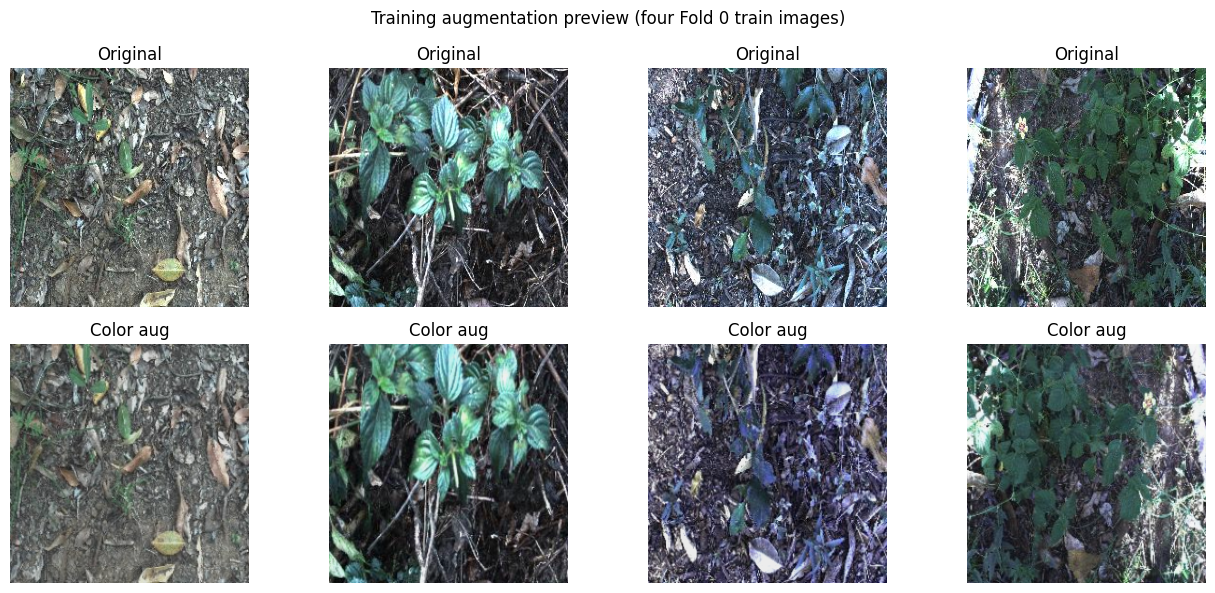

Saved augmentation evidence: curves/augmentation_preview.png


In [5]:
import dataset as ds
import model as md
import train as tr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Nạp và kiểm tra dữ liệu Fold 0
train_df, val_df, test_df = ds.load_split(LABELS_DIR, fold=0)
stats = ds.check_split(train_df, val_df, test_df, IMAGES_DIR)

print('=== KIỂM TRA TẬP DỮ LIỆU FOLD 0 ===')
print(f"Train: {stats['n']['train']} | Val: {stats['n']['val']} | Test: {stats['n']['test']} | Tổng: {stats['n']['total']}")
print(f"Tỉ lệ: Train {stats['ratio']['train']:.2%} | Val {stats['ratio']['val']:.2%} | Test {stats['ratio']['test']:.2%}")
print(f"Giao giữa các tập (Rò rỉ): {stats['overlap']} -> HOÀN TOÀN RỖNG (Hợp lệ!)")

# 2. Sanity Check 1: Loss ban đầu (~2.197)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_m = md.build_model('resnet34', pretrained=True, num_classes=ds.NUM_CLASSES).to(device)
crit = torch.nn.CrossEntropyLoss()
train_tf = ds.build_transforms(train=True, img_size=224, aug='basic')
val_tf = ds.build_transforms(train=False, img_size=224)
train_loader = ds.make_loader(train_df, IMAGES_DIR, train_tf, batch_size=32, train=True, num_workers=2)

dummy_x, dummy_y, _ = next(iter(train_loader))
dummy_x, dummy_y = dummy_x.to(device), dummy_y.to(device)
with torch.no_grad():
    init_loss = crit(test_m(dummy_x), dummy_y).item()
expected_loss = -np.log(1.0 / ds.NUM_CLASSES)
print(f"Sanity Check 1: Loss ban đầu = {init_loss:.4f} (Kỳ vọng ~{expected_loss:.4f}) -> {'ĐẠT' if abs(init_loss - expected_loss) < 0.6 else 'LỆCH'}")

# 3. Sanity Check 2: Overfit 1 batch nhỏ
opt = torch.optim.AdamW(test_m.parameters(), lr=1e-3)
for _ in range(30):
    opt.zero_grad()
    loss = crit(test_m(dummy_x), dummy_y)
    loss.backward()
    opt.step()
print(f"Sanity Check 2: Loss sau 30 bước overfit = {loss.item():.4f} -> {'ĐẠT (Pipeline hoạt động tốt)' if loss.item() < 0.2 else 'CHƯA ĐẠT'}")

del test_m, opt, dummy_x, dummy_y
torch.cuda.empty_cache()


# Save quantitative preflight evidence; package() includes eval_out JSON files.
Path('eval_out').mkdir(exist_ok=True)
Path('eval_out/sanity_checks.json').write_text(json.dumps({
    'initial_ce': float(init_loss), 'uniform_reference_ln9': float(expected_loss),
    'initial_loss_close_to_ln9': bool(abs(init_loss - expected_loss) < 0.6),
    'same_batch_ce_after_30_updates': float(loss.item()),
    'same_batch_overfit_threshold_pass': bool(loss.item() < 0.2),
    'seed': 0, 'fold': 0}, indent=2), encoding='utf-8')

# SANITY AUGMENTATION PREVIEW — save evidence for the lab report/package.
from PIL import Image
fig, axs = plt.subplots(2, 4, figsize=(13, 6))
preview_tf = ds.build_transforms(train=True, img_size=224, aug='color')
for col, (_, sample) in enumerate(train_df.head(4).iterrows()):
    image = Image.open(IMAGES_DIR / sample.Filename).convert('RGB')
    axs[0, col].imshow(image); axs[0, col].set_title('Original')
    tensor = preview_tf(image).permute(1, 2, 0).numpy()
    tensor = np.clip(tensor * np.array(ds.IMAGENET_STD) + np.array(ds.IMAGENET_MEAN), 0, 1)
    axs[1, col].imshow(tensor); axs[1, col].set_title('Color aug')
    for row in range(2): axs[row, col].axis('off')
fig.suptitle('Training augmentation preview (four Fold 0 train images)')
fig.tight_layout()
Path('curves/augmentation_preview.png').parent.mkdir(parents=True, exist_ok=True)
fig.savefig('curves/augmentation_preview.png', dpi=150)
plt.show(); plt.close(fig)
print('Saved augmentation evidence: curves/augmentation_preview.png')


## 🔬 Cell 5 — Bước 1: So sánh $\ge 5$ Backbone (Sàng lọc kiến trúc trên tập VAL)
> Huấn luyện 5 backbone với công thức nền `T00` (12 epochs, `batch_size = 32`, AMP).  
> Đủ 4 họ kiến trúc theo yêu cầu RUBRIC: ResNet (`resnet34`), ConvNeXt (`convnext_tiny`), Transformer (`deit_small`), Mạng nhẹ (`mobilenetv3`), mở rộng (`resnext50`).  
> Đánh giá so sánh **hoàn toàn trên tập VAL** để chọn 1 Best Backbone đi tiếp.

⚙️ Batch size duoc chon: 32 (VRAM: 14.6 GB)
=== BẮT ĐẦU BƯỚC 1: SO SÁNH 5 BACKBONE ===

[B01] Bắt đầu train resnet34 | seed=0 | batch=32 | AMP=True | epochs=12
Epoch 01/12 | Train Loss: 1.5947 | Val Loss: 1.2659 | Val F1: 0.2750 | Val Acc: 0.5835 | 31.5s
Epoch 02/12 | Train Loss: 0.9043 | Val Loss: 0.7699 | Val F1: 0.5981 | Val Acc: 0.7295 | 31.9s
Epoch 03/12 | Train Loss: 0.6300 | Val Loss: 0.6206 | Val F1: 0.6952 | Val Acc: 0.7849 | 32.5s
Epoch 04/12 | Train Loss: 0.4881 | Val Loss: 0.5245 | Val F1: 0.7473 | Val Acc: 0.8178 | 32.4s
Epoch 05/12 | Train Loss: 0.4063 | Val Loss: 0.4623 | Val F1: 0.7794 | Val Acc: 0.8386 | 32.1s
Epoch 06/12 | Train Loss: 0.3575 | Val Loss: 0.4501 | Val F1: 0.7890 | Val Acc: 0.8469 | 32.5s
Epoch 07/12 | Train Loss: 0.3283 | Val Loss: 0.4425 | Val F1: 0.7931 | Val Acc: 0.8492 | 32.3s
Epoch 08/12 | Train Loss: 0.3002 | Val Loss: 0.3919 | Val F1: 0.8121 | Val Acc: 0.8606 | 32.8s
Epoch 09/12 | Train Loss: 0.2835 | Val Loss: 0.4032 | Val F1: 0.8059 | Val Acc: 

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            


[B02] Bắt đầu train convnext_tiny | seed=0 | batch=32 | AMP=True | epochs=12
Epoch 01/12 | Train Loss: 0.6435 | Val Loss: 0.6281 | Val F1: 0.7228 | Val Acc: 0.7915 | 82.7s
Epoch 02/12 | Train Loss: 0.2474 | Val Loss: 0.2083 | Val F1: 0.9167 | Val Acc: 0.9340 | 56.5s
Epoch 03/12 | Train Loss: 0.1504 | Val Loss: 0.2883 | Val F1: 0.9116 | Val Acc: 0.9286 | 55.5s
Epoch 04/12 | Train Loss: 0.1038 | Val Loss: 0.1565 | Val F1: 0.9352 | Val Acc: 0.9509 | 56.0s
Epoch 05/12 | Train Loss: 0.0840 | Val Loss: 0.1873 | Val F1: 0.9233 | Val Acc: 0.9417 | 55.8s
Epoch 06/12 | Train Loss: 0.0461 | Val Loss: 0.1718 | Val F1: 0.9339 | Val Acc: 0.9477 | 55.6s
Epoch 07/12 | Train Loss: 0.0316 | Val Loss: 0.1714 | Val F1: 0.9413 | Val Acc: 0.9540 | 55.4s
Epoch 08/12 | Train Loss: 0.0114 | Val Loss: 0.1567 | Val F1: 0.9508 | Val Acc: 0.9632 | 55.2s
Epoch 09/12 | Train Loss: 0.0039 | Val Loss: 0.1257 | Val F1: 0.9624 | Val Acc: 0.9709 | 55.2s
Epoch 10/12 | Train Loss: 0.0014 | Val Loss: 0.1725 | Val F1: 0.949

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  100MB            

model.safetensors: downloading bytes:           |  0.00B            


[B05] Bắt đầu train resnext50_32x4d | seed=0 | batch=32 | AMP=True | epochs=12
Epoch 01/12 | Train Loss: 1.4574 | Val Loss: 1.0680 | Val F1: 0.4334 | Val Acc: 0.6252 | 60.9s
Epoch 02/12 | Train Loss: 0.5671 | Val Loss: 0.7873 | Val F1: 0.6403 | Val Acc: 0.7332 | 59.6s
Epoch 03/12 | Train Loss: 0.3348 | Val Loss: 0.6509 | Val F1: 0.7047 | Val Acc: 0.7709 | 59.9s
Epoch 04/12 | Train Loss: 0.2446 | Val Loss: 0.5430 | Val F1: 0.7655 | Val Acc: 0.8095 | 59.8s
Epoch 05/12 | Train Loss: 0.1933 | Val Loss: 0.4144 | Val F1: 0.8158 | Val Acc: 0.8583 | 59.8s
Epoch 06/12 | Train Loss: 0.1552 | Val Loss: 0.3597 | Val F1: 0.8408 | Val Acc: 0.8789 | 59.8s
Epoch 07/12 | Train Loss: 0.1273 | Val Loss: 0.3942 | Val F1: 0.8286 | Val Acc: 0.8675 | 59.8s
Epoch 08/12 | Train Loss: 0.1015 | Val Loss: 0.3927 | Val F1: 0.8369 | Val Acc: 0.8692 | 59.8s
Epoch 09/12 | Train Loss: 0.0939 | Val Loss: 0.3862 | Val F1: 0.8392 | Val Acc: 0.8777 | 59.9s
Epoch 10/12 | Train Loss: 0.0829 | Val Loss: 0.3715 | Val F1: 0.8

,exp_id,backbone,tag,params_m,gmacs,img_size,epochs,seed,val_macro_f1,val_top1,train_time_min,latency_p50_ms,note
0,B01,resnet34,timm/default,21.29,3.66,224,12,0,0.8217,0.8669,6.48,5.40,Công thức nền T00
1,B02,convnext_tiny,timm/default,27.83,0.32,224,12,0,0.9624,0.9709,11.57,8.25,Công thức nền T00
2,B03,deit_small_patch16_224,timm/default,21.67,0.08,224,12,0,0.9551,0.9672,7.55,6.28,Công thức nền T00
3,B04,mobilenetv3_large_100,timm/default,4.21,0.22,224,12,0,0.8449,0.8852,5.91,8.54,Công thức nền T00
4,B05,resnext50_32x4d,timm/default,23.00,4.23,224,12,0,0.8606,0.8929,12.00,7.34,Công thức nền T00



🏆 KẾT LUẬN BƯỚC 1: Chọn backbone 'convnext_tiny' có Val Macro-F1 cao nhất để đi tiếp!


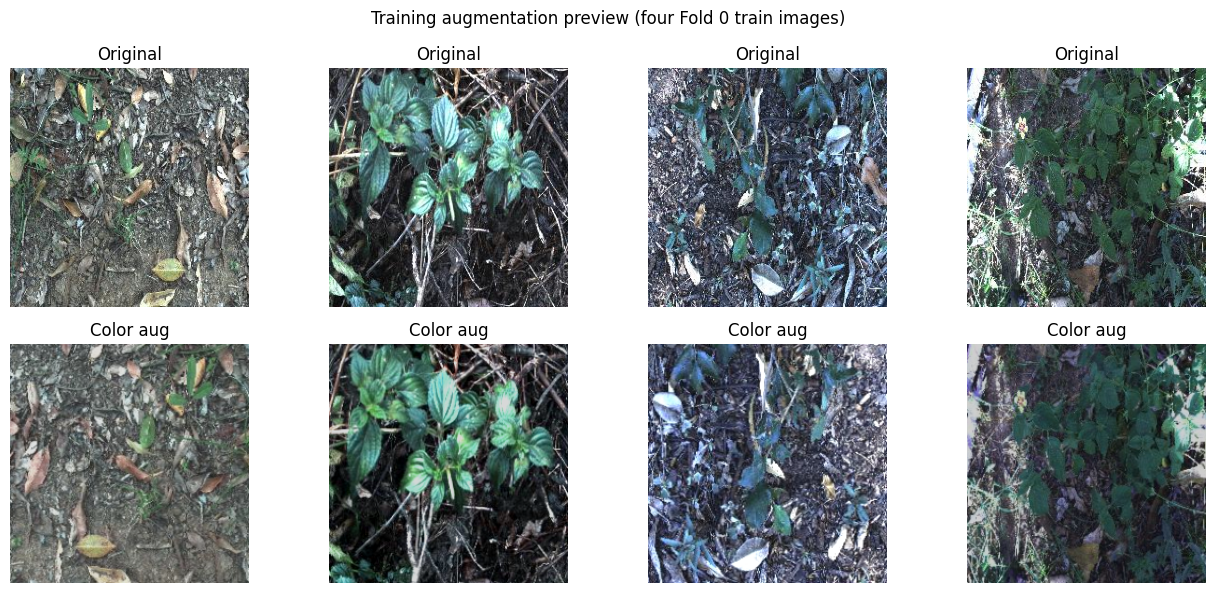

Saved augmentation evidence: curves/augmentation_preview.png


In [6]:
import benchmark as bm

backbones_to_eval = [
    ('B01', 'resnet34'),
    ('B02', 'convnext_tiny'),
    ('B03', 'deit_small_patch16_224'),
    ('B04', 'mobilenetv3_large_100'),
    ('B05', 'resnext50_32x4d'),
]

backbone_results = []
EPOCHS_STEP1 = 12
# Tu dong nhan dien VRAM de toi uu toc do:
# Colab T4 / Kaggle (16GB VRAM): Dung batch_size = 128 de toi uu toc do toi da tren GPU T4 (GUIDE muc 1.4)
# Local (4GB VRAM): Tu dong giam ve 32 de tranh loi CUDA Out of Memory (OOM)
is_large_gpu = torch.cuda.is_available() and (torch.cuda.get_device_properties(0).total_memory / 1024**3 > 6.0)
BATCH_SIZE = 32
print(f'⚙️ Batch size duoc chon: {BATCH_SIZE} (VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)' if torch.cuda.is_available() else '⚙️ CPU: batch_size = 32')

print('=== BẮT ĐẦU BƯỚC 1: SO SÁNH 5 BACKBONE ===')
for exp_id, bb_name in backbones_to_eval:
    cfg = tr.Config(
        exp_id=exp_id,
        backbone=bb_name,
        seed=0,
        epochs=EPOCHS_STEP1,
        batch_size=BATCH_SIZE,
        amp=True,
        images_dir=str(IMAGES_DIR),
        labels_dir=str(LABELS_DIR),
    )
    # Đo tham số và GMAC
    m_temp = md.build_model(bb_name, pretrained=False, num_classes=ds.NUM_CLASSES)
    p_cnt = md.count_params(m_temp)
    g_cnt = md.count_gmacs(m_temp, img_size=224)
    del m_temp
    torch.cuda.empty_cache()

    # Huấn luyện
    res = tr.run(cfg)
    best_f1 = res['best_val_f1']

    # Đo độ trễ sơ bộ batch 1
    best_pth = tr.run_dir(cfg) / 'best_model.pth'
    eval_m = md.build_model(bb_name, pretrained=False, num_classes=ds.NUM_CLASSES)
    eval_m.load_state_dict(torch.load(best_pth))
    lat = bm.latency_report(eval_m, batch_size=1, img_size=224, dtype='amp', iters=30)
    del eval_m
    torch.cuda.empty_cache()

    backbone_results.append({
        'exp_id': exp_id,
        'backbone': bb_name,
        'tag': 'timm/default',
        'params_m': round(p_cnt, 2),
        'gmacs': round(g_cnt, 2),
        'img_size': 224,
        'epochs': EPOCHS_STEP1,
        'seed': 0,
        'val_macro_f1': round(best_f1, 4),
        'val_top1': round(res['history'][res['best_epoch'] - 1]['val_acc'], 4),
        'train_time_min': round(res['total_sec'] / 60, 2),
        'latency_p50_ms': lat['p50'],
        'note': 'Công thức nền T00'
    })

df_backbones = pd.DataFrame(backbone_results)
display(df_backbones)

best_bb = df_backbones.sort_values(by='val_macro_f1', ascending=False).iloc[0]['backbone']
print(f"\n🏆 KẾT LUẬN BƯỚC 1: Chọn backbone '{best_bb}' có Val Macro-F1 cao nhất để đi tiếp!")


# Save quantitative preflight evidence; package() includes eval_out JSON files.
Path('eval_out').mkdir(exist_ok=True)
Path('eval_out/sanity_checks.json').write_text(json.dumps({
    'initial_ce': float(init_loss), 'uniform_reference_ln9': float(expected_loss),
    'initial_loss_close_to_ln9': bool(abs(init_loss - expected_loss) < 0.6),
    'same_batch_ce_after_30_updates': float(loss.item()),
    'same_batch_overfit_threshold_pass': bool(loss.item() < 0.2),
    'seed': 0, 'fold': 0}, indent=2), encoding='utf-8')

# SANITY AUGMENTATION PREVIEW — save evidence for the lab report/package.
from PIL import Image
fig, axs = plt.subplots(2, 4, figsize=(13, 6))
preview_tf = ds.build_transforms(train=True, img_size=224, aug='color')
for col, (_, sample) in enumerate(train_df.head(4).iterrows()):
    image = Image.open(IMAGES_DIR / sample.Filename).convert('RGB')
    axs[0, col].imshow(image); axs[0, col].set_title('Original')
    tensor = preview_tf(image).permute(1, 2, 0).numpy()
    tensor = np.clip(tensor * np.array(ds.IMAGENET_STD) + np.array(ds.IMAGENET_MEAN), 0, 1)
    axs[1, col].imshow(tensor); axs[1, col].set_title('Color aug')
    for row in range(2): axs[row, col].axis('off')
fig.suptitle('Training augmentation preview (four Fold 0 train images)')
fig.tight_layout()
Path('curves/augmentation_preview.png').parent.mkdir(parents=True, exist_ok=True)
fig.savefig('curves/augmentation_preview.png', dpi=150)
plt.show(); plt.close(fig)
print('Saved augmentation evidence: curves/augmentation_preview.png')


## 🔬 Cell 6 — Bước 2: Khảo sát Công thức Huấn luyện (Ablation $\ge 3$ trục trên tập VAL)
> Khảo sát trên Best Backbone vừa chọn ở Bước 1. Mỗi lần chạy chỉ thay đổi **đúng 1 yếu tố** so với nền (nguyên tắc N1).  
> Khảo sát 3 trục: **Augmentation** (Color, CutMix), **Hàm Loss** (Label Smoothing, Focal Loss), **Tối ưu/Chính quy** (Frozen, EMA) và **Thí nghiệm kết hợp tốt nhất** (`T07`).

In [7]:
TARGET_BB = best_bb
print(f'Tiến hành khảo sát công thức huấn luyện trên backbone: {TARGET_BB}')

ablation_configs = [
    ('T01', 'Augmentation', 'ColorJitter', {'aug': 'color'}),
    ('T02', 'Augmentation', 'CutMix (alpha=1.0)', {'mix': 'cutmix', 'mix_alpha': 1.0}),
    ('T03', 'Hàm Loss', 'Label Smoothing (eps=0.1)', {'loss': 'ls', 'label_smoothing': 0.1}),
    ('T04', 'Hàm Loss', 'Focal Loss (gamma=2.0)', {'loss': 'focal', 'focal_gamma': 2.0}),
    ('T08', 'Khởi tạo', 'From scratch', {'init': 'scratch'}),
    ('T05', 'Khởi tạo', 'Frozen Backbone', {'init': 'frozen'}),
    ('T06', 'Chính quy', 'EMA Decay 0.999', {'ema_decay': 0.999}),
    ('T07', 'Kết hợp', 'CutMix + Label Smoothing + EMA', {'mix': 'cutmix', 'mix_alpha': 1.0, 'loss': 'ls', 'label_smoothing': 0.1, 'ema_decay': 0.999}),
]

ablation_results = []
baseline_row = df_backbones[df_backbones['backbone'] == TARGET_BB].iloc[0] if 'df_backbones' in locals() else None
baseline_f1 = float(baseline_row['val_macro_f1'])

for exp_id, axis, diff_desc, overrides in ablation_configs:
    cfg = tr.Config(
        exp_id=exp_id,
        backbone=TARGET_BB,
        seed=0,
        epochs=12,
        batch_size=BATCH_SIZE,
        amp=True,
        images_dir=str(IMAGES_DIR),
        labels_dir=str(LABELS_DIR),
        **overrides
    )
    res = tr.run(cfg)
    best_f1 = res['best_val_f1']
    best_ep = res['best_epoch']
    val_acc = res['history'][best_ep - 1]['val_acc']
    delta = best_f1 - baseline_f1

    ablation_results.append({
        'exp_id': exp_id,
        'backbone': TARGET_BB,
        'axis': axis,
        'diff_vs_t00': diff_desc,
        'seed': 0,
        'val_macro_f1': round(best_f1, 4),
        'val_top1': round(val_acc, 4),
        'delta_vs_t00': round(delta, 4),
        'rare_class_f1': '-',
        'note': f'Epoch tốt nhất: {best_ep}'
    })

df_ablation = pd.DataFrame(ablation_results)
display(df_ablation)

baseline_exp = df_backbones[df_backbones.backbone == TARGET_BB].iloc[0].exp_id
recipe_candidates = pd.concat([df_ablation[['exp_id', 'val_macro_f1']],
    pd.DataFrame([{'exp_id': baseline_exp, 'val_macro_f1': baseline_f1}])], ignore_index=True)
best_recipe_exp = recipe_candidates.sort_values('val_macro_f1', ascending=False).iloc[0].exp_id
f01_overrides = next((overrides.copy() for exp_id, _, _, overrides in ablation_configs
                      if exp_id == best_recipe_exp), {})
print(f'\n🏆 KẾT LUẬN BƯỚC 2: Cấu hình tốt nhất là {best_recipe_exp}!')


Tiến hành khảo sát công thức huấn luyện trên backbone: convnext_tiny

[T01] Bắt đầu train convnext_tiny | seed=0 | batch=32 | AMP=True | epochs=12
Epoch 01/12 | Train Loss: 0.7170 | Val Loss: 0.4314 | Val F1: 0.8035 | Val Acc: 0.8589 | 57.8s
Epoch 02/12 | Train Loss: 0.2949 | Val Loss: 0.2973 | Val F1: 0.8801 | Val Acc: 0.9086 | 58.1s
Epoch 03/12 | Train Loss: 0.1887 | Val Loss: 0.3417 | Val F1: 0.8623 | Val Acc: 0.8915 | 57.7s
Epoch 04/12 | Train Loss: 0.1289 | Val Loss: 0.2172 | Val F1: 0.9129 | Val Acc: 0.9323 | 57.6s
Epoch 05/12 | Train Loss: 0.1021 | Val Loss: 0.1641 | Val F1: 0.9394 | Val Acc: 0.9529 | 57.7s
Epoch 06/12 | Train Loss: 0.0630 | Val Loss: 0.1814 | Val F1: 0.9341 | Val Acc: 0.9463 | 57.5s
Epoch 07/12 | Train Loss: 0.0459 | Val Loss: 0.1803 | Val F1: 0.9334 | Val Acc: 0.9483 | 57.6s
Epoch 08/12 | Train Loss: 0.0241 | Val Loss: 0.2064 | Val F1: 0.9316 | Val Acc: 0.9454 | 57.5s
Epoch 09/12 | Train Loss: 0.0114 | Val Loss: 0.1931 | Val F1: 0.9433 | Val Acc: 0.9540 | 57.5

,exp_id,backbone,axis,diff_vs_t00,seed,val_macro_f1,val_top1,delta_vs_t00,rare_class_f1,note
0,T01,convnext_tiny,Augmentation,ColorJitter,0,0.9538,0.9623,-0.0086,-,Epoch tốt nhất: 11
1,T02,convnext_tiny,Augmentation,CutMix (alpha=1.0),0,0.9716,0.9774,0.0092,-,Epoch tốt nhất: 12
2,T03,convnext_tiny,Hàm Loss,Label Smoothing (eps=0.1),0,0.9625,0.9703,0.0001,-,Epoch tốt nhất: 9
3,T04,convnext_tiny,Hàm Loss,Focal Loss (gamma=2.0),0,0.9587,0.9680,-0.0037,-,Epoch tốt nhất: 12
4,T08,convnext_tiny,Khởi tạo,From scratch,0,0.3839,0.5801,-0.5785,-,Epoch tốt nhất: 11
5,T05,convnext_tiny,Khởi tạo,Frozen Backbone,0,0.8607,0.8863,-0.1017,-,Epoch tốt nhất: 8
6,T06,convnext_tiny,Chính quy,EMA Decay 0.999,0,0.9638,0.9723,0.0014,-,Epoch tốt nhất: 10
7,T07,convnext_tiny,Kết hợp,CutMix + Label Smoothing + EMA,0,0.9721,0.9780,0.0097,-,Epoch tốt nhất: 12



🏆 KẾT LUẬN BƯỚC 2: Cấu hình tốt nhất là T07!


## Cell 7 — Four inference methods beyond I00 on VAL
I01 horizontal TTA with probability averaging; I02 vertical TTA with probability averaging; I03 horizontal TTA with logit averaging; I04 temperature scaling. 224 px; latency uses 10 warmups and 50 synchronized repeats.


In [8]:
import inference as inf
import eval as ev
import json
from contextlib import nullcontext

best_model_path = Path('runs') / best_recipe_exp / 'seed0' / 'best_model.pth'
eval_model = md.build_model(TARGET_BB, pretrained=False, num_classes=ds.NUM_CLASSES)
eval_model.load_state_dict(torch.load(best_model_path, map_location='cpu', weights_only=True))
eval_model.to(device).eval()
val_loader_224 = ds.make_loader(val_df, IMAGES_DIR, ds.build_transforms(train=False, img_size=224),
                               batch_size=32, train=False, num_workers=2)
def logits_to_probs(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)
def measure(views, batch=1):
    dummy = torch.randn(batch, 3, 224, 224, device=device)
    def forward():
        with torch.autocast(device_type='cuda', dtype=torch.float16) if device.type == 'cuda' else nullcontext():
            for view in views: eval_model(view(dummy))
    with torch.inference_mode():
        report = bm.bench(forward, warmup=10, iters=50,
                          sync=torch.cuda.synchronize if device.type == 'cuda' else None)
    report.update(gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU',
                  dtype='amp' if device.type == 'cuda' else 'fp32', batch=batch,
                  images_per_s=batch * 1000 / report['p50'])
    return report
identity = lambda x: x
vertical = lambda x: torch.flip(x, dims=[-2])
fns, y_val_true, val_logits = inf.predict_logits(eval_model, val_loader_224, device)
_, _, horizontal_logits = inf.predict_logits(eval_model, val_loader_224, device, view=inf.view_hflip)
_, _, vertical_logits = inf.predict_logits(eval_model, val_loader_224, device, view=vertical)
def softmax_np(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)
logit_tta = softmax_np((val_logits + horizontal_logits) / 2.0)
T_opt = inf.fit_temperature(val_logits, y_val_true)
lat_i00 = measure([identity])
lat_i01 = measure([identity, inf.view_hflip])
lat_i02 = measure([identity, vertical])
lat_b32 = measure([identity], batch=32)
methods = [
    ('I00', '1-view 224', logits_to_probs(val_logits), lat_i00, 1),
    ('I01', 'TTA horizontal: probability average', inf.aggregate_views([val_logits, horizontal_logits]), lat_i01, 2),
    ('I02', 'TTA vertical: probability average', inf.aggregate_views([val_logits, vertical_logits]), lat_i02, 2),
    ('I03', 'TTA horizontal: logit average', logit_tta, lat_i01, 2),
    ('I04', f'Temperature scaling T={T_opt:.4f}', inf.apply_temperature(val_logits, T_opt), lat_i00, 1)]
rows = []
for exp_id, method, probabilities, latency, k in methods:
    metrics = ev.compute_metrics(y_val_true, probabilities.argmax(axis=1), probabilities)
    rows.append(dict(exp_id=exp_id, method=method, model_ckpt=str(best_model_path), k_views=k,
        val_macro_f1=metrics['macro_f1'], val_top1=metrics['top1'], val_ece=metrics['ece'],
        latency_p50_ms=latency['p50'], latency_p95_ms=latency['p95'], latency_p99_ms=latency['p99'],
        throughput_img_s=latency['images_per_s'], relative_cost=latency['p50']/lat_i00['p50'],
        gpu=latency['gpu'], dtype=latency['dtype'], batch=1))
df_inference = pd.DataFrame(rows)
display(df_inference)
ece_i00 = float(df_inference.loc[df_inference.exp_id == 'I00', 'val_ece'].iloc[0])
ece_calibrated = float(df_inference.loc[df_inference.exp_id == 'I04', 'val_ece'].iloc[0])
print('TEST will be evaluated once after fitting per-seed temperature on VAL only.')
del eval_model
torch.cuda.empty_cache()


,exp_id,method,model_ckpt,k_views,val_macro_f1,val_top1,val_ece,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_img_s,relative_cost,gpu,dtype,batch
0,I00,1-view 224,runs/T07/seed0/best_model.pth,1,0.972141,0.978006,0.088010,8.190552,9.110131,10.244967,122.091886,1.000000,Tesla T4,amp,1
1,I01,TTA horizontal: probability average,runs/T07/seed0/best_model.pth,2,0.973986,0.979720,0.090309,16.056312,16.776587,17.942457,62.280803,1.960345,Tesla T4,amp,1
2,I02,TTA vertical: probability average,runs/T07/seed0/best_model.pth,2,0.975082,0.980577,0.090934,15.999543,22.295212,24.996076,62.501785,1.953414,Tesla T4,amp,1
3,I03,TTA horizontal: logit average,runs/T07/seed0/best_model.pth,2,0.973660,0.979434,0.089764,16.056312,16.776587,17.942457,62.280803,1.960345,Tesla T4,amp,1
4,I04,Temperature scaling T=0.6240,runs/T07/seed0/best_model.pth,1,0.972141,0.978006,0.004916,8.190552,9.110131,10.244967,122.091886,1.000000,Tesla T4,amp,1


TEST will be evaluated once after fitting per-seed temperature on VAL only.


## 🏆 Cell 8 — Bước 4: Vòng chung kết (Đánh giá trên tập TEST với 3 Seeds & Chấm điểm `eval.py`)
> **ĐÂY LÀ BƯỚC DUY NHẤT ĐƯỢC CHẠY TRÊN TẬP TEST:**  
> 1. Huấn luyện cấu hình chung kết (`F01`) qua 3 seeds (seed 0, 1, 2) với `save_test_predictions = True`.  
> 2. Huấn luyện cấu hình mốc (`T00`) qua 3 seeds tương ứng để đo mức cải thiện $\Delta$.  
> 3. Tự động chấm điểm Phần I RUBRIC bằng lệnh `eval.py score` và `eval.py grade`.

In [9]:
SEEDS = [0, 1, 2]
print('=== HUẤN LUYỆN 3 SEEDS CHO CHUNG KẾT (F01) VÀ MỐC (T00) ===')

print('Final recipe selected on VAL:', best_recipe_exp, f01_overrides)

for s in SEEDS:
    # 1. Chạy Cấu hình Chung kết F01
    cfg_f01 = tr.Config(
        exp_id='F01',
        backbone=TARGET_BB,
        seed=s,
        epochs=12,
        batch_size=BATCH_SIZE,
        amp=True,
        save_test_predictions=True,
        images_dir=str(IMAGES_DIR),
        labels_dir=str(LABELS_DIR),
        **f01_overrides
    )
    tr.run(cfg_f01)

    # 2. Chạy Cấu hình Mốc T00
    cfg_t00 = tr.Config(
        exp_id='T00',
        backbone='resnet34',
        seed=s,
        epochs=12,
        batch_size=BATCH_SIZE,
        amp=True,
        save_test_predictions=True,
        images_dir=str(IMAGES_DIR),
        labels_dir=str(LABELS_DIR)
    )
    tr.run(cfg_t00)












def run_eval(args, filename):
    result = subprocess.run([sys.executable, 'eval.py', *args], capture_output=True, text=True)
    Path('eval_out').mkdir(exist_ok=True)
    Path('eval_out', filename).write_text(result.stdout + result.stderr, encoding='utf-8')
    print(result.stdout)
    if result.returncode: raise RuntimeError(result.stderr)
common = ['--test-csv', 'data/labels/test_subset0.csv', '--labels', 'data/labels/labels.csv']
# Temperature is fitted independently on each final seed's VAL probabilities only.
# Existing TEST probabilities are calibrated without another model pass.
import shutil
calibration_rows = []
prob_cols = [f'p{i}' for i in range(ds.NUM_CLASSES)]
for seed in SEEDS:
    val_path = Path(f'predictions/F01_seed{seed}_val.csv')
    test_path = Path(f'predictions/F01_seed{seed}_test.csv')
    uncal_path = Path(f'predictions/F01_seed{seed}_uncal_test.csv')
    val_frame, test_frame = pd.read_csv(val_path), pd.read_csv(test_path)
    val_logits_seed = np.log(np.clip(val_frame[prob_cols].to_numpy(), 1e-12, 1.0))
    temperature = inf.fit_temperature(val_logits_seed, val_frame.y_true.to_numpy())
    shutil.copy2(test_path, uncal_path)
    calibrated = inf.apply_temperature(np.log(np.clip(test_frame[prob_cols].to_numpy(), 1e-12, 1.0)), temperature)
    test_frame[prob_cols] = calibrated
    test_frame['y_pred'] = calibrated.argmax(axis=1)
    test_frame.to_csv(test_path, index=False)
    calibration_rows.append({'seed': seed, 'temperature_fit_on': 'VAL only', 'temperature': temperature,
        'test_ece_before': ev.ece_score(pd.read_csv(uncal_path)[prob_cols].to_numpy(),
                                        pd.read_csv(uncal_path).y_true.to_numpy()),
        'test_ece_after': ev.ece_score(calibrated, test_frame.y_true.to_numpy())})
Path('eval_out/temperature_scaling.json').write_text(json.dumps(calibration_rows, indent=2), encoding='utf-8')
print('Per-seed temperatures fitted on VAL; TEST predictions calibrated without another forward pass.')
for tag in ['F01', 'T00']:
    run_eval(['score', '--pred', f'predictions/{tag}_seed*_test.csv', *common,
              '--tag', tag, '--out', 'eval_out'], tag + '_score.txt')
run_eval(['grade', '--final', 'predictions/F01_seed*_test.csv',
          '--baseline', 'predictions/T00_seed*_test.csv', *common,
          '--uncal', 'predictions/F01_seed*_uncal_test.csv',
          '--final-val', 'predictions/F01_seed*_val.csv',
          '--val-csv', 'data/labels/val_subset0.csv', '--out', 'eval_out',
          '--latency-p95-ms', str(lat_i00['p95'])], 'grade.txt')


=== HUẤN LUYỆN 3 SEEDS CHO CHUNG KẾT (F01) VÀ MỐC (T00) ===
Final recipe selected on VAL: T07 {'mix': 'cutmix', 'mix_alpha': 1.0, 'loss': 'ls', 'label_smoothing': 0.1, 'ema_decay': 0.999}

[F01] Bắt đầu train convnext_tiny | seed=0 | batch=32 | AMP=True | epochs=12
Epoch 01/12 | Train Loss: 1.3136 | Val Loss: 1.4920 | Val F1: 0.3526 | Val Acc: 0.6067 | 59.6s
Epoch 02/12 | Train Loss: 1.0290 | Val Loss: 0.8508 | Val F1: 0.8314 | Val Acc: 0.8620 | 59.6s
Epoch 03/12 | Train Loss: 0.9605 | Val Loss: 0.6527 | Val F1: 0.9227 | Val Acc: 0.9352 | 59.6s
Epoch 04/12 | Train Loss: 0.9208 | Val Loss: 0.5948 | Val F1: 0.9496 | Val Acc: 0.9592 | 59.6s
Epoch 05/12 | Train Loss: 0.9036 | Val Loss: 0.5716 | Val F1: 0.9574 | Val Acc: 0.9669 | 59.6s
Epoch 06/12 | Train Loss: 0.8760 | Val Loss: 0.5595 | Val F1: 0.9609 | Val Acc: 0.9700 | 59.6s
Epoch 07/12 | Train Loss: 0.8485 | Val Loss: 0.5516 | Val F1: 0.9655 | Val Acc: 0.9740 | 59.6s
Epoch 08/12 | Train Loss: 0.8376 | Val Loss: 0.5461 | Val F1: 0.9677 

RuntimeError: LỖI: seed bị trùng giữa các file: ['predictions/F01_seed0_test.csv', 'predictions/F01_seed0_uncal_test.csv', 'predictions/F01_seed1_test.csv', 'predictions/F01_seed1_uncal_test.csv', 'predictions/F01_seed2_test.csv', 'predictions/F01_seed2_uncal_test.csv']


## 📊 Cell 9 — Bước 5: Ma trận nhầm lẫn & Xuất `results.xlsx` đầy đủ 7 Sheets chuẩn Rubric

In [ ]:
from lab_outputs import export
submission_tables = export(globals())


## Cell 10 — Package submission, then Git push and draft PR
Requires completed real results. No token in Git URL; uses Kaggle/Colab Secrets. Missing token keeps the ZIP available.


In [ ]:
from submission import package, push_submission
submission_dir = package()
try:
    submission_pr_url = push_submission(submission_dir)
except Exception as error:
    print('Push/PR failed:', type(error).__name__, str(error))
    print('The ZIP is already saved. Fix credentials/permissions and rerun this cell only.')


## 💾 Cell 11 — Nén file ZIP & Tải kết quả về máy cục bộ (Dự phòng)

In [ ]:
from pathlib import Path
from submission import STUDENT
zip_path = (Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()) / (STUDENT + '_submission.zip')
print('Submission ZIP:', zip_path)
try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:
    print('Kaggle: Save Version to preserve Output, then download this ZIP from Output.')
